# TRABAJO PRÁCTICO 01: Preprocesamiento y transformación de datos

**Bases de Datos Masivas (11088)** — Departamento de Ciencias Básicas
2° Cuatrimestre 2026 — Universidad Nacional de Luján
Alumno: Huici, Nicolás
Legajo: 165755

## Parte 1: Manejo de ruido, outliers y transformación de datos.

### 1.a Carácterísticas de las variables 
*El CO, el NO2 y las PM10 son los principales contaminantes del aire que se miden para evaluar la calidad ambiental y el impacto en la salud pública.*

Cómo se puede ver al ejecutar *head* sobre el dataframe, las variables se tratan de mediciones sobre la calidad ambiental en **Parque Centenario**, **Córdoba** y **La boca**, en cierta *fecha* y *hora*.
Las variables son númericas y, al tratarse de mediciones, continuas.

De la información que nos aporta el *df.info()* podemos observar que en total hay 5484 entradas o tuplas, y con la información de la columna *"Non-null Count"* podemos deducir que las únicas columnas que no tienen datos faltantes o nulos son *fecha* y *hora*. TODAS las columnas de mediciones tienen datos faltantes, esto es interesante saberlo para luego decidir qué política tomar sobre los datos faltantes.

Finalmente con *df.describe()* podemos ver el min y max, donde confirmamos que todos los datos son no-negativos, lo cual tiene sentido ya que se está midiendo contenido de ciertos contaminantes en el aire, y no parecieran estar normalizados.
Algo interesante para tener en cuenta para lo que sigue es que el valor máximo de CO en la boca supera por mucho el valor máximo observado en centenario y córdoba, lo que puede indicar un outlier o ruido. Además se aleja mucho de la media también.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/calidad_aire.csv")

display(df.head())
df.info()
df.describe()


,fecha,hora,co_centenario,no2_centenario,pm10_centenario,co_cordoba,no2_cordoba,pm10_cordoba,co_la_boca,no2_la_boca,pm10_la_boca
0,2026-01-01,1,NaN,6.0,NaN,0.28,13.0,42.0,0.43,9.0,37.0
1,2026-01-01,2,0.38,8.0,NaN,0.30,15.0,44.0,0.42,11.0,37.0
2,2026-01-01,3,0.35,14.0,NaN,0.32,14.0,45.0,0.41,11.0,38.0
3,2026-01-01,4,0.30,23.0,NaN,0.33,16.0,46.0,0.39,13.0,39.0
4,2026-01-01,5,0.22,7.0,NaN,0.27,9.0,48.0,0.34,11.0,42.0


<class 'pandas.DataFrame'>
RangeIndex: 5484 entries, 0 to 5483
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha            5484 non-null   str    
 1   hora             5484 non-null   int64  
 2   co_centenario    5395 non-null   float64
 3   no2_centenario   5379 non-null   float64
 4   pm10_centenario  5092 non-null   float64
 5   co_cordoba       5484 non-null   float64
 6   no2_cordoba      5436 non-null   float64
 7   pm10_cordoba     5197 non-null   float64
 8   co_la_boca       5053 non-null   float64
 9   no2_la_boca      5071 non-null   float64
 10  pm10_la_boca     4702 non-null   float64
dtypes: float64(9), int64(1), str(1)
memory usage: 525.0 KB


,hora,co_centenario,no2_centenario,pm10_centenario,co_cordoba,no2_cordoba,pm10_cordoba,co_la_boca,no2_la_boca,pm10_la_boca
count,5484.000000,5395.000000,5379.000000,5092.000000,5484.000000,5436.000000,5197.000000,5053.000000,5071.000000,4702.000000
mean,12.486871,0.442059,13.322365,22.065200,0.644984,19.122701,26.855109,0.329329,25.155591,25.692684
std,6.922805,0.210957,6.135464,9.352714,0.332529,8.836501,9.474977,0.491052,9.983203,11.623068
min,1.000000,0.060000,2.000000,6.000000,0.030000,0.000000,9.000000,0.060000,5.000000,3.000000
25%,6.000000,0.300000,9.000000,15.000000,0.380000,13.000000,20.000000,0.200000,18.000000,17.000000
50%,12.000000,0.400000,13.000000,20.000000,0.590000,18.000000,25.000000,0.270000,24.000000,24.000000
75%,18.000000,0.530000,17.000000,27.000000,0.852500,24.000000,32.000000,0.370000,31.000000,33.000000
max,24.000000,1.570000,43.000000,60.000000,2.070000,88.000000,62.000000,23.000000,73.000000,74.000000


### 1.a Distribución de las variables
#### Histogramas

Para responder *Cómo se distribuyen las variables* visualmente voy a hacer uso de los histogramas, para la selección de la cantidad de bins se va a usar la [Regla de Freedman-Diaconis](https://en.wikipedia.org/wiki/Freedman%E2%80%93Diaconis_rule) ya que cambiar la cantidad de bins cambia las conclusiones que se puedan hacer sobre los datos.

Con esto en cuenta lo que se puede observar es que todas las variables tienen un sesgo positivo, esto es que las distribuciones tienen un pico en los valores más pequeños y una "cola larga" que se extiende hacia valores mayores.
Para confirmar esto se agrega una tabla que contienen información sobre el sesgo de las variables, donde podemos ver efectivamente que para todas las variables en cuestión la media es mayor a la mediana, ya que los valores extremos superiores "tiran" de la media hacia valores superiores.

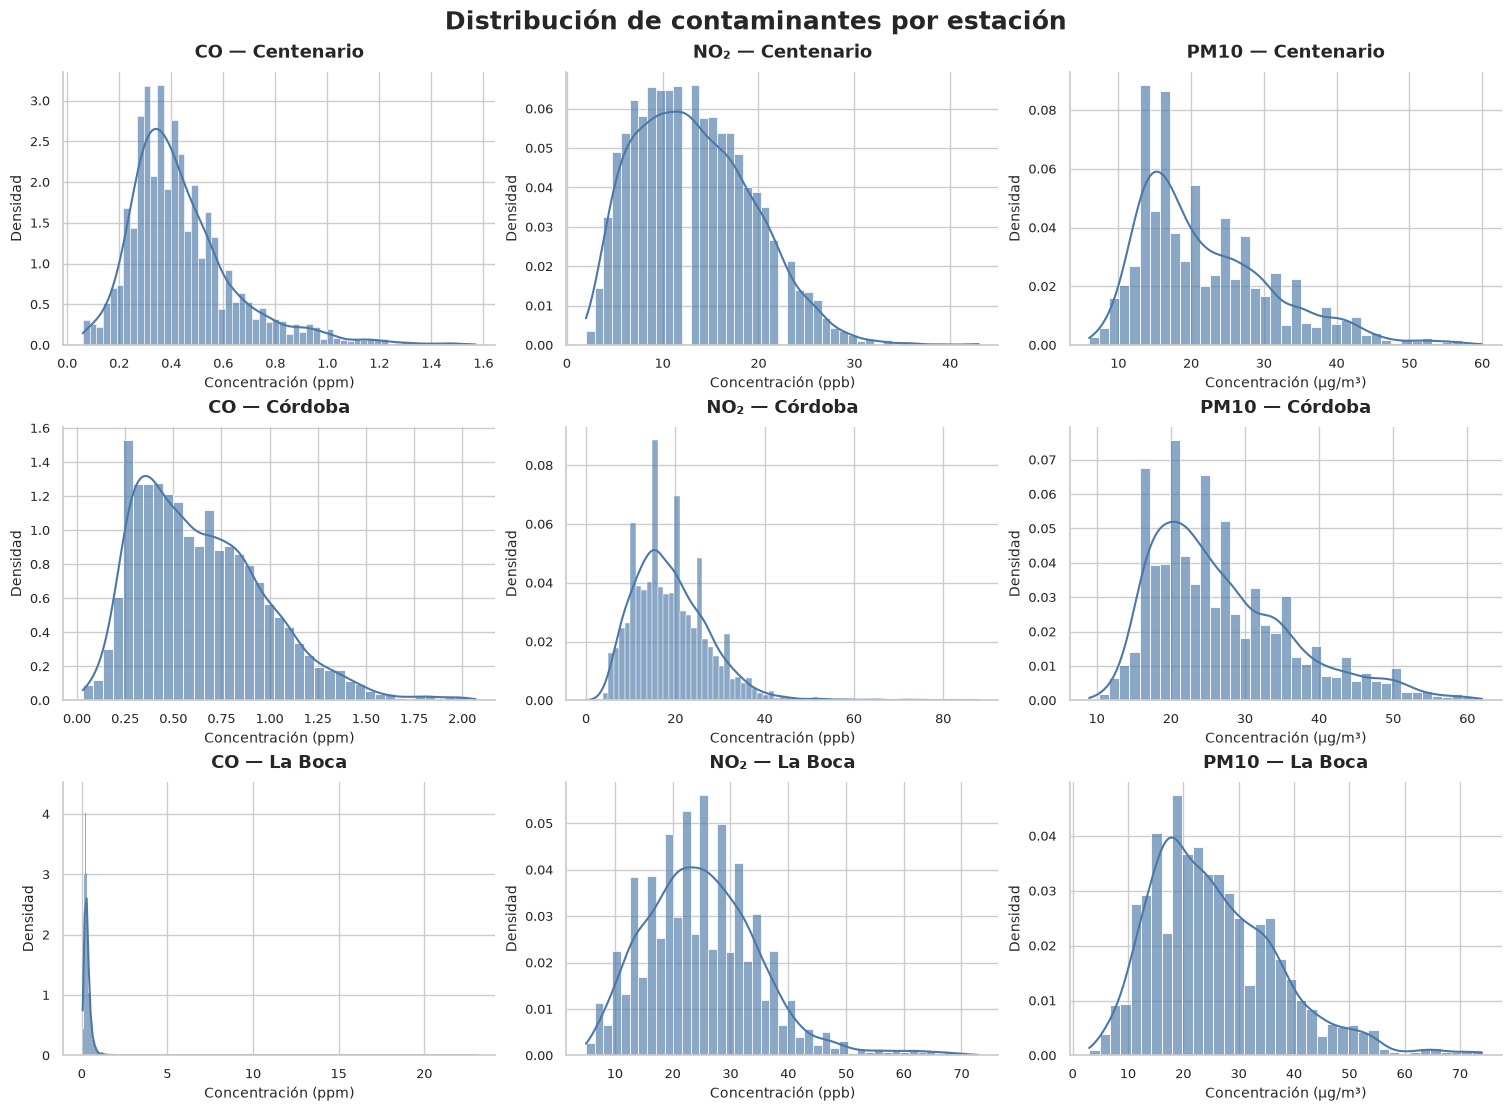

In [2]:
import seaborn as sns

# Variables a analizar: excluimos "hora"
variables = [col for col in df.columns if col != "hora" and col != "fecha"]

# Nombre más amigable para mostrar en los gráficos
nombres = {
    "co_centenario": "CO — Centenario",
    "no2_centenario": "NO₂ — Centenario",
    "pm10_centenario": "PM10 — Centenario",
    "co_cordoba": "CO — Córdoba",
    "no2_cordoba": "NO₂ — Córdoba",
    "pm10_cordoba": "PM10 — Córdoba",
    "co_la_boca": "CO — La Boca",
    "no2_la_boca": "NO₂ — La Boca",
    "pm10_la_boca": "PM10 — La Boca",
}

unidades = {
    "co_centenario": "ppm", "co_cordoba": "ppm", "co_la_boca": "ppm",
    "no2_centenario": "ppb", "no2_cordoba": "ppb", "no2_la_boca": "ppb",
    "pm10_centenario": "µg/m³", "pm10_cordoba": "µg/m³", "pm10_la_boca": "µg/m³",
}

COLOR_ORIGINAL = "#4C78A8"
COLOR_SUAVIZADA = "#F58518"

# Configuración visual
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 11),
    constrained_layout=True
)

for ax, variable in zip(axes.flat, variables):

    # Eliminamos NaN para el cálculo
    datos = df[variable].dropna()

    # Histograma
    sns.histplot(
        datos,
        bins="fd",
        kde=True,
        stat="density",
        alpha=0.65,
        color=COLOR_ORIGINAL,
        ax=ax
    )

    ax.set_title(
        nombres.get(variable, variable),
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    ax.set_xlabel(f"Concentración ({unidades[variable]})", fontsize=10)
    ax.set_ylabel("Densidad", fontsize=10)

    ax.tick_params(axis="both", labelsize=9)

    # Limpiar bordes innecesarios
    sns.despine(ax=ax)

fig.suptitle(
    "Distribución de contaminantes por estación",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [3]:
resumen = df[variables].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T

resumen["skewness"] = df[variables].skew()

resumen = resumen.round(3)

resumen

,count,mean,median,std,min,max,skewness
co_centenario,5395.0,0.442,0.40,0.211,0.06,1.57,1.497
no2_centenario,5379.0,13.322,13.00,6.135,2.00,43.00,0.553
pm10_centenario,5092.0,22.065,20.00,9.353,6.00,60.00,1.036
co_cordoba,5484.0,0.645,0.59,0.333,0.03,2.07,0.818
no2_cordoba,5436.0,19.123,18.00,8.837,0.00,88.00,1.517
pm10_cordoba,5197.0,26.855,25.00,9.475,9.00,62.00,0.991
co_la_boca,5053.0,0.329,0.27,0.491,0.06,23.00,39.153
no2_la_boca,5071.0,25.156,24.00,9.983,5.00,73.00,0.827
pm10_la_boca,4702.0,25.693,24.00,11.623,3.00,74.00,0.934


### 1.a Distribución de las variables
#### Observaciones anómalas

Desde la primera aproximación a los datos que mencionamos el valor máximo para la medición de co en La Boca como una ocurrencia extraña dado el resto de descriptores.
Y si observamos el histograma anterior que hace referencia a esta variable notamos que se diferencia en gran medida hacia los demás. 
Otro valor que me hace ruido es el indicador de *"skewness"* de la tabla anterior para esta variable, el cual se aleja muchísimo del resultado de hacer (media - mediana). Por lo que voy a hacer ahora es mirar un poco más en detalle este caso.

In [4]:
display(df.nlargest(20, "co_la_boca"))

,fecha,hora,co_centenario,no2_centenario,pm10_centenario,co_cordoba,no2_cordoba,pm10_cordoba,co_la_boca,no2_la_boca,pm10_la_boca
3629,2026-06-01,6,0.74,18.0,38.0,0.64,18.0,31.0,23.00,32.0,NaN
3630,2026-06-01,7,0.70,21.0,37.0,0.73,27.0,31.0,23.00,33.0,NaN
3607,2026-05-31,8,1.44,18.0,46.0,1.54,25.0,44.0,1.92,32.0,36.0
3608,2026-05-31,9,1.36,20.0,48.0,1.44,27.0,45.0,1.92,33.0,37.0
3609,2026-05-31,10,1.26,24.0,50.0,1.45,28.0,45.0,1.92,40.0,39.0
3606,2026-05-31,7,1.48,18.0,45.0,1.56,26.0,45.0,1.90,33.0,35.0
3893,2026-06-12,6,1.22,14.0,41.0,1.32,15.0,49.0,1.84,34.0,49.0
3605,2026-05-31,6,1.52,19.0,44.0,1.61,26.0,45.0,1.82,32.0,34.0
3892,2026-06-12,5,1.33,15.0,41.0,1.40,15.0,50.0,1.82,27.0,49.0
3891,2026-06-12,4,1.41,15.0,40.0,1.52,18.0,50.0,1.81,32.0,49.0


In [5]:
display(df.loc[
    df["fecha"] == "2026-06-01",
    ["fecha", "hora", "co_la_boca"]
    ].sort_values("hora"))

,fecha,hora,co_la_boca
3624,2026-06-01,1,NaN
3625,2026-06-01,2,NaN
3626,2026-06-01,3,NaN
3627,2026-06-01,4,NaN
3628,2026-06-01,5,NaN
3629,2026-06-01,6,23.00
3630,2026-06-01,7,23.00
3631,2026-06-01,8,0.85
3632,2026-06-01,9,0.82
3633,2026-06-01,10,0.76


### 1.a Distribución de variables
#### Histogramas sin valores extremos

Como se puede observar de la tabla anterior en la variable de *co_la_boca* hay dos mediciones consecutivas (misma fecha, 1 atrás de la otra) que midieron un 23 ppm y luego las mayores mediciones son de 1.92 ppm hacia abajo.
Luego observamos las mediciones para la fecha donde se encuentra el outlier y vemos que son las primeras mediciones registradas de ese día y son dos horas con 23 ppm y luego cae drásticamente a 0.85 ppm. Lo cual por si solo no indica un error, ya que el valor no está fuera del rango y no implica tampoco una lectura peligrosa para la vida (lo busqué), pero si representa una anomalía que me pareció interesante de tomarme el tiempo de investigar y destacar.

Todo esto para justificar lo que viene a continuación.
Cómo me parece que este valor sesga por demás la distribución lo que hago a continuación es mostrar cómo se vería la distribución si acotamos a las observaciones que se encuentren dentro de +-1.5 IQR. Además ya que lo hago para el CO en La Boca lo repito para todas las variables para ver cómo se comportan, si se acercan más a la forma de una distribución normal.

Como se puede obsrevar ahora la distribución de las mediciones de CO en La Boca tiene una forma más amigable, así como lo tienen los valores observables en la tabla.
Y todas las variables siguen teniendo un sesgo positivo, pero ahora al eliminar los valores extremos tienen una cola un poco más chica.

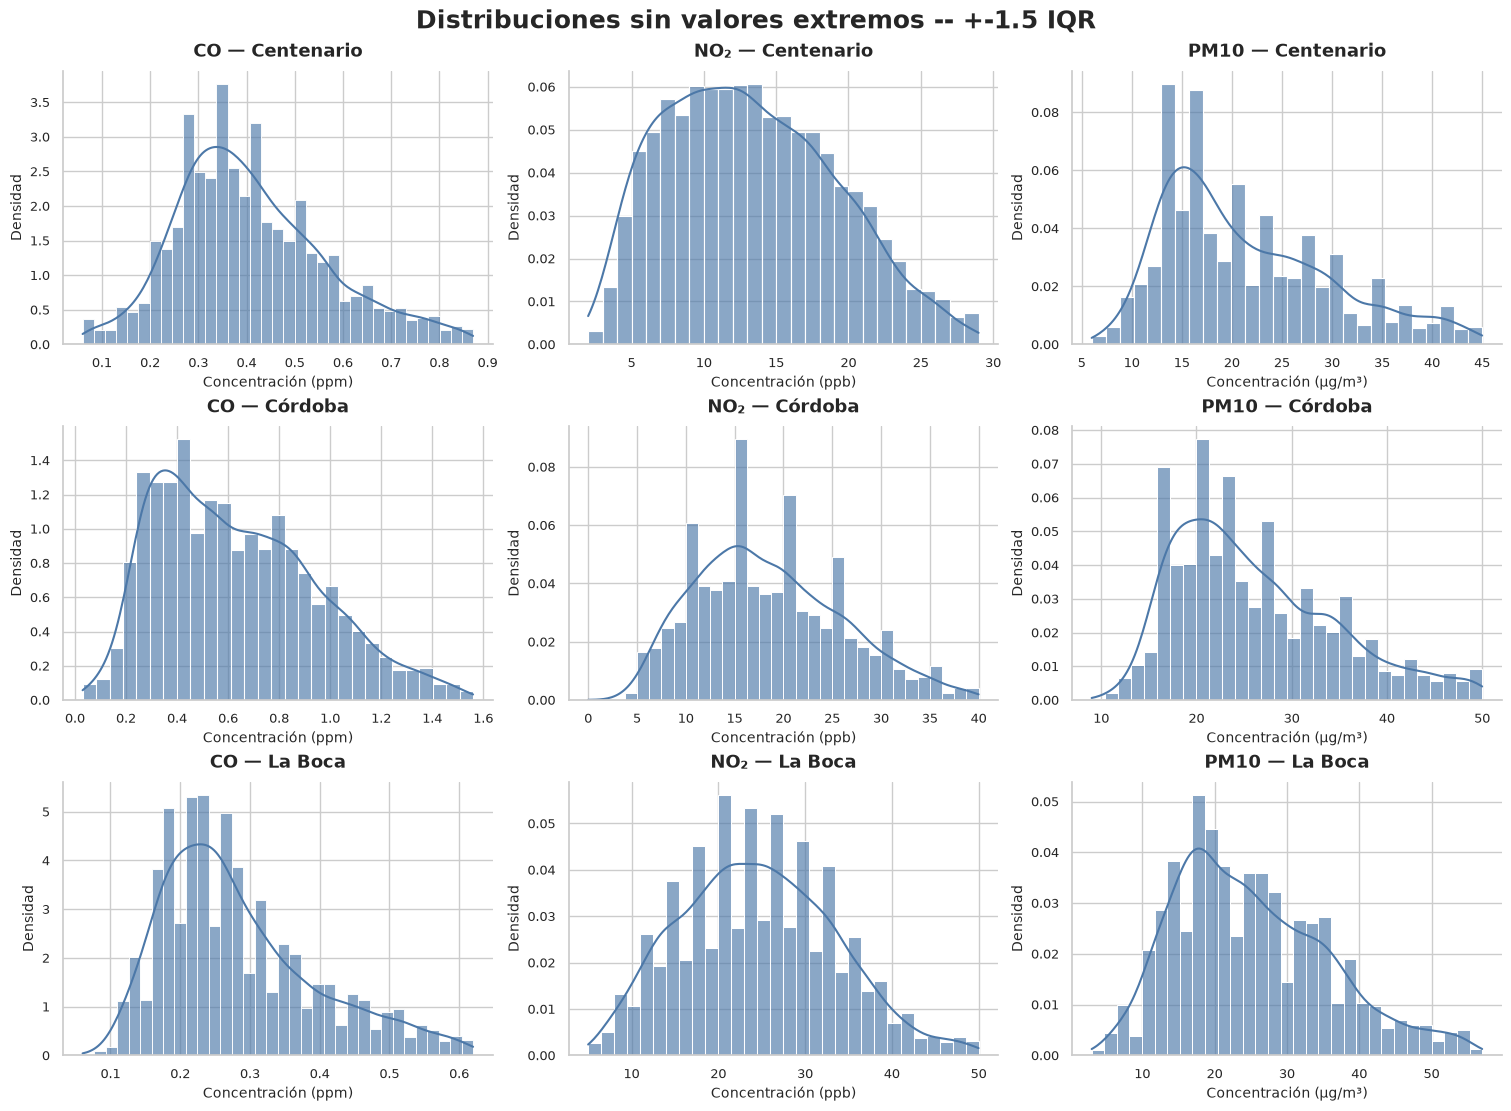

In [6]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 11),
    constrained_layout=True
)

for ax, variable in zip(axes.flat, variables):

    datos = df[variable].dropna()

    # Límite para detectar valores extremos
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Solo para el histograma
    datos_grafico = datos[(datos >= limite_inferior) & (datos <= limite_superior)]

    sns.histplot(
        datos_grafico,
        bins="fd",
        kde=True,
        stat="density",
        alpha=0.65,
        color=COLOR_ORIGINAL,
        ax=ax
    )

    ax.set_title(nombres.get(variable, variable), fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel(f"Concentración ({unidades[variable]})", fontsize=10)
    ax.set_ylabel("Densidad", fontsize=10)
    ax.tick_params(axis="both", labelsize=9)
    sns.despine(ax=ax)

fig.suptitle(
    "Distribuciones sin valores extremos -- +-1.5 IQR",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [7]:
variables = [col for col in df.columns if col not in ["fecha", "hora"]]

resultados = []

for variable in variables:

    datos = df[variable].dropna()

    # Calcular IQR
    Q1 = datos.quantile(0.25)
    Q3 = datos.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Conservar solamente los valores dentro de los límites
    datos_sin_outliers = datos[
        (datos >= limite_inferior) &
        (datos <= limite_superior)
    ]

    resultados.append({
        "Variable": variable,
        "n": len(datos_sin_outliers),
        "Media": datos_sin_outliers.mean(),
        "Mediana": datos_sin_outliers.median(),
        "Desv. Est.": datos_sin_outliers.std(),
        "Mínimo": datos_sin_outliers.min(),
        "Máximo": datos_sin_outliers.max(),
        "Asimetría": datos_sin_outliers.skew(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior
    })

tabla_iqr = pd.DataFrame(resultados)

tabla_iqr = tabla_iqr.round(3)

tabla_iqr

,Variable,n,Media,Mediana,Desv. Est.,Mínimo,Máximo,Asimetría,Q1,Q3,IQR,Límite inferior,Límite superior
0,co_centenario,5124,0.410,0.39,0.157,0.06,0.87,0.574,0.30,0.530,0.230,-0.045,0.875
1,no2_centenario,5334,13.154,13.00,5.868,2.00,29.00,0.351,9.00,17.000,8.000,-3.000,29.000
2,pm10_centenario,4992,21.480,19.00,8.453,6.00,45.00,0.765,15.00,27.000,12.000,-3.000,45.000
3,co_cordoba,5425,0.633,0.59,0.312,0.03,1.56,0.557,0.38,0.852,0.473,-0.329,1.561
4,no2_cordoba,5337,18.510,18.00,7.496,0.00,40.00,0.457,13.00,24.000,11.000,-3.500,40.500
5,pm10_cordoba,5065,26.145,24.00,8.484,9.00,50.00,0.767,20.00,32.000,12.000,2.000,50.000
6,co_la_boca,4743,0.284,0.26,0.112,0.06,0.62,0.879,0.20,0.370,0.170,-0.055,0.625
7,no2_la_boca,4980,24.524,24.00,8.871,5.00,50.00,0.246,18.00,31.000,13.000,-1.500,50.500
8,pm10_la_boca,4639,25.143,23.00,10.682,3.00,57.00,0.607,17.00,33.000,16.000,-7.000,57.000


### 1.a Gráfico QQ
El gráfico QQ para el CO en La Boca confirma que estas dos observaciones son anómalas y por lo tanto de aquí en adelante lo vamos a eliminar.
La estrategia a tomar para no complicarla es establecerlos como lecturas vacías o NaN.

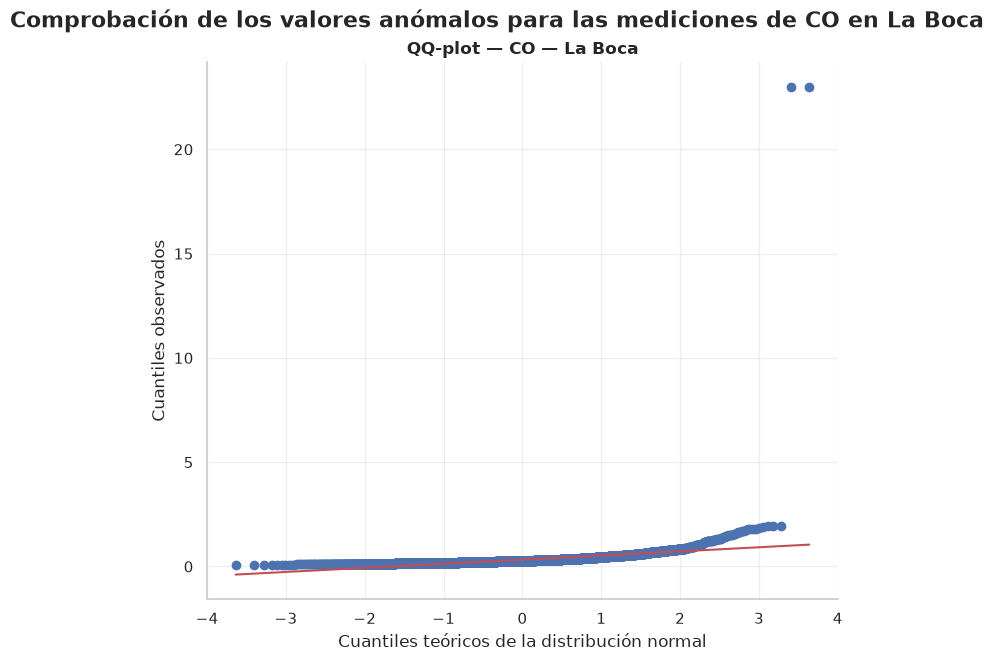

In [8]:
import scipy.stats as stats
import matplotlib.pyplot as plt

variable = 'co_la_boca'

fig, ax = plt.subplots(figsize=(7, 6.5), constrained_layout=True)

datos = df[variable].dropna()

stats.probplot(datos, dist="norm", plot=ax)

ax.set_title(
    f'QQ-plot — {nombres[variable]}',
    fontsize=12,
    fontweight='bold'
)

ax.set_xlabel('Cuantiles teóricos de la distribución normal')
ax.set_ylabel('Cuantiles observados')

ax.grid(True, alpha=0.3)
sns.despine(ax=ax)

fig.suptitle(
    'Comprobación de los valores anómalos para las mediciones de CO en La Boca',
    fontsize=16,
    fontweight='bold'
)

plt.show()

In [9]:
df.loc[df["co_la_boca"] == 23.00, "co_la_boca"] = np.nan

### 1.a Gráfico QQ

Ahora si, sin valores anómalos obtenemos un qq-plot más amigable.
Lo que podemos observar en todos los gráficos qq es que ninguna variable ajusta bien a lo cuantiles esperados de una distribución normal.
Se observa lo mismo que veíamos en los histogramas anteriores, que las distribuciones son distribuciones de cola pesada, por lo que mientras más desvíos esándar nos alejamos de la media mayor es la diferencia entre el valor esperado para el cuantil en la normal y el valor observado en los datos (Q_esperado < Q_observado).

Sin embargo para la mayoría de los casos si nos ubicamos en el rango de +-1.5 desvíos estándar dentro de todo ajustan bastante bien a lo esperado en una distribución normal.

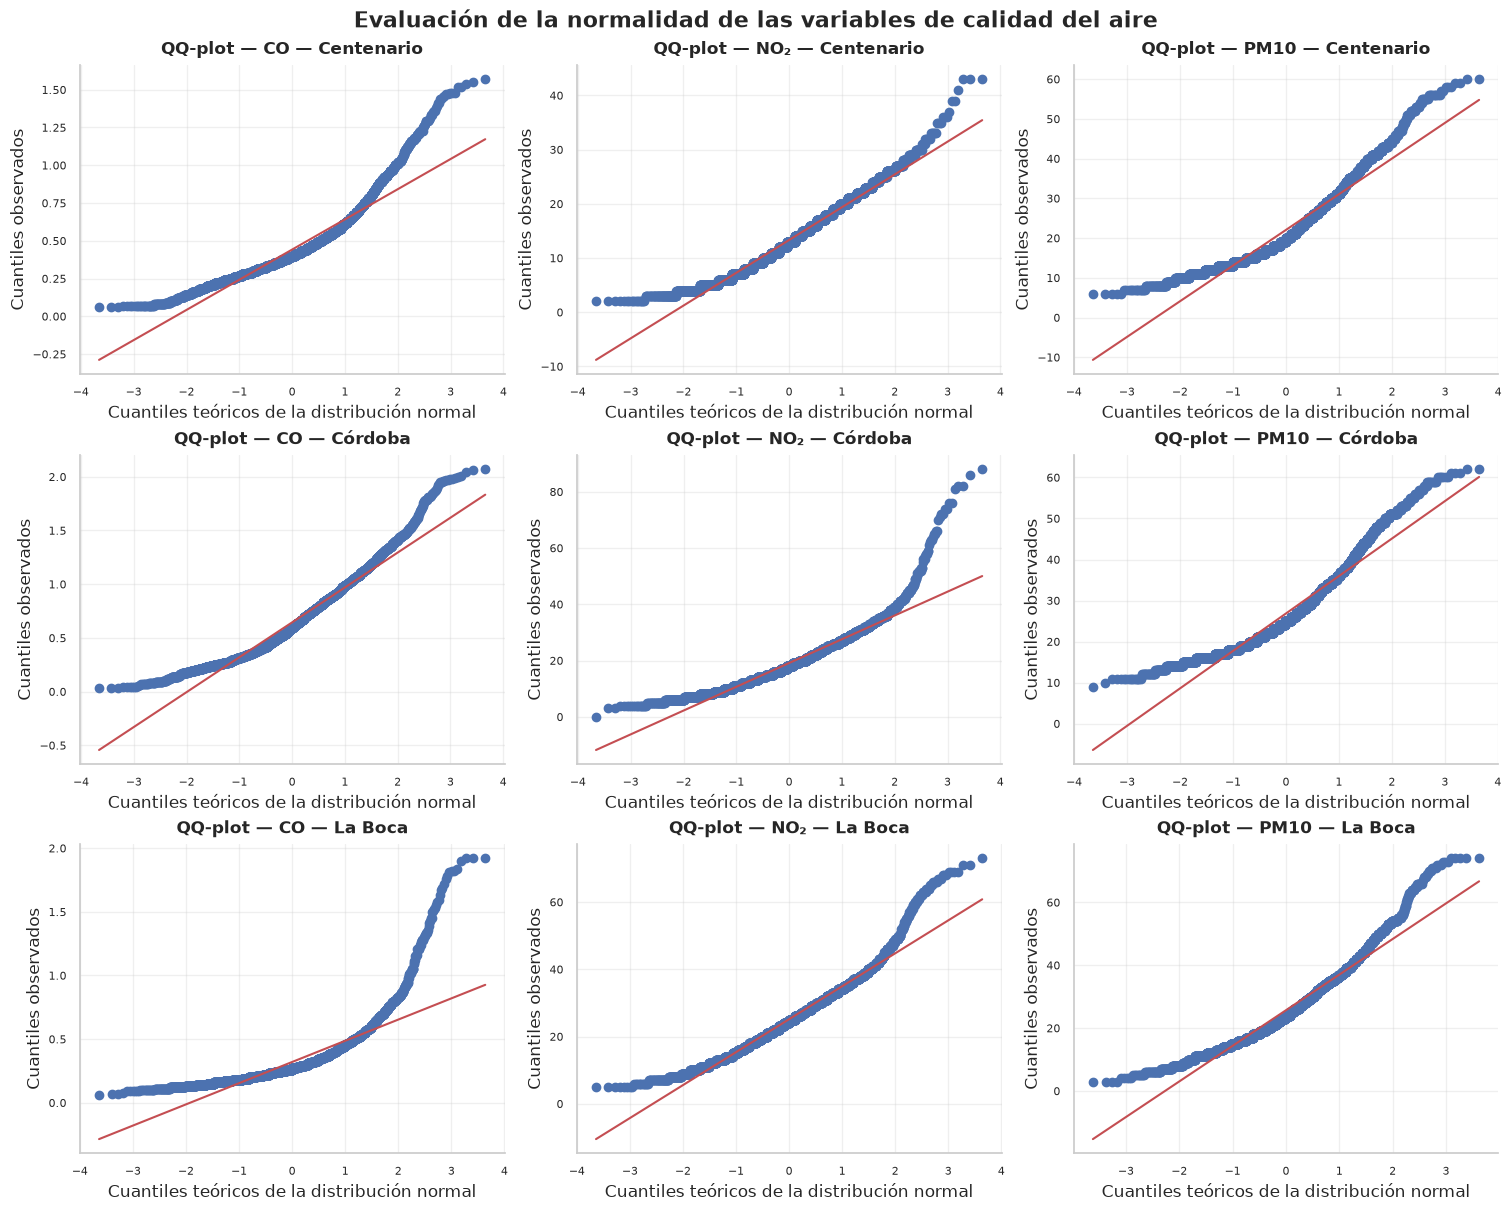

In [10]:
import scipy.stats as stats
# Variables de calidad del aire
variables = [
    'co_centenario',
    'no2_centenario',
    'pm10_centenario',
    'co_cordoba',
    'no2_cordoba',
    'pm10_cordoba',
    'co_la_boca',
    'no2_la_boca',
    'pm10_la_boca'
]

# Crear figura 3x3
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)

# Recorrer variables y gráficos
for ax, variable in zip(axes.flatten(), variables):

    # Eliminar valores faltantes
    datos = df[variable].dropna()

    # QQ-plot respecto de una distribución normal
    stats.probplot(datos, dist="norm", plot=ax)

    # Título
    ax.set_title(f'QQ-plot — {nombres[variable]}', fontsize=12, fontweight='bold', pad=8)

    # Labels
    ax.set_xlabel('Cuantiles teóricos de la distribución normal')
    ax.set_ylabel('Cuantiles observados')

    # Grilla
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=8)
    sns.despine(ax=ax)


# Título general
fig.suptitle(
    'Evaluación de la normalidad de las variables de calidad del aire',
    fontsize=16,
    fontweight='bold'
)

plt.show()

### 1.b Binning por frecuencias iguales

Lo que se hace acá es tomar la serie de datos (sacando los datos nulos), agruparlos en *bins* de igual frecuencia, es decir que cada *bin* va a contener la misma cantidad de observaciones, calcular la media para cada *bin* y luego reemplazar el valor original por la media obtenida.

La serie obtenida luego de aplicar binning con una cantidad de *bins* entre 6-15 se trata de una serie más suave, sin tanta variación como se puede ver en la reducción de picos en el gráfico, pero sin perder las caractéristicas del set de datos original ya que conserva a grandes rasgos la forma que tiene la serie original (el gráfico en azul).

Para la elección de los *bins* es muy dependiente de cada serie de datos, en este caso por simplicidad se usa la misma cantidad de bins para cada variable, pero en realidad habría que probar para cada una cual es la división que da los mejores resultados.
Un rango de 6-15 *bins* se puede observar que funciona dentro de todo bien para todas las variables.
Para algunas variables se puede usar un K=2-4, pero con K=2-4 hay otras variables como CO en La Boca o NO2 en Córdoba que pierden bastante detalle, se suavizan demasiado.

Y al contrario, cuando aumentamos demasiado la cantidad de *bins*, como puede ser K=40, se puede comenzar a ver cómo la serie generada se va ajustando y pareciendo más a la original, por lo que se conserva un mayor detalle o pequeñas fluctuaciones, pero también se conserva más el ruido.

co_centenario
(0.059, 0.27]     930
(0.27, 0.33]      869
(0.33, 0.4]      1004
(0.4, 0.48]       883
(0.48, 0.61]      854
(0.61, 1.57]      855
Name: count, dtype: int64

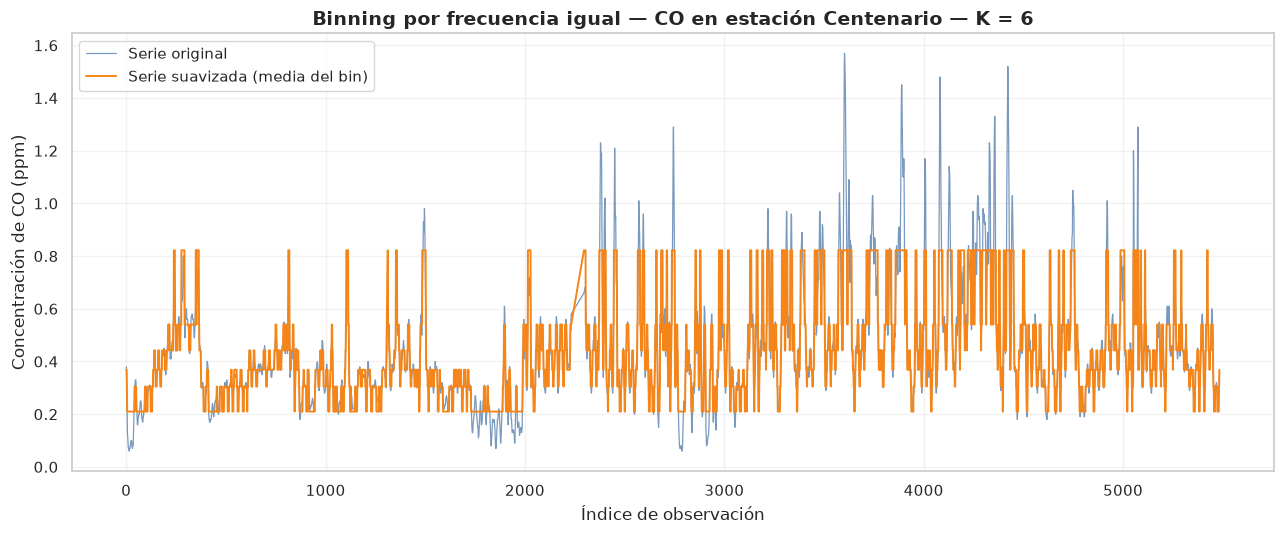

no2_centenario
(1.999, 7.0]    1056
(7.0, 9.0]       606
(9.0, 12.0]      956
(12.0, 14.0]     607
(14.0, 17.0]     812
(17.0, 20.0]     626
(20.0, 43.0]     716
Name: count, dtype: int64

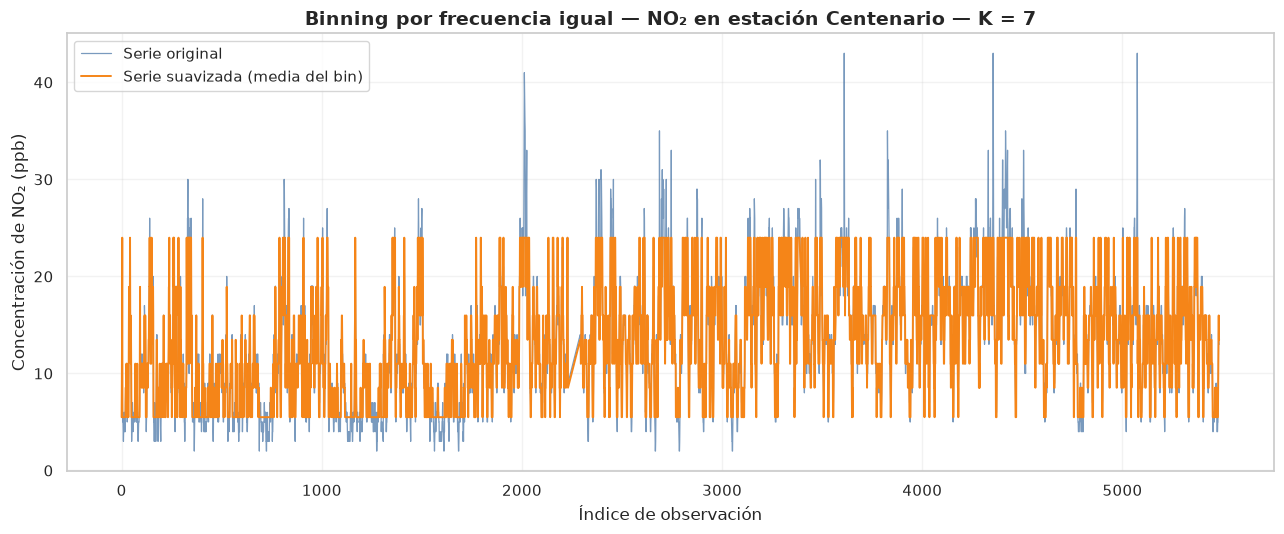

pm10_centenario
(5.999, 13.0]    808
(13.0, 15.0]     646
(15.0, 17.0]     610
(17.0, 20.0]     658
(20.0, 23.0]     505
(23.0, 27.0]     594
(27.0, 34.0]     675
(34.0, 60.0]     596
Name: count, dtype: int64

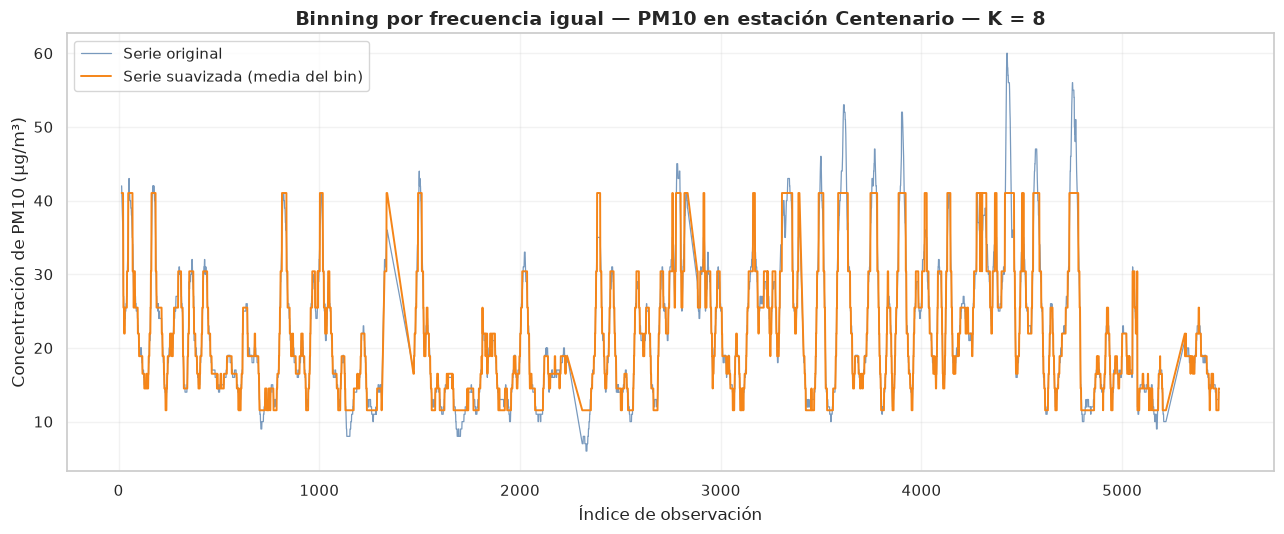

co_cordoba
(0.028999999999999998, 0.28]    684
(0.28, 0.36]                    595
(0.36, 0.44]                    579
(0.44, 0.54]                    618
(0.54, 0.65]                    601
(0.65, 0.77]                    631
(0.77, 0.89]                    595
(0.89, 1.07]                    586
(1.07, 2.07]                    595
Name: count, dtype: int64

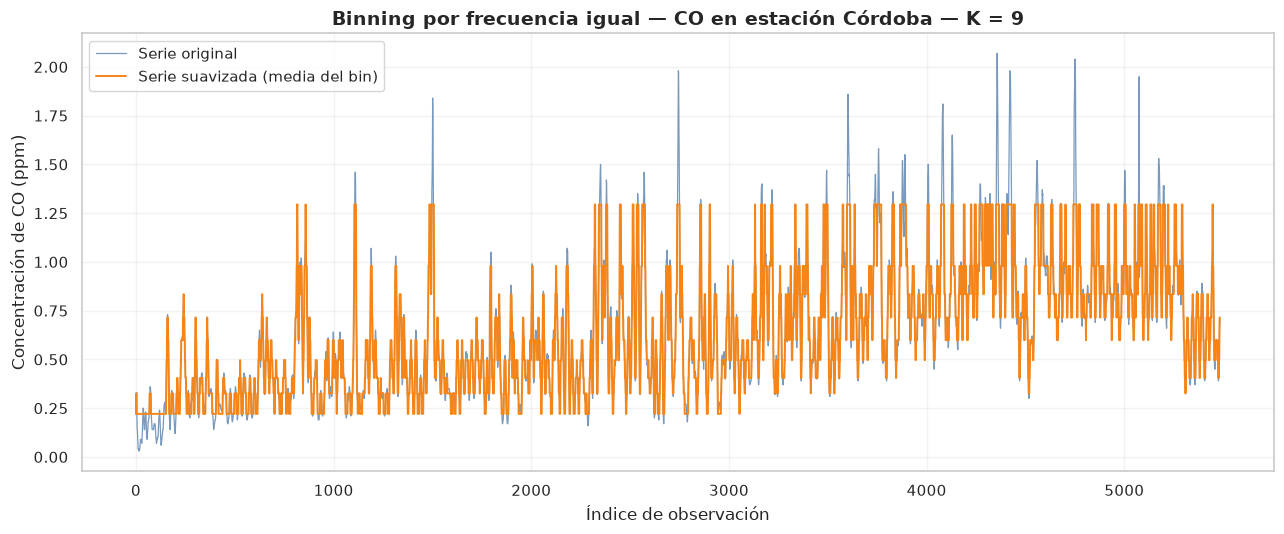

no2_cordoba
(-0.001, 9.0]    591
(9.0, 12.0]      668
(12.0, 14.0]     524
(14.0, 16.0]     597
(16.0, 18.0]     503
(18.0, 20.0]     513
(20.0, 23.0]     602
(23.0, 26.0]     493
(26.0, 30.0]     444
(30.0, 88.0]     501
Name: count, dtype: int64

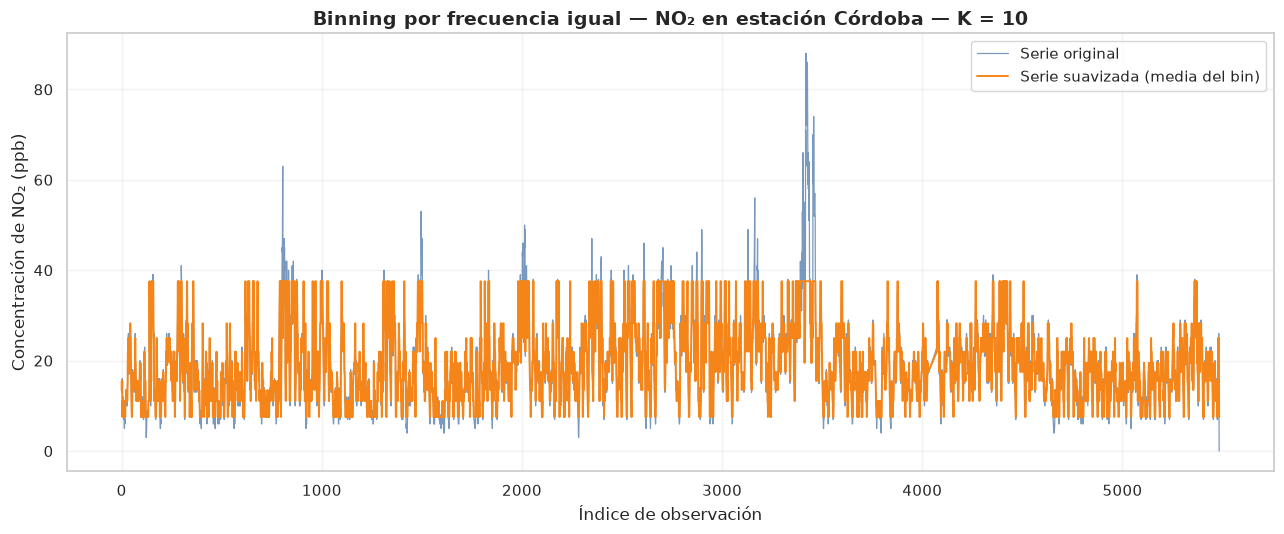

pm10_cordoba
(8.999, 17.0]    710
(17.0, 18.0]     278
(18.0, 20.0]     534
(20.0, 22.0]     578
(22.0, 24.0]     459
(24.0, 26.0]     435
(26.0, 28.0]     368
(28.0, 31.0]     439
(31.0, 35.0]     514
(35.0, 41.0]     416
(41.0, 62.0]     466
Name: count, dtype: int64

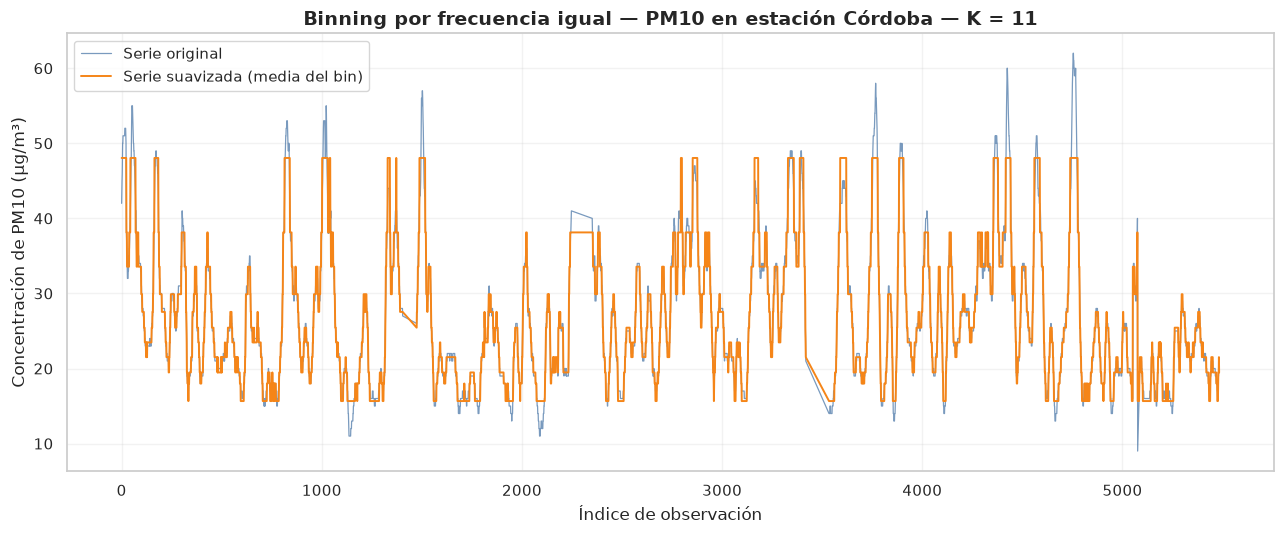

co_la_boca
(0.059, 0.16]    503
(0.16, 0.18]     369
(0.18, 0.2]      393
(0.2, 0.23]      607
(0.23, 0.25]     432
(0.25, 0.27]     388
(0.27, 0.29]     302
(0.29, 0.32]     381
(0.32, 0.37]     443
(0.37, 0.44]     402
(0.44, 0.56]     422
(0.56, 1.92]     409
Name: count, dtype: int64

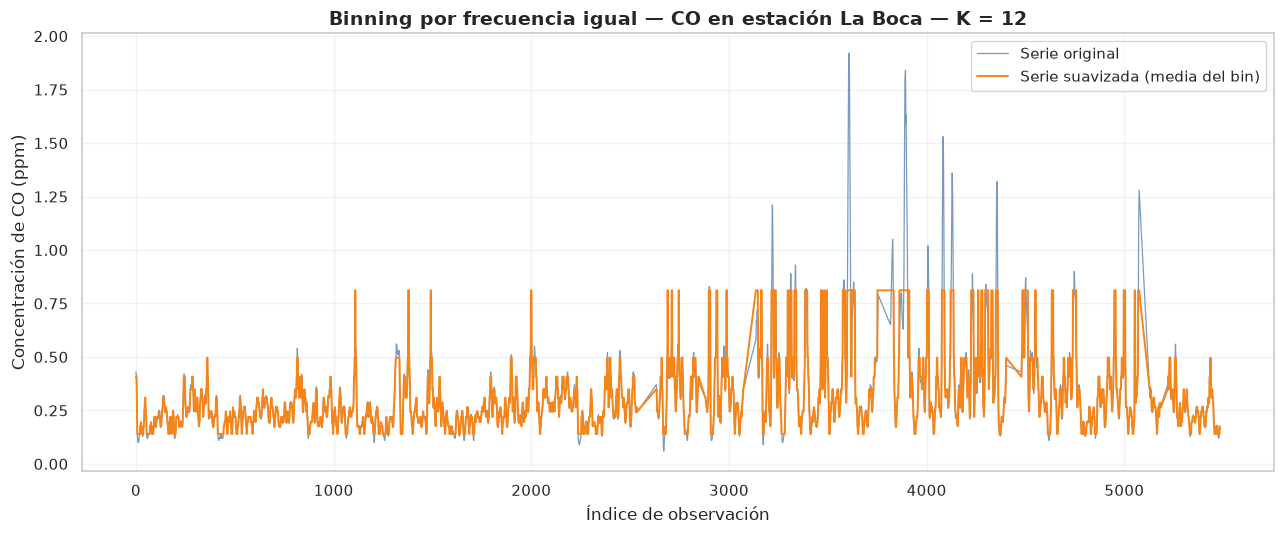

no2_la_boca
(4.999, 12.0]    431
(12.0, 15.0]     425
(15.0, 18.0]     491
(18.0, 20.0]     365
(20.0, 22.0]     433
(22.0, 23.0]     199
(23.0, 25.0]     418
(25.0, 27.0]     388
(27.0, 29.0]     382
(29.0, 32.0]     487
(32.0, 34.0]     291
(34.0, 39.0]     413
(39.0, 73.0]     348
Name: count, dtype: int64

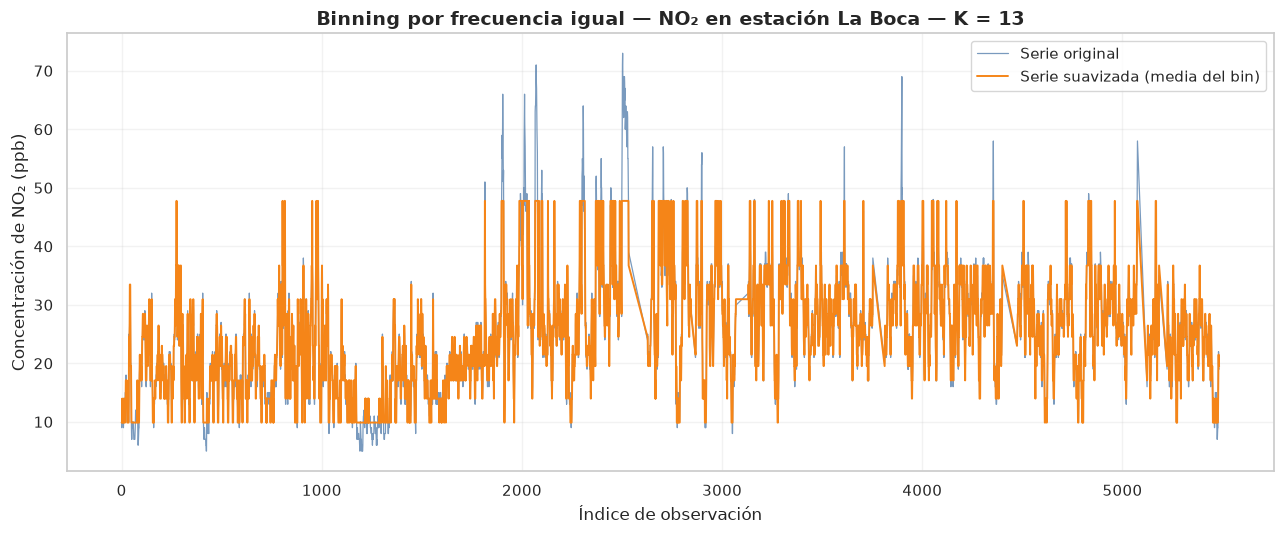

pm10_la_boca
(2.999, 12.0]    449
(12.0, 14.0]     257
(14.0, 16.0]     356
(16.0, 18.0]     415
(18.0, 20.0]     361
(20.0, 22.0]     302
(22.0, 24.0]     348
(24.0, 26.0]     309
(26.0, 28.0]     233
(28.0, 31.0]     362
(31.0, 34.0]     324
(34.0, 38.0]     374
(38.0, 44.0]     286
(44.0, 74.0]     326
Name: count, dtype: int64

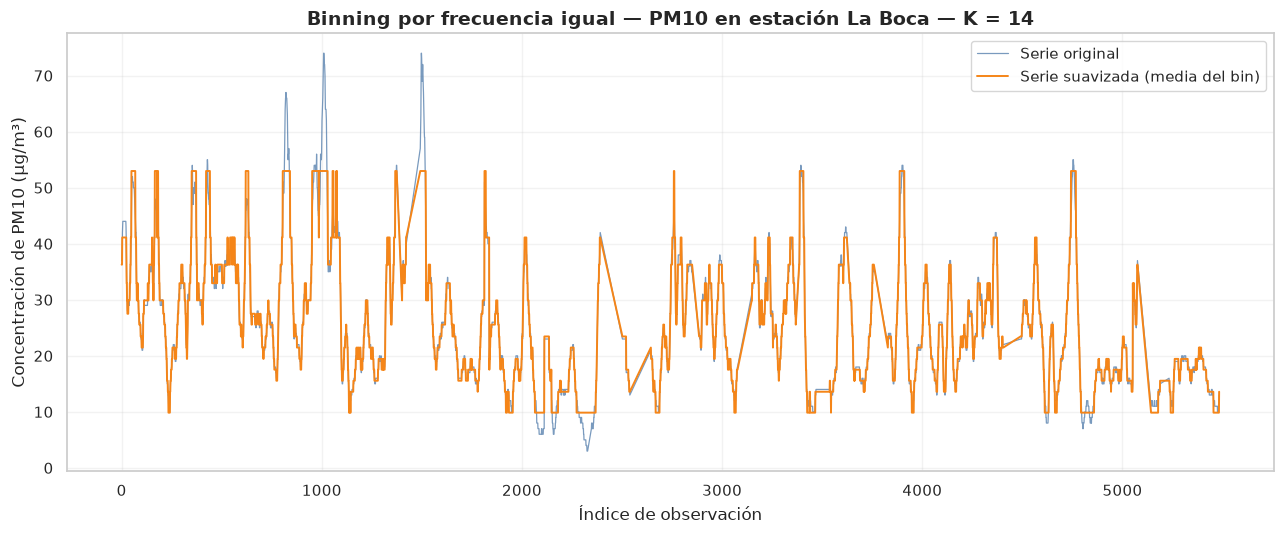

In [11]:
variables = [
    'co_centenario',
    'no2_centenario',
    'pm10_centenario',
    'co_cordoba',
    'no2_cordoba',
    'pm10_cordoba',
    'co_la_boca',
    'no2_la_boca',
    'pm10_la_boca'
]

nombres_variables = {
    'co_centenario': ('CO', 'Centenario'),
    'no2_centenario': ('NO₂', 'Centenario'),
    'pm10_centenario': ('PM10', 'Centenario'),
    'co_cordoba': ('CO', 'Córdoba'),
    'no2_cordoba': ('NO₂', 'Córdoba'),
    'pm10_cordoba': ('PM10', 'Córdoba'),
    'co_la_boca': ('CO', 'La Boca'),
    'no2_la_boca': ('NO₂', 'La Boca'),
    'pm10_la_boca': ('PM10', 'La Boca')
}

K = 6

for variable in variables:

    contaminante, estacion = nombres_variables[variable]

    # Eliminamos únicamente las observaciones nulas
    # de la variable que estamos analizando.
    serie = df[variable].dropna()

    bins = pd.qcut(
        serie,
        q=K,
        duplicates="drop"
    )

    # Mostrar información de los intervalos elegidos por cut
    #print(f"\n--- Información de bins para {contaminante} en {estacion} ---")
    display(bins.value_counts().sort_index())

    # Calculamos la media de cada bin
    serie_suavizada = serie.groupby(
        bins,
        observed=True
    ).transform("mean")


    # Gráfico
    plt.figure(figsize=(13, 5.5))

    plt.plot(
        serie.index,
        serie,
        label="Serie original",
        color=COLOR_ORIGINAL,
        alpha=0.75,
        linewidth=0.9
    )

    plt.plot(
        serie_suavizada.index,
        serie_suavizada,
        label="Serie suavizada (media del bin)",
        color=COLOR_SUAVIZADA,
        alpha=1,
        linewidth=1.4
    )

    plt.title(
        f"Binning por frecuencia igual — "
        f"{contaminante} en estación {estacion} — "
        f"K = {K}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Índice de observación")
    plt.ylabel(f"Concentración de {contaminante} ({unidades[variable]})")

    plt.legend(frameon=True)
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.show()
    K += 1

### 1.c Binning por igual ancho
#### Suavizado por extremos

Acá se aplica binning por igual ancho en lugar de igual frecuencia, lo que quiere decir que se eligen K intervalos del mismo ancho para formar los bins, por lo que no garantiza que cada bin tenga la misma cantidad de observaciones como si lo hace el de igual frecuencia.
Además se aplica suavizado por extremos, en lugar de calcular la media del bin y asignarla a todas las observaciones, lo que se hace para cada observación es calcular la distancia de la observación al valor máximo y mínimo de ese intervalo y elegir el valor que esté más cerca de la observación real.

Esto anterior explica el comportamiento de las series de datos a medida que variamos el K (número de bins) utilizado. Como se puede ver debajo cuando se usa un K muy pequeño como puede ser K=2, lo que termina ocurriendo es que se aumenta el ruido aún más, ya que los valores que antes no eran valores extremos se ven forzados a los extremos por valores mínimos y máximos.

co_centenario
(0.0585, 0.815]    5055
(0.815, 1.57]       340
Name: count, dtype: int64

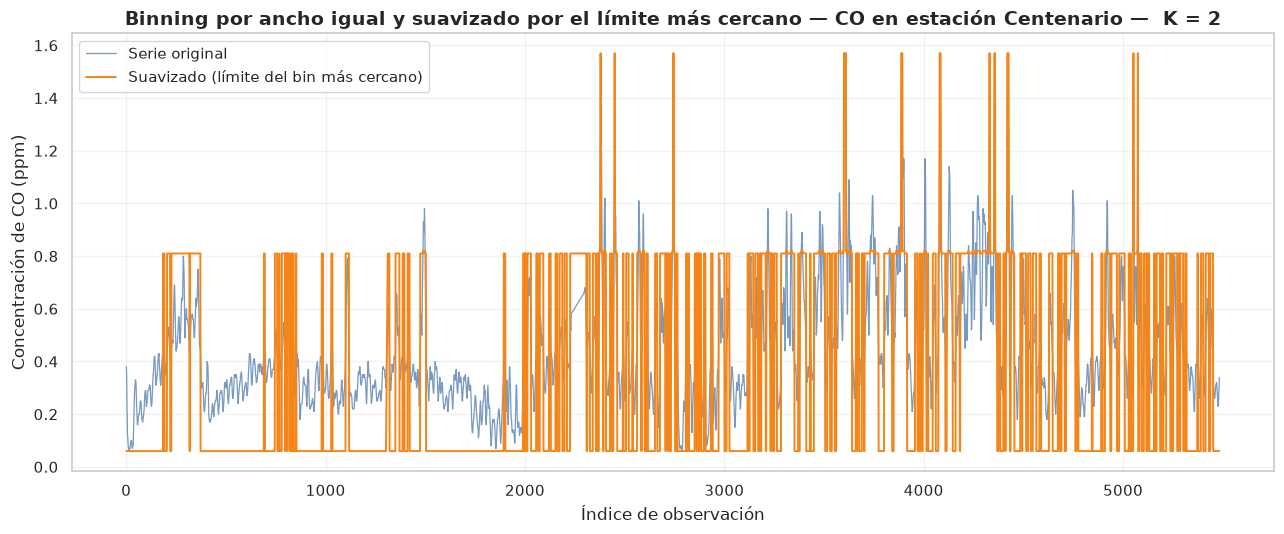

no2_centenario
(1.959, 15.667]     3509
(15.667, 29.333]    1825
(29.333, 43.0]        45
Name: count, dtype: int64

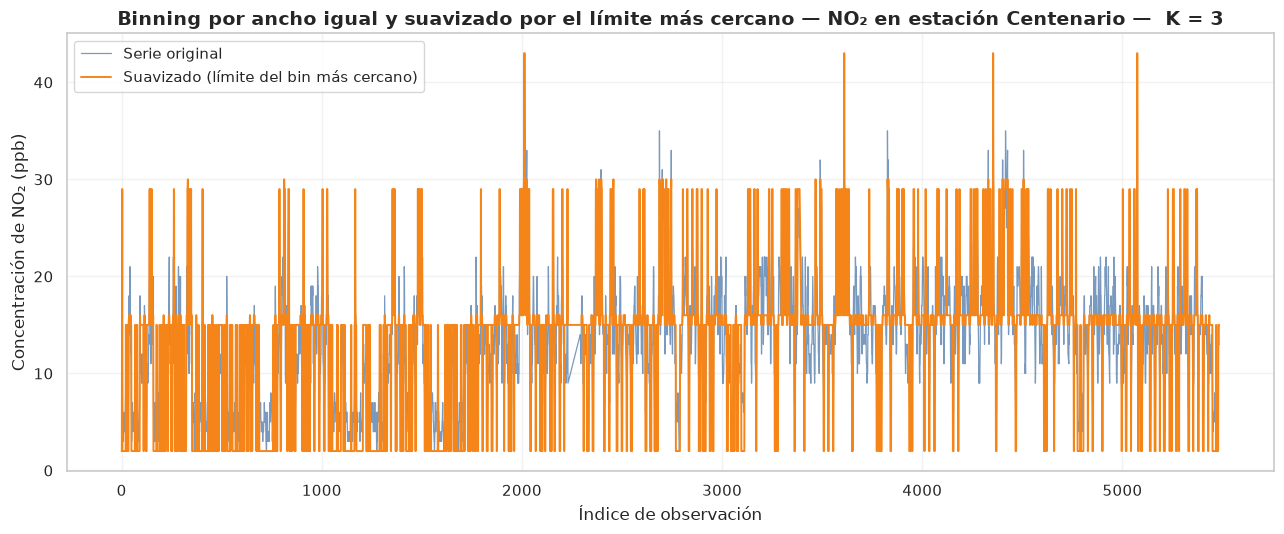

pm10_centenario
(5.946, 19.5]    2533
(19.5, 33.0]     1894
(33.0, 46.5]      578
(46.5, 60.0]       87
Name: count, dtype: int64

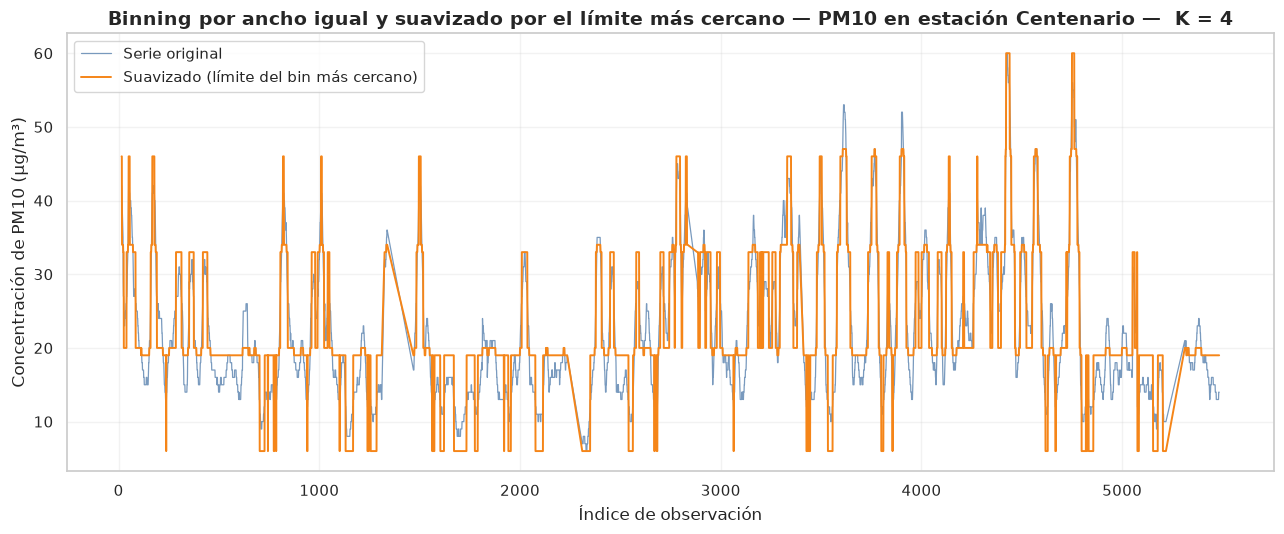

co_cordoba
(0.028, 0.438]    1803
(0.438, 0.846]    2259
(0.846, 1.254]    1148
(1.254, 1.662]     231
(1.662, 2.07]       43
Name: count, dtype: int64

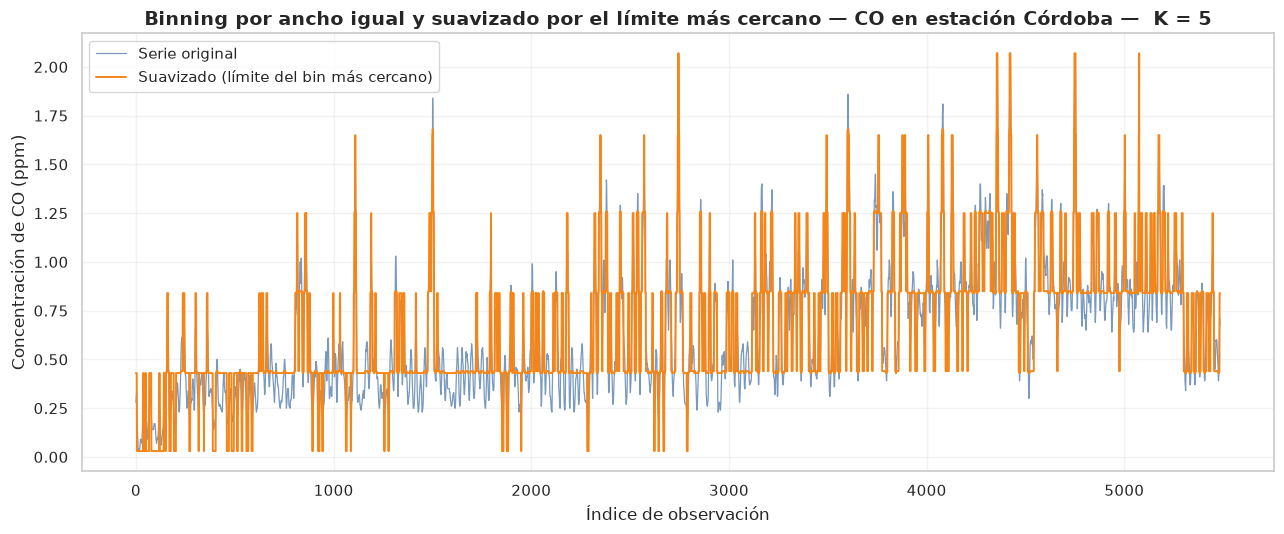

no2_cordoba
(-0.088, 14.667]    1783
(14.667, 29.333]    3073
(29.333, 44.0]       518
(44.0, 58.667]        38
(58.667, 73.333]      15
(73.333, 88.0]         9
Name: count, dtype: int64

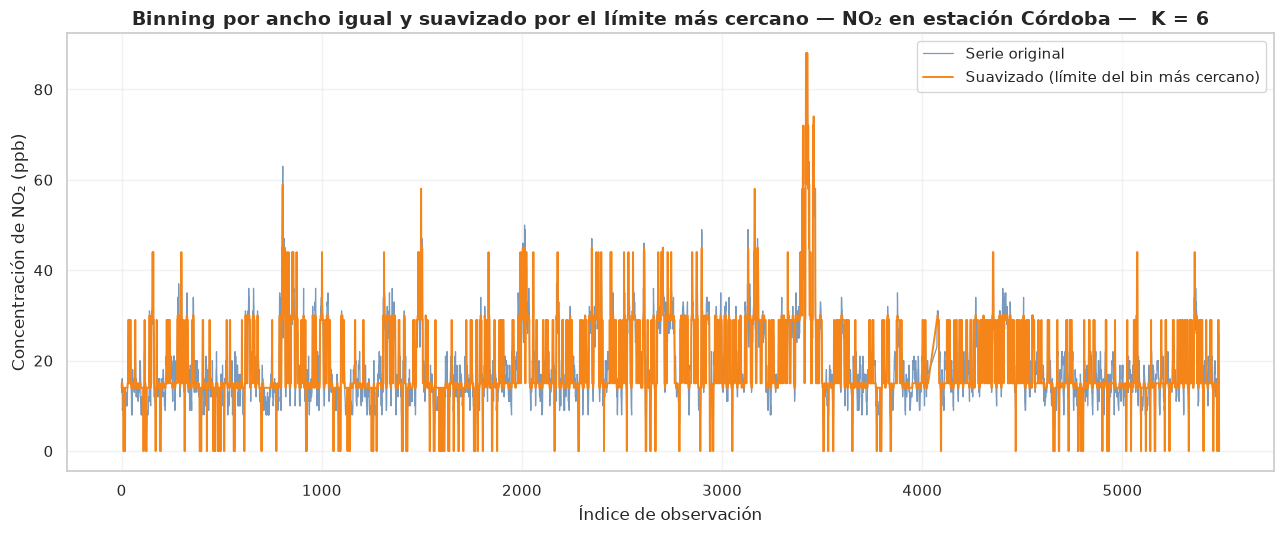

pm10_cordoba
(8.947, 16.571]      469
(16.571, 24.143]    2090
(24.143, 31.714]    1242
(31.714, 39.286]     819
(39.286, 46.857]     313
(46.857, 54.429]     214
(54.429, 62.0]        50
Name: count, dtype: int64

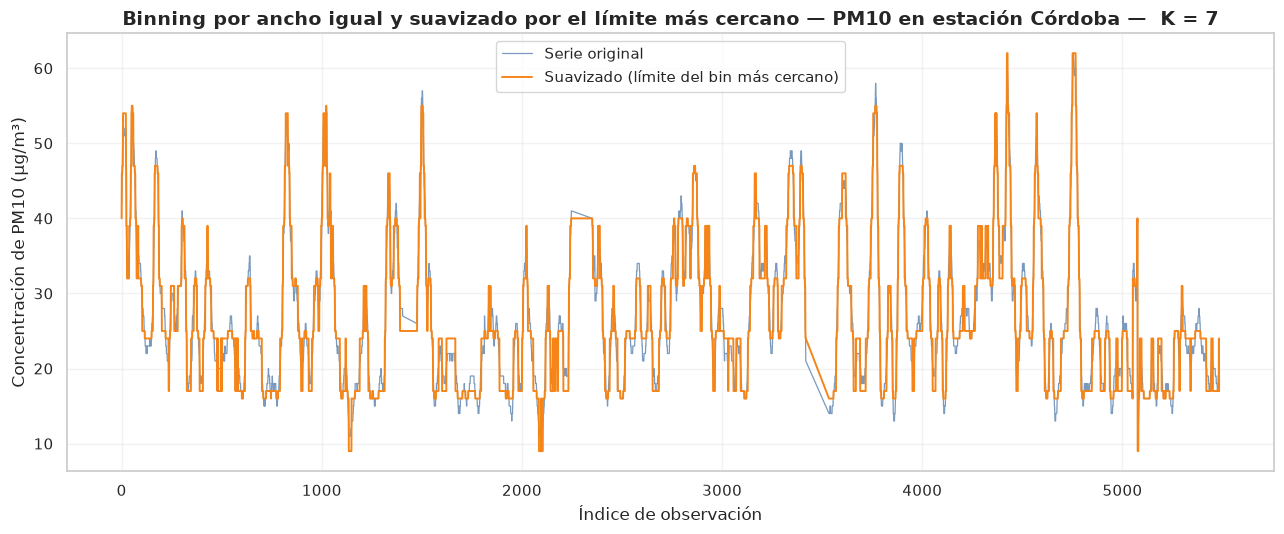

co_la_boca
(0.0581, 0.292]    2994
(0.292, 0.525]     1551
(0.525, 0.758]      334
(0.758, 0.99]       102
(0.99, 1.222]        29
(1.222, 1.455]       20
(1.455, 1.688]        9
(1.688, 1.92]        12
Name: count, dtype: int64

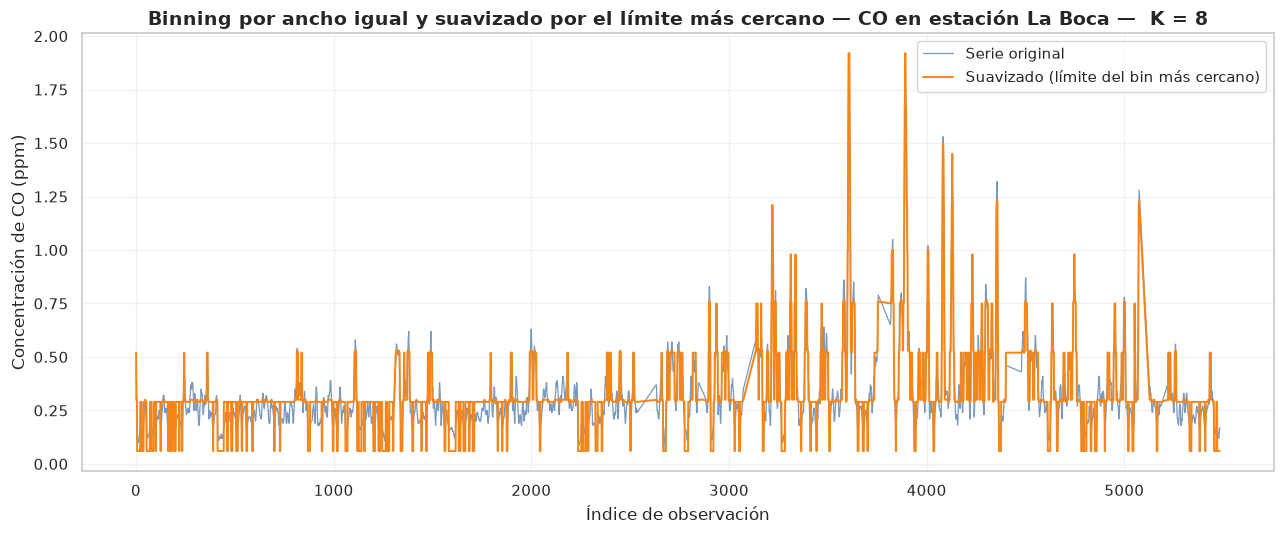

no2_la_boca
(4.932, 12.556]      431
(12.556, 20.111]    1281
(20.111, 27.667]    1438
(27.667, 35.222]    1258
(35.222, 42.778]     436
(42.778, 50.333]     136
(50.333, 57.889]      37
(57.889, 65.444]      37
(65.444, 73.0]        17
Name: count, dtype: int64

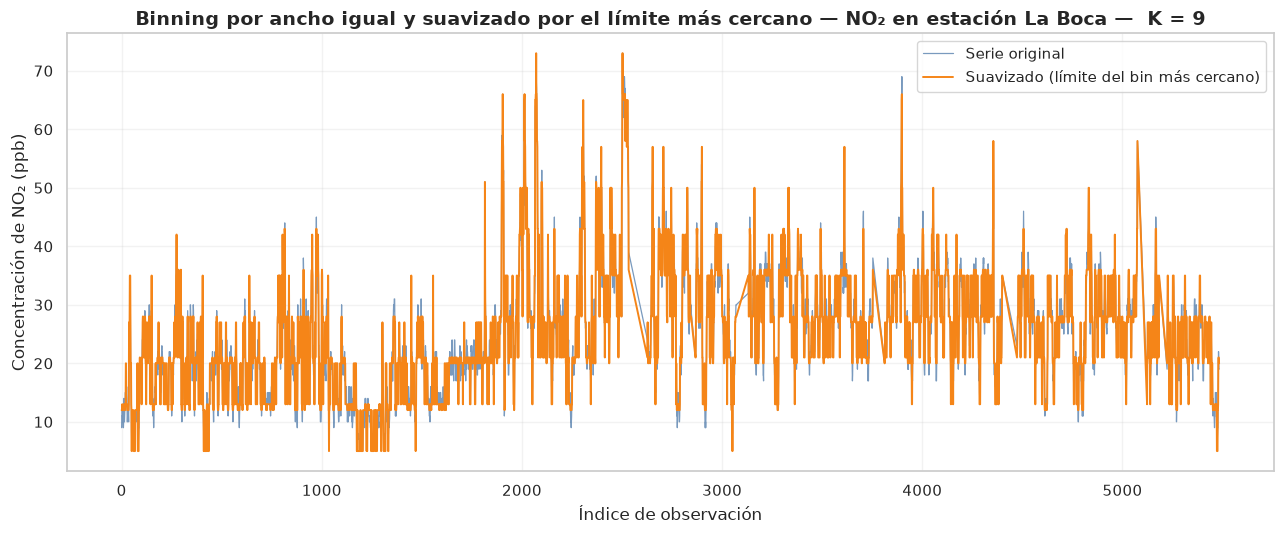

pm10_la_boca
(2.929, 10.1]     207
(10.1, 17.2]     1051
(17.2, 24.3]     1230
(24.3, 31.4]      904
(31.4, 38.5]      698
(38.5, 45.6]      317
(45.6, 52.7]      161
(52.7, 59.8]       77
(59.8, 66.9]       32
(66.9, 74.0]       25
Name: count, dtype: int64

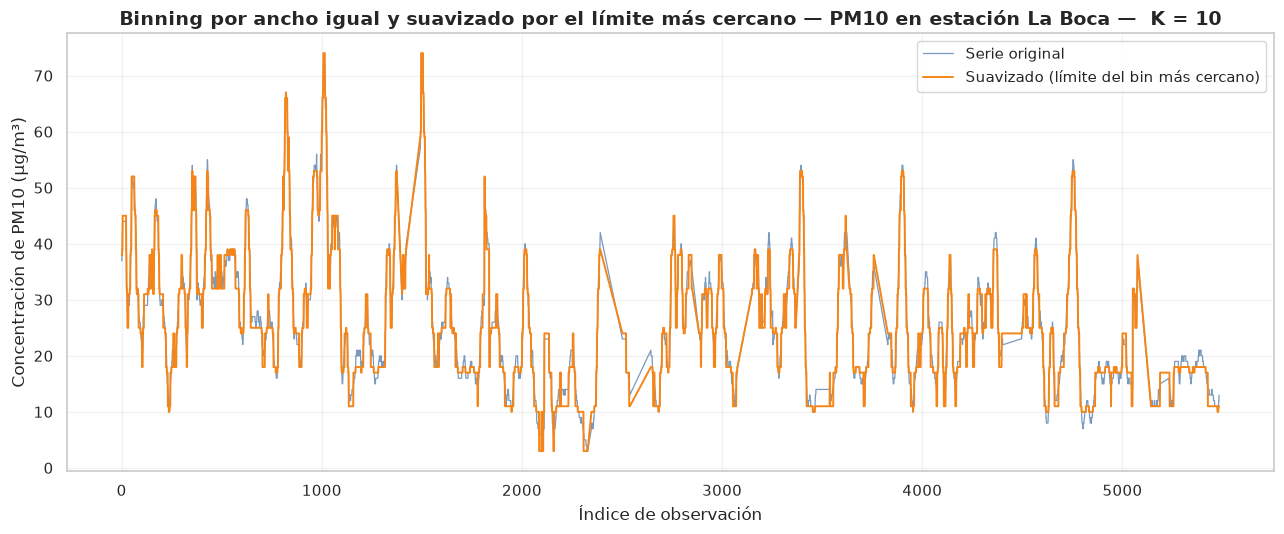

In [12]:
variables = [
    'co_centenario',
    'no2_centenario',
    'pm10_centenario',
    'co_cordoba',
    'no2_cordoba',
    'pm10_cordoba',
    'co_la_boca',
    'no2_la_boca',
    'pm10_la_boca'
]

nombres_variables = {
    'co_centenario': ('CO', 'Centenario'),
    'no2_centenario': ('NO₂', 'Centenario'),
    'pm10_centenario': ('PM10', 'Centenario'),
    'co_cordoba': ('CO', 'Córdoba'),
    'no2_cordoba': ('NO₂', 'Córdoba'),
    'pm10_cordoba': ('PM10', 'Córdoba'),
    'co_la_boca': ('CO', 'La Boca'),
    'no2_la_boca': ('NO₂', 'La Boca'),
    'pm10_la_boca': ('PM10', 'La Boca')
}

# Número de bins
K = 2

for variable in variables:


    contaminante, estacion = nombres_variables[variable]

    # Eliminamos únicamente las observaciones nulas
    serie = df[variable].dropna()

    # Binning por igual ancho
    # pd.cut devuelve una Serie de tipo Categorical con los intervalos
    binned_series = pd.cut(serie, bins=K, duplicates='drop')

    
    # Mostrar información de los intervalos elegidos por cut
    #print(f"\n--- Información de bins para {contaminante} en {estacion} ---")
    display(binned_series.value_counts().sort_index())

    # Obtener el valor mínimo y máximo *observado* dentro de cada bin
    serie_bin_min_val = serie.groupby(binned_series, observed=True).transform('min')
    serie_bin_max_val = serie.groupby(binned_series, observed=True).transform('max')

    # Calcular la distancia de cada valor original a la observación min/max de su bin
    dist_to_min_val = abs(serie - serie_bin_min_val)
    dist_to_max_val = abs(serie - serie_bin_max_val)

    # Aplicar el suavizado: elegir el valor min/max del bin más cercano,
    # si son equidistantes, elegir el mínimo del bin.
    serie_suavizada_cercana = pd.Series(
        np.where(dist_to_min_val <= dist_to_max_val, serie_bin_min_val, serie_bin_max_val),
        index=serie.index,
        name=f'{variable}_suavizada_cercana'
    )

    # Gráfico
    plt.figure(figsize=(13, 5.5))

    plt.plot(
        serie.index,
        serie,
        label="Serie original",
        color=COLOR_ORIGINAL,
        alpha=0.75,
        linewidth=0.9
    )

    plt.plot(
        serie_suavizada_cercana.index,
        serie_suavizada_cercana,
        label="Suavizado (límite del bin más cercano)",
        color=COLOR_SUAVIZADA,
        alpha=1,
        linewidth=1.4,
        linestyle='-'
    )

    plt.title(
        f"Binning por ancho igual y suavizado por el límite más cercano — "
        f"{contaminante} en estación {estacion} — "
        f" K = {K}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Índice de observación")
    plt.ylabel(f"Concentración de {contaminante} ({unidades[variable]})")

    plt.legend(frameon=True)
    plt.grid(alpha=0.25)
    plt.tight_layout()

    plt.show()

    K += 1


### 1.d Caso de aplicación: consumo eléctrico

Se utiliza el dataset [Electric Power Consumption](https://www.kaggle.com/datasets/fedesoriano/electric-power-consumption), que registra el consumo eléctrico de tres zonas junto con variables meteorológicas. Se eligió porque el consumo cambia a lo largo del día y presenta subidas y bajadas frecuentes: es un caso simple en el que puede ser útil reducir pequeñas variaciones para observar el comportamiento general.

El conjunto contiene 52.416 observaciones consecutivas, sin valores faltantes, tomadas cada diez minutos durante 364 días. Esta frecuencia permite estudiar una serie de consumo con bastante detalle y, al mismo tiempo, aplicar binning sin perder de vista el patrón diario.


In [13]:
energia = pd.read_csv("data/powerconsumption.csv")
energia["Datetime"] = pd.to_datetime(energia["Datetime"], format="%m/%d/%Y %H:%M")

intervalo = energia["Datetime"].diff().dropna().mode().iat[0]
resumen_energia = pd.DataFrame({
    "Observaciones": [len(energia)],
    "Período": [f"{energia['Datetime'].min():%d/%m/%Y} a {energia['Datetime'].max():%d/%m/%Y}"],
    "Intervalo": [str(intervalo)],
    "Faltantes": [int(energia.isna().sum().sum())],
})
display(resumen_energia)


,Observaciones,Período,Intervalo,Faltantes
0,52416,01/01/2017 a 30/12/2017,0 days 00:10:00,0


Para que el gráfico sea fácil de leer se analiza una jornada completa de `PowerConsumption_Zone1`, que contiene 144 mediciones. El objetivo es comparar el consumo registrado durante el día con una versión más simple de esa misma serie.

Se aplica binning por frecuencias iguales con media y $K=12$. En la práctica, esto separa los valores de consumo en doce grupos con la misma cantidad de observaciones y reemplaza cada valor por el promedio de su grupo. Así se atenúan los cambios pequeños y es más sencillo reconocer los momentos de consumo bajo, medio o alto.


,Original,Suavizada
Media,31604.05,31604.05
Desvío estándar,6358.05,6314.53
Mínimo,21006.33,22040.22
Máximo,44058.73,43637.12


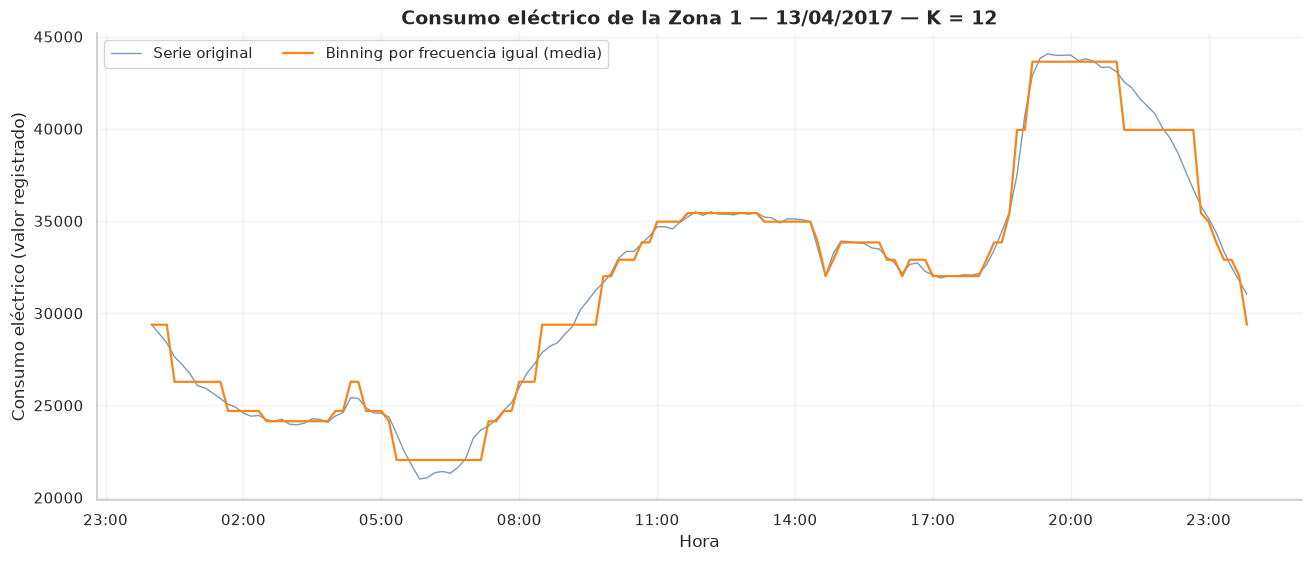

In [14]:
import matplotlib.dates as mdates

fecha_analisis = pd.Timestamp("2017-04-13")
datos_dia = energia.loc[energia["Datetime"].dt.normalize().eq(fecha_analisis)].copy()
serie_consumo = datos_dia["PowerConsumption_Zone1"]

K = 12
bins_consumo = pd.qcut(serie_consumo, q=K, duplicates="drop")
consumo_suavizado = serie_consumo.groupby(bins_consumo, observed=True).transform("mean")

resumen_suavizado = pd.DataFrame({
    "Original": [serie_consumo.mean(), serie_consumo.std(), serie_consumo.min(), serie_consumo.max()],
    "Suavizada": [consumo_suavizado.mean(), consumo_suavizado.std(), consumo_suavizado.min(), consumo_suavizado.max()],
}, index=["Media", "Desvío estándar", "Mínimo", "Máximo"])
display(resumen_suavizado.round(2))

fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
ax.plot(datos_dia["Datetime"], serie_consumo, label="Serie original",
        color=COLOR_ORIGINAL, alpha=0.75, linewidth=1)
ax.plot(datos_dia["Datetime"], consumo_suavizado, label="Binning por frecuencia igual (media)",
        color=COLOR_SUAVIZADA, linewidth=1.6)

ax.set_title("Consumo eléctrico de la Zona 1 — 13/04/2017 — K = 12",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Hora")
ax.set_ylabel("Consumo eléctrico (valor registrado)")
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(frameon=True, ncols=2)
ax.grid(alpha=0.25)
sns.despine(ax=ax)
plt.show()


El suavizado conserva el promedio diario de consumo, pero acerca los valores muy altos y muy bajos al promedio de su grupo. Por eso la línea suavizada permite ver con mayor claridad los períodos en los que el consumo se mantiene bajo, medio o alto durante varias mediciones.

La contrapartida es que los picos breves quedan menos visibles. En este caso, el binning sirve para obtener una visión general del comportamiento diario; si el objetivo fuera investigar un pico puntual de consumo, convendría volver a la serie original.


### Conclusiones del manejo de ruido

El binning por frecuencias iguales suaviza la serie al reemplazar los valores por la media de su grupo, mientras que el binning por anchos iguales y extremos conserva únicamente el límite más cercano de cada intervalo. Ambos casos tienen algo en común: pocos bins producen un suavizado más fuerte y pueden ocultar variaciones relevantes; al aumentar la cantidad de bins se preserva más detalle, pero también más ruido.


---

## 2. Detección de outliers

Un *outlier* es una observación que se aleja mucho de la mayor parte de los datos. No significa automáticamente que sea un error: puede representar una condición real poco frecuente, como una temperatura muy baja en una estación antártica. Por eso, primero se identifican valores candidatos y luego se los analiza con más detalle.


### Variables del dataset

Antes de buscar valores poco comunes, conviene conocer qué representa cada columna. El dataset contiene la fecha, hora, estación meteorológica y temporada de cada medición, además de cinco variables del clima. La tabla resume su tipo, unidad y cantidad de datos faltantes.


In [15]:
clima = pd.read_csv("data/clima_smn.csv")
clima["fecha"] = pd.to_datetime(clima["fecha"])

descripcion_variables = pd.DataFrame({
    "Variable": clima.columns,
    "Tipo": ["temporal", "temporal", "categórica", "categórica",
             "numérica", "numérica", "numérica", "numérica", "numérica"],
    "Descripción": ["día de la observación", "hora de la observación",
                    "nombre de la estación", "estación del año",
                    "temperatura del aire", "humedad relativa",
                    "presión atmosférica", "dirección del viento",
                    "velocidad del viento"],
    "Unidad": ["-", "hora", "-", "-", "°C", "%", "hPa", "grados", "km/h"],
    "Faltantes": clima.isna().sum().to_numpy(),
})
display(descripcion_variables)

# Resumen de cinco números y desvío estándar para las variables meteorológicas.
variables_climaticas = ["temperatura", "humedad", "presion", "dir_viento", "vel_viento"]
resumen_numerico = clima[variables_climaticas].describe(percentiles=[0.25, 0.5, 0.75]).T[
    ["count", "min", "25%", "50%", "75%", "max", "std", "mean"]
].rename(columns={
    "count": "Observaciones", "min": "Mínimo", "25%": "Q1",
    "50%": "Mediana", "75%": "Q3", "max": "Máximo",
    "std": "Desvío estándar", "mean": "Media",
})
display(resumen_numerico.round(2))


,Variable,Tipo,Descripción,Unidad,Faltantes
0,fecha,temporal,día de la observación,-,0
1,hora,temporal,hora de la observación,hora,0
2,estacion_meteorologica,categórica,nombre de la estación,-,0
3,temporada,categórica,estación del año,-,0
4,temperatura,numérica,temperatura del aire,°C,0
5,humedad,numérica,humedad relativa,%,5
6,presion,numérica,presión atmosférica,hPa,1726
7,dir_viento,numérica,dirección del viento,grados,2
8,vel_viento,numérica,velocidad del viento,km/h,2


,Observaciones,Mínimo,Q1,Mediana,Q3,Máximo,Desvío estándar,Media
temperatura,23019.0,-26.0,10.2,16.6,22.5,42.6,8.96,16.11
humedad,23014.0,6.0,53.0,72.0,87.0,100.0,21.19,68.70
presion,21293.0,963.2,1006.9,1012.9,1017.6,1038.7,9.39,1012.29
dir_viento,23017.0,0.0,90.0,180.0,270.0,990.0,167.20,192.94
vel_viento,23017.0,0.0,7.0,11.0,19.0,100.0,10.00,13.50


### 2.a Exploración inicial

Para tener una primera aproximación se revisan las variables numéricas de interés. En temperatura, humedad, presión y velocidad del viento se usa el criterio de rango intercuartílico (IQR): se consideran candidatos los valores que quedan por debajo de $Q1 - 1{,}5\times IQR$ o por encima de $Q3 + 1{,}5\times IQR$. La dirección del viento se evalúa aparte porque es una medida circular: 0° y 360° representan la misma dirección, por lo que en ese caso es más útil verificar el rango físico permitido.


In [16]:
variables_iqr = {
    "temperatura": "°C",
    "humedad": "%",
    "presion": "hPa",
    "vel_viento": "km/h",
}

resumen_outliers = []
for variable, unidad in variables_iqr.items():
    serie = clima[variable].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    candidatos = (serie < limite_inferior) | (serie > limite_superior)

    resumen_outliers.append({
        "Variable": variable,
        "Unidad": unidad,
        "Criterio": "IQR (1,5 × IQR)",
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Candidatos": candidatos.sum(),
        "% de candidatos": 100 * candidatos.mean(),
    })

# Para la dirección del viento se controla el rango físico posible: 0° a 360°.
direccion = clima["dir_viento"].dropna()
direccion_invalida = (direccion < 0) | (direccion > 360)
resumen_outliers.append({
    "Variable": "dir_viento",
    "Unidad": "grados",
    "Criterio": "Rango físico: 0° a 360°",
    "Límite inferior": 0,
    "Límite superior": 360,
    "Candidatos": direccion_invalida.sum(),
    "% de candidatos": 100 * direccion_invalida.mean(),
})

tabla_outliers = pd.DataFrame(resumen_outliers)
display(tabla_outliers.round(2))


,Variable,Unidad,Criterio,Límite inferior,Límite superior,Candidatos,% de candidatos
0,temperatura,°C,"IQR (1,5 × IQR)",-8.25,40.95,258,1.12
1,humedad,%,"IQR (1,5 × IQR)",2.00,138.00,0,0.00
2,presion,hPa,"IQR (1,5 × IQR)",990.85,1033.65,844,3.96
3,vel_viento,km/h,"IQR (1,5 × IQR)",-11.00,37.00,659,2.86
4,dir_viento,grados,Rango físico: 0° a 360°,0.00,360.00,579,2.52


La primera exploración indica que **temperatura**, **presión** y **velocidad del viento** tienen observaciones candidatas a ser outliers según el criterio IQR. La variable **humedad** no presenta candidatos con este criterio.

Además, `dir_viento` contiene 579 registros con valor 990°, que está fuera del rango posible para una dirección expresada en grados; por eso también requiere revisión. En los próximos puntos se usarán gráficos y otras medidas para decidir si los valores extremos de las demás variables son errores o condiciones meteorológicas reales.


### 2.b Análisis gráfico con boxplots

El boxplot permite resumir rápidamente una variable. La caja contiene el 50% central de los valores, la línea dentro de la caja marca la mediana y los puntos que quedan fuera de los bigotes son los mismos valores candidatos que se identificaron con el criterio IQR. Cada variable se grafica por separado porque usan unidades y escalas diferentes.


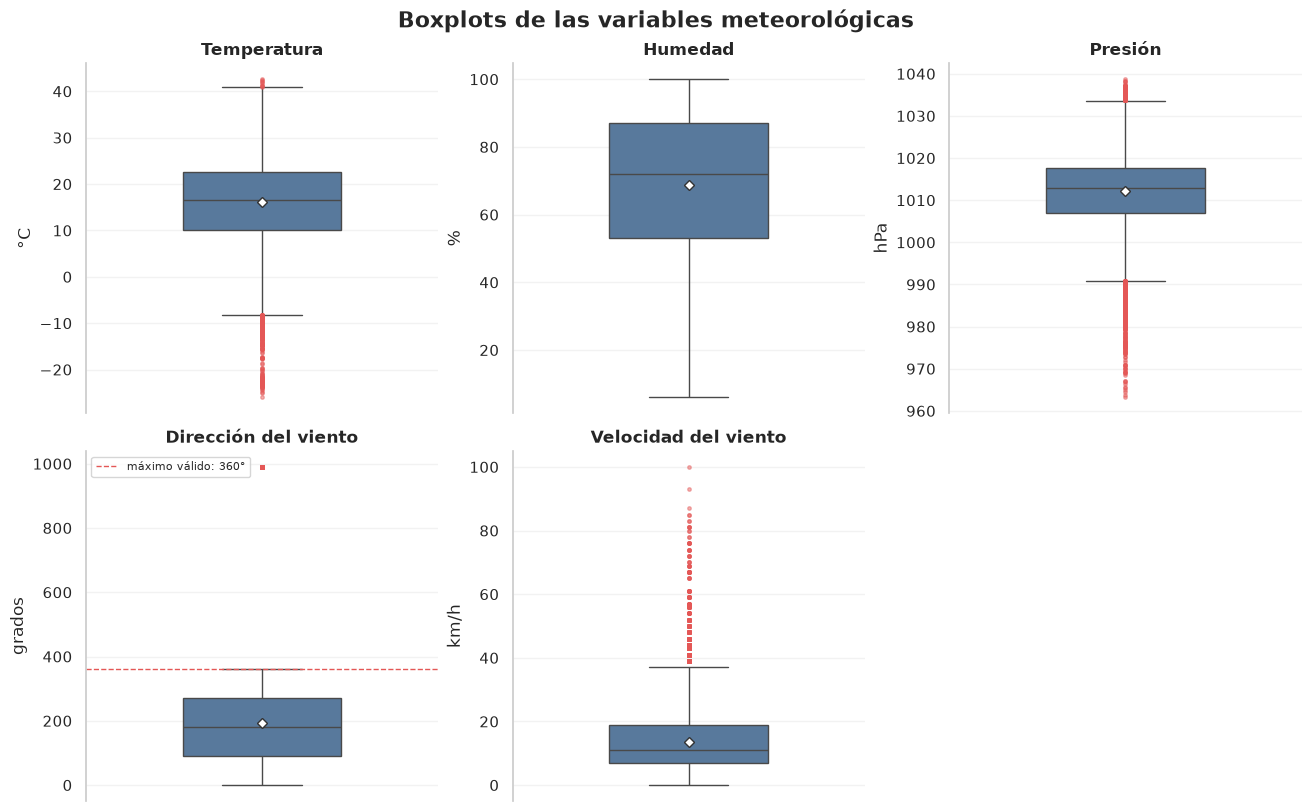

In [17]:
nombres_clima = {
    "temperatura": "Temperatura",
    "humedad": "Humedad",
    "presion": "Presión",
    "dir_viento": "Dirección del viento",
    "vel_viento": "Velocidad del viento",
}
unidades_clima = {
    "temperatura": "°C", "humedad": "%", "presion": "hPa",
    "dir_viento": "grados", "vel_viento": "km/h",
}

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
flierprops = dict(marker="o", markersize=2.5, markerfacecolor="#E45756",
                  markeredgecolor="#E45756", alpha=0.45)
meanprops = dict(marker="D", markerfacecolor="white", markeredgecolor="#333333", markersize=5)

for ax, variable in zip(axes.flat, variables_climaticas):
    sns.boxplot(y=clima[variable], ax=ax, color=COLOR_ORIGINAL, width=0.45,
                showmeans=True, flierprops=flierprops, meanprops=meanprops)
    ax.set_title(nombres_clima[variable], fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(unidades_clima[variable])
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax, left=False, bottom=True)

    if variable == "dir_viento":
        ax.axhline(360, color="#E45756", linestyle="--", linewidth=1, label="máximo válido: 360°")
        ax.legend(frameon=True, fontsize=8, loc="upper left")

axes.flat[-1].set_visible(False)
fig.suptitle("Boxplots de las variables meteorológicas", fontsize=16, fontweight="bold")
plt.show()


Los gráficos confirman la exploración inicial. La **humedad** no muestra puntos aislados fuera de los bigotes. En **temperatura**, **presión** y **velocidad del viento** se observan valores alejados de la mayor parte de las mediciones.

En `dir_viento`, los valores de 990° se ven claramente por encima de la línea de 360°, por lo que no son direcciones válidas. Los valores extremos de las otras variables todavía no deben descartarse: pueden estar relacionados con una estación, una temporada o una condición meteorológica real.


### 2.c Distancia a la media y comparación con los bigotes

Una segunda forma de describir qué tan alejado está un valor es el **z-score**. El z-score indica a cuántos desvíos estándar se encuentra una observación respecto de la media: un valor positivo está por encima de la media y uno negativo está por debajo. Por ejemplo, un z-score de −4 significa que el valor está cuatro desvíos estándar por debajo de la media.

$$z = \frac{x - \text{media}}{\text{desvío estándar}}$$

Se calculan los z-scores de los valores candidatos encontrados en 2.a. La tabla no lista cada observación por separado: muestra el rango de z-scores que tienen esos candidatos y el más alejado de cada variable. También se indican los bigotes reales del boxplot, es decir, el menor y el mayor valor que todavía quedaron dentro de ellos.


In [18]:
resumen_zscore = []

for variable in variables_climaticas:
    serie = clima[variable].dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    # Los bigotes llegan al dato más extremo que todavía está dentro de los límites IQR.
    dentro_bigotes = serie[(serie >= limite_inferior) & (serie <= limite_superior)]

    if variable == "dir_viento":
        candidatos = (serie < 0) | (serie > 360)
    else:
        candidatos = (serie < limite_inferior) | (serie > limite_superior)

    z = (serie - serie.mean()) / serie.std()
    z_candidatos = z[candidatos]
    valores_candidatos = serie[candidatos]

    if len(z_candidatos) > 0:
        resumen_zscore.append({
            "Variable": variable,
            "Bigote inferior": dentro_bigotes.min(),
            "Bigote superior": dentro_bigotes.max(),
            "Candidatos": len(z_candidatos),
            "Valor candidato mínimo": valores_candidatos.min(),
            "Valor candidato máximo": valores_candidatos.max(),
            "z mínimo": z_candidatos.min(),
            "z máximo": z_candidatos.max(),
            "Máximo |z|": z_candidatos.abs().max(),
        })

tabla_zscore = pd.DataFrame(resumen_zscore)
display(tabla_zscore.round(2))


,Variable,Bigote inferior,Bigote superior,Candidatos,Valor candidato mínimo,Valor candidato máximo,z mínimo,z máximo,Máximo |z|
0,temperatura,-8.2,40.9,258,-26.0,42.6,-4.70,2.96,4.70
1,presion,990.9,1033.6,844,963.2,1038.7,-5.23,2.81,5.23
2,dir_viento,0.0,360.0,579,990.0,990.0,4.77,4.77,4.77
3,vel_viento,0.0,37.0,659,39.0,100.0,2.55,8.65,8.65


Todos los valores listados están fuera de los bigotes de su boxplot. Los casos más alejados son la temperatura mínima (−4,70 desvíos estándar), la presión mínima (−5,23), la velocidad máxima del viento (8,65) y la dirección de 990° (4,77).

Los dos criterios están relacionados, pero no son idénticos. El boxplot compara cada dato con la parte central de la distribución usando cuartiles; el z-score lo compara con la media y el desvío estándar. Por eso hay candidatos de temperatura, presión y velocidad del viento con z-score menor que 3 en valor absoluto: siguen estando fuera de los bigotes, aunque no estén a tres desvíos de la media.

La regla de “tres desvíos estándar” es una guía frecuente, no una condición obligatoria para llamar atípico a un valor. Además, la media y el desvío estándar cambian cuando hay valores extremos, mientras que los cuartiles son menos sensibles a ellos. En este dataset conviene usar ambos resultados como una señal para seguir investigando, no como una razón automática para eliminar datos.


### 2.d Filas con outliers en más de una variable

La última consigna del punto 2 pide analizar si existen filas (observaciones) con outliers en más de una variable. Para eso se agrega al dataset una columna `CANT_OUT` que contabiliza, en cada fila, cuántas de las variables meteorológicas se observan como outliers.

Por cada variable se mantiene el criterio ya definido en 2.a: la regla del rango intercuartílico (1,5 × IQR) para `temperatura`, `humedad`, `presion` y `vel_viento`, y el rango físico de 0° a 360° para `dir_viento`. Los datos faltantes no se cuentan: si el valor de una variable no se midió, no hay información para decidir si es outlier, así que esa variable aporta 0 a `CANT_OUT`.


In [19]:
# Máscara de outlier por variable, con los mismos criterios de 2.a
def marcar_outliers_iqr(serie):
    """True si la observación cae fuera de Q1 - 1,5*IQR o de Q3 + 1,5*IQR."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return serie.notna() & ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr))


outliers_por_variable = pd.DataFrame(index=clima.index)
for variable in ["temperatura", "humedad", "presion", "vel_viento"]:
    outliers_por_variable[variable] = marcar_outliers_iqr(clima[variable])

# La dirección del viento se evalúa con su rango físico (0° a 360°)
outliers_por_variable["dir_viento"] = (
    clima["dir_viento"].notna()
    & ((clima["dir_viento"] < 0) | (clima["dir_viento"] > 360))
)

# Columna pedida por la consigna
clima["CANT_OUT"] = outliers_por_variable.sum(axis=1)

conteo_cant_out = clima["CANT_OUT"].value_counts().sort_index()
resumen_cant_out = pd.DataFrame({
    "CANT_OUT": conteo_cant_out.index,
    "Observaciones": conteo_cant_out.values,
    "% del total": 100 * conteo_cant_out.values / len(clima),
}).round(2)
display(resumen_cant_out)

filas_multi_outlier = clima[clima["CANT_OUT"] >= 2]
print(
    "Filas con outliers en más de una variable (CANT_OUT >= 2): "
    f"{len(filas_multi_outlier)} ({100 * len(filas_multi_outlier) / len(clima):.2f} %)"
)

# Variables que intervienen en las filas multi-outlier
print("\nCantidad de filas multi-outlier en las que interviene cada variable:")
print(outliers_por_variable.loc[filas_multi_outlier.index].sum())

# Ejemplo de observaciones con la mayor acumulación de outliers
display(
    filas_multi_outlier.sort_values("CANT_OUT", ascending=False)[
        ["fecha", "hora", "estacion_meteorologica", "temporada",
         "temperatura", "presion", "vel_viento", "CANT_OUT"]
    ].head(5)
)


,CANT_OUT,Observaciones,% del total
0,0,21026,91.34
1,1,1700,7.39
2,2,239,1.04
3,3,54,0.23


Filas con outliers en más de una variable (CANT_OUT >= 2): 293 (1.27 %)

Cantidad de filas multi-outlier en las que interviene cada variable:
temperatura    151
humedad          0
presion        258
vel_viento     208
dir_viento      23
dtype: int64


,fecha,hora,estacion_meteorologica,temporada,temperatura,presion,vel_viento,CANT_OUT
1773,2025-09-20,22,BASE MARAMBIO,Primavera,-16.2,970.2,67.0,3
1772,2025-09-20,21,BASE MARAMBIO,Primavera,-15.8,968.9,74.0,3
1771,2025-09-20,20,BASE MARAMBIO,Primavera,-14.2,968.5,61.0,3
1770,2025-09-20,19,BASE MARAMBIO,Primavera,-13.1,966.4,69.0,3
1769,2025-09-20,18,BASE MARAMBIO,Primavera,-9.8,964.5,74.0,3


La columna `CANT_OUT` permite ver que los outliers tienden a aparecer **aislados**: 21026 observaciones (91,34 %) no tienen ninguna variable marcada, 1700 (7,39 %) tienen exactamente una y solo **293 (1,27 %) tienen outliers en más de una variable** (239 con dos y 54 con tres). En la práctica, es poco frecuente que una misma fila acumule varios extremos.

La cuenta es coherente: las cinco máscaras suman 2340 outliers por variable, mientras que 1993 filas tienen al menos uno. La diferencia (2340 − 1993 = 347) coincide con los outliers “extra” que aportan las filas con más de una variable (239 × 1 + 54 × 2 = 347).

Como ya se había observado en 2.a, `humedad` no marca ninguna fila. En cambio `presion`, `vel_viento` y `temperatura` son las que más intervienen en las observaciones con varios outliers. Los registros con dirección inválida (990°) tienen otro comportamiento: de las 579 filas afectadas, 556 (≈ 96 %) son la única variable marcada de su fila y solo 23 se combinan con otra variable.


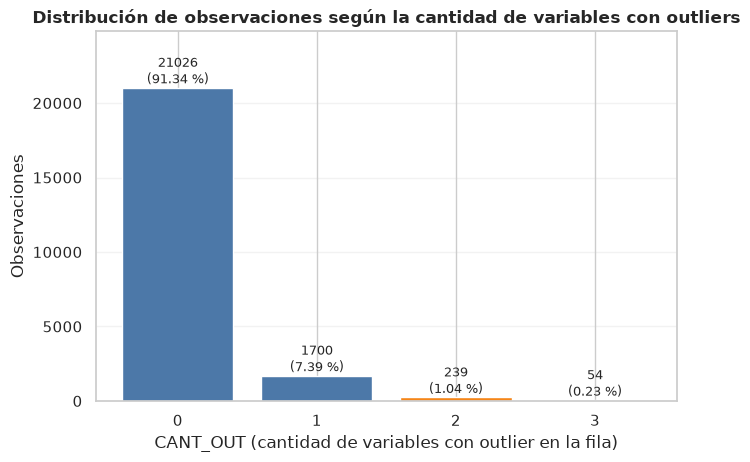

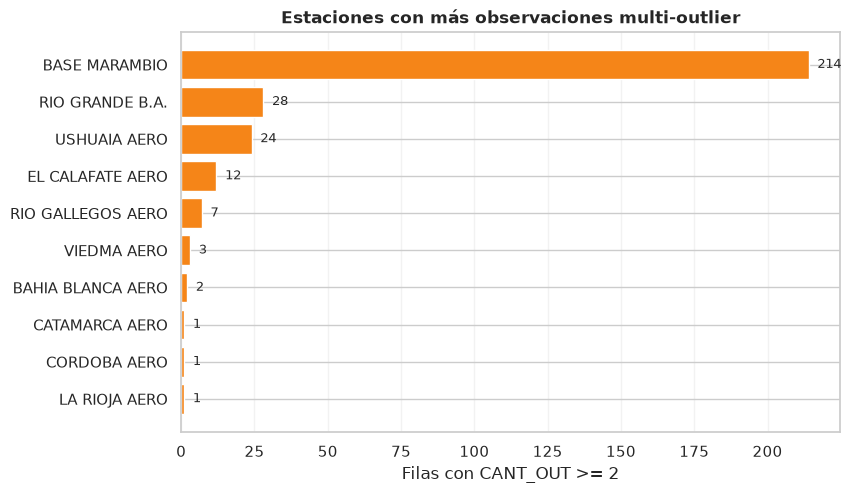

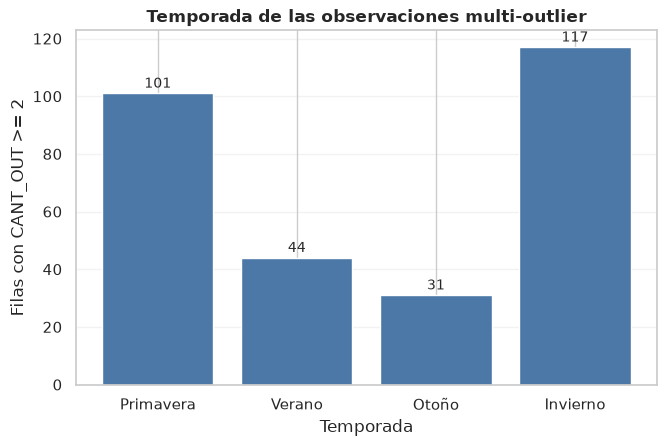

In [20]:
# Gráfico 1: distribución de la cantidad de outliers por observación
fig, ax = plt.subplots(figsize=(7.5, 4.8))
colores = [
    COLOR_ORIGINAL if k < 2 else COLOR_SUAVIZADA
    for k in conteo_cant_out.index
]
barras = ax.bar(
    conteo_cant_out.index.astype(str),
    conteo_cant_out.values,
    color=colores,
    edgecolor="white",
)
for barra, k in zip(barras, conteo_cant_out.index):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 300,
        f"{int(barra.get_height())}\n({100 * barra.get_height() / len(clima):.2f} %)",
        ha="center",
        fontsize=9,
    )
ax.set_xlabel("CANT_OUT (cantidad de variables con outlier en la fila)")
ax.set_ylabel("Observaciones")
ax.set_ylim(0, max(conteo_cant_out.values) * 1.18)
ax.set_title(
    "Distribución de observaciones según la cantidad de variables con outliers",
    fontsize=12,
    fontweight="bold",
)
ax.grid(axis="y", alpha=0.25)
plt.show()

# Gráfico 2: estaciones donde se ubican las filas multi-outlier
conteo_estaciones = filas_multi_outlier["estacion_meteorologica"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
top_estaciones = conteo_estaciones.iloc[::-1]
ax.barh(top_estaciones.index, top_estaciones.values, color=COLOR_SUAVIZADA, edgecolor="white")
for barra in ax.patches:
    ax.text(
        barra.get_width() + 3,
        barra.get_y() + barra.get_height() / 2,
        str(int(barra.get_width())),
        va="center",
        fontsize=9,
    )
ax.set_xlabel("Filas con CANT_OUT >= 2")
ax.set_title("Estaciones con más observaciones multi-outlier", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.25)
plt.show()

# Gráfico 3: temporada de las filas multi-outlier (orden cronológico de la muestra)
orden_temporadas = ["Primavera", "Verano", "Otoño", "Invierno"]
conteo_temporadas = filas_multi_outlier["temporada"].value_counts().reindex(orden_temporadas)

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.bar(conteo_temporadas.index, conteo_temporadas.values, color=COLOR_ORIGINAL, edgecolor="white")
for barra in ax.patches:
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 2,
        str(int(barra.get_height())),
        ha="center",
        fontsize=10,
    )
ax.set_xlabel("Temporada")
ax.set_ylabel("Filas con CANT_OUT >= 2")
ax.set_title("Temporada de las observaciones multi-outlier", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
plt.show()


### Conclusiones del punto 2.d

Las observaciones con outliers en más de una variable **no están repartidas al azar**: se concentran en el extremo sur del país y en la Antártida. De las 293 filas con `CANT_OUT >= 2`, **214 (≈ 73 %) pertenecen a BASE MARAMBIO**, la estación antártica del dataset, y el resto se reparte con mucha menor frecuencia entre estaciones de la Patagonia y Tierra del Fuego (Río Grande, Ushuaia, El Calafate, Río Gallegos) y algunos casos aislados más al norte. Por temporada predominan el **invierno** (117 filas) y la **primavera** (101), y la distribución por hora es pareja (entre 8 y 15 casos por hora, sin un horario predominante).

Si se miran las combinaciones de variables, el cuadro es físicamente coherente: en las filas multi-outlier los extremos son casi siempre **temperatura muy baja** (149 de 151 casos), **presión muy baja** (245 de 258) y **viento muy fuerte** (208 de 208). Aire frío, presión baja y viento intenso son condiciones típicas de tormentas y del clima antártico, por lo que estas observaciones parecen reflejar **condiciones meteorológicas reales** y no errores de medición.

Hay que interpretar el resultado con cuidado. El criterio IQR de 2.a se calculó sobre el conjunto de las 40 estaciones, y Marambio queda sistemáticamente fuera del “centro” de esa distribución nacional porque su clima es mucho más extremo que el del resto del país. Que un valor sea outlier respecto del dataset completo **no implica que sea un error**: para decidirlo haría falta comparar cada estación con su propia distribución o cruzar con registros meteorológicos. La concentración en una estación, en invierno y primavera y sin patrón horario es una señal de que se trata de fenómenos reales, pero confirmarlo excede lo que muestran estos datos.

El caso de `dir_viento` (990°) refuerza la utilidad de `CANT_OUT`: esos registros aparecen en 30 estaciones distintas y en todos los meses, y en ≈ 96 % de los casos son la única variable marcada de su fila. Se comporta como un problema de calidad de esa columna, aislado de las condiciones extremas simultáneas que sí se observan en las estaciones del sur.


### 3. Discretización de la humedad

**Discretizar** es transformar un atributo numérico continuo en uno discreto o categórico, agrupando sus valores en un conjunto finito de rangos. La humedad relativa se mide como porcentaje (de 6 % a 100 % en este dataset), pero conviene tratarla como categorías cuando se quiere, por ejemplo, resumirla, comparar grupos (“humedad baja” vs. “humedad alta”) o alimentar modelos que trabajan mejor con variables categóricas.

La consigna pide definir **5 rangos** con tres criterios distintos y luego compararlos:

- **3.a** rangos elegidos según el **análisis de frecuencia** de los valores (este punto);
- **3.b** rangos por **intervalos de clase**;
- **3.c** rangos por **percentiles cada 20 %**.

Solo 5 de las 23019 observaciones tienen `humedad` faltante: se las deja afuera del análisis (aportan el 0,02 % de los datos).


### 3.a Cinco rangos según el análisis de frecuencias

El primer criterio es el más “artesanal”: en lugar de aplicar una fórmula, se mira cómo se distribuyen los valores y se eligen los límites a partir de esa información. Para eso se construye una **tabla de frecuencias** con rangos de 10 puntos y su **frecuencia acumulada**.

La tabla muestra que la humedad no tiene “grupos naturales” marcados (no hay valles donde la frecuencia baje mucho): los valores son cada vez más frecuentes a medida que la humedad aumenta. Sin un criterio adicional, cualquier división en 5 rangos sería arbitraria. El criterio que se adopta acá es el de **repartir los casos de forma pareja**: cortar en los puntos donde la frecuencia acumulada llega aproximadamente a 20 %, 40 %, 60 % y 80 % de las observaciones. Así cada rango agrupa una cantidad parecida de mediciones y ninguno queda casi vacío.


,Frecuencia,%,% acumulado
humedad,,,
"[0, 10)",7,0.03,0.03
"[10, 20)",248,1.08,1.11
"[20, 30)",783,3.40,4.51
"[30, 40)",1498,6.51,11.02
"[40, 50)",2393,10.40,21.42
"[50, 60)",2720,11.82,33.24
"[60, 70)",3091,13.43,46.67
"[70, 80)",3483,15.13,61.80
"[80, 90)",4081,17.73,79.53


,Rango,Frecuencia,%
0,"(5.999, 48.0]",4684,20.35
1,"(48.0, 65.0]",4755,20.66
2,"(65.0, 78.0]",4413,19.18
3,"(78.0, 90.0]",4938,21.46
4,"(90.0, 100.0]",4224,18.35


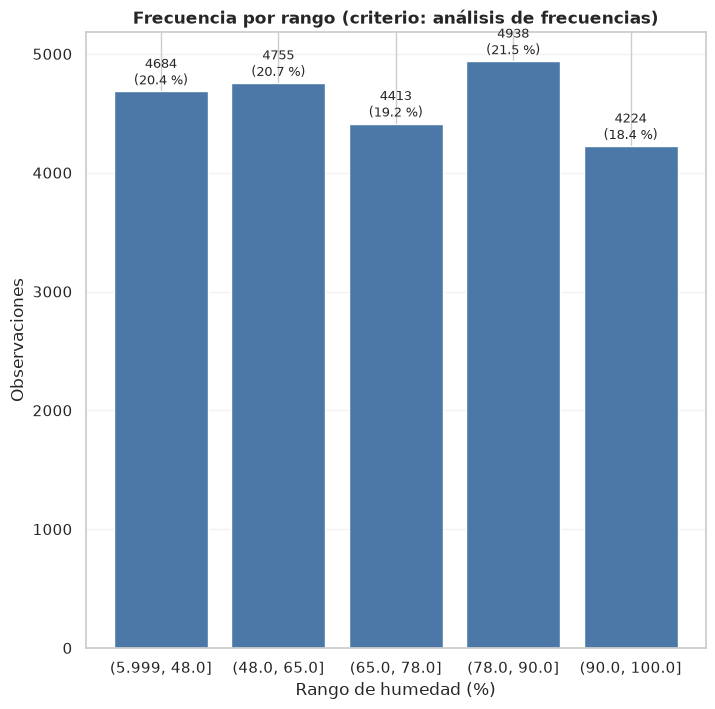

In [21]:
# Humedad sin los 5 valores faltantes
humedad = clima["humedad"].dropna()
n_humedad = len(humedad)

# --- Paso 1: análisis de frecuencia (rangos de 10 puntos) ---
frecuencia_10 = pd.cut(humedad, bins=np.arange(0, 101, 10), right=False)
tabla_frecuencias = frecuencia_10.value_counts().sort_index()
tabla_frecuencias = pd.DataFrame({"Frecuencia": tabla_frecuencias})
tabla_frecuencias["%"] = 100 * tabla_frecuencias["Frecuencia"] / n_humedad
tabla_frecuencias["% acumulado"] = tabla_frecuencias["%"].cumsum()
display(tabla_frecuencias.round(2))

# --- Paso 2: se eligen 5 rangos con frecuencia pareja (~20 % por rango) ---
# Cortes donde la frecuencia acumulada pasa por 20, 40, 60 y 80 %: 48, 65, 78 y 90
limites = [6, 48, 65, 78, 90, 100]
humedad_rangos = pd.cut(humedad, bins=limites, right=True, include_lowest=True)

# Se guarda la discretización en el dataset (los 5 faltantes quedan como NaN)
clima["humedad_rangos_a"] = pd.cut(clima["humedad"], bins=limites,
                                    right=True, include_lowest=True)

conteo_rangos = humedad_rangos.value_counts().sort_index()
tabla_rangos = pd.DataFrame({
    "Rango": [str(r) for r in conteo_rangos.index],
    "Frecuencia": conteo_rangos.values,
    "%": 100 * conteo_rangos.values / n_humedad,
})
display(tabla_rangos.round(2))

# --- Gráfico de frecuencias de los 5 rangos ---
fig, ax = plt.subplots(figsize=(8, 8))
barras = ax.bar([str(r) for r in conteo_rangos.index], conteo_rangos.values,
                color=COLOR_ORIGINAL, edgecolor="white")
for barra, val in zip(barras, conteo_rangos.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 60,
            f"{val}\n({100 * val / n_humedad:.1f} %)", ha="center", fontsize=9)
ax.set_xlabel("Rango de humedad (%)")
ax.set_ylabel("Observaciones")
ax.set_title("Frecuencia por rango (criterio: análisis de frecuencias)",
             fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
plt.show()


Con esta discretización cada medición queda en uno de cinco rangos. La frecuencia por rango quedó **pareja**: entre 4224 y 4938 observaciones por rango (≈ 18 % a 21 %), porque los cortes se eligieron sobre la frecuencia acumulada.

**¿Qué tipo de variable se obtiene?** La columna `humedad_rangos_a` es una **variable categórica ordinal**: tiene un conjunto finito de categorías (los 5 rangos) y entre ellas existe un **orden natural** (de menor a mayor humedad). No es numérica en el sentido de que las operaciones aritméticas (sumar, promediar) ya no tienen sentido sobre los rótulos; lo que sí se puede hacer es comparar y ordenar. Eso es lo que la distingue de una categórica nominal como `estacion_meteorologica`, donde no hay jerarquía entre las categorías.

El criterio usado (repartir los casos por igual) es el mismo que aplican los percentiles: en 3.c se va a poder comprobar que la división por percentiles de 20 % produce exactamente estos mismos cortes (48, 65, 78 y 90). La diferencia está en cómo se llega a ellos: acá se eligieron leyendo la tabla de frecuencias; allí los calcula la función directamente.


### 3.b Cinco rangos por intervalos de clase

El segundo criterio es el estándar de las tablas de frecuencias: dividir el **recorrido** de la variable (de su mínimo a su máximo) en 5 **intervalos de clase de igual amplitud**. Como la humedad va de 6 % a 100 %, la amplitud de cada intervalo es:

$$\text{amplitud} = \frac{100 - 6}{5} = 18{,}8 \text{ puntos porcentuales}$$

y los límites quedan en 6, 24,8, 43,6, 62,4, 81,2 y 100. Este criterio es puramente geométrico: divide el recorrido de la variable sin mirar cuántos datos hay en cada tramo, a diferencia de 3.a, donde los cortes se eligieron según la frecuencia observada.


Amplitud de cada intervalo: 18.8 puntos
Límites de los intervalos: [6.0, 24.8, 43.6, 62.4, 81.2, 100.0]


,Rango,Frecuencia,%
0,"(5.999, 24.8]",560,2.43
1,"(24.8, 43.6]",2859,12.42
2,"(43.6, 62.4]",5081,22.08
3,"(62.4, 81.2]",6430,27.94
4,"(81.2, 100.0]",8084,35.13


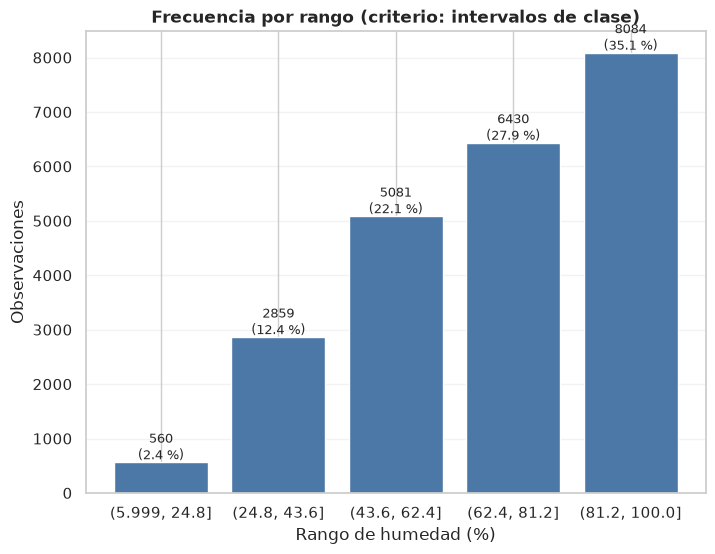

In [22]:
# Intervalos de clase: 5 rangos de igual amplitud sobre el recorrido de la humedad
ancho_intervalo = (humedad.max() - humedad.min()) / 5
limites_b = [humedad.min() + i * ancho_intervalo for i in range(5)] + [humedad.max()]
print(f"Amplitud de cada intervalo: {ancho_intervalo:.1f} puntos")
print("Límites de los intervalos:", [round(float(l), 1) for l in limites_b])

humedad_rangos_b = pd.cut(humedad, bins=limites_b, right=True, include_lowest=True)

# Se guarda la discretización en el dataset (los 5 faltantes quedan como NaN)
clima["humedad_rangos_b"] = pd.cut(clima["humedad"], bins=limites_b,
                                    right=True, include_lowest=True)

conteo_rangos_b = humedad_rangos_b.value_counts().sort_index()
tabla_rangos_b = pd.DataFrame({
    "Rango": [str(r) for r in conteo_rangos_b.index],
    "Frecuencia": conteo_rangos_b.values,
    "%": 100 * conteo_rangos_b.values / n_humedad,
})
display(tabla_rangos_b.round(2))

# Gráfico de frecuencias de los 5 rangos
fig, ax = plt.subplots(figsize=(8, 6))
barras = ax.bar([str(r) for r in conteo_rangos_b.index], conteo_rangos_b.values,
                color=COLOR_ORIGINAL, edgecolor="white")
for barra, val in zip(barras, conteo_rangos_b.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 60,
            f"{val}\n({100 * val / n_humedad:.1f} %)", ha="center", fontsize=9)
ax.set_xlabel("Rango de humedad (%)")
ax.set_ylabel("Observaciones")
ax.set_title("Frecuencia por rango (criterio: intervalos de clase)",
             fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
plt.show()


Los intervalos tienen todos la misma amplitud (18,8 puntos), pero las frecuencias quedaron **muy desparejas**: el primer rango concentra solo 560 observaciones (2,43 %), mientras que el último agrupa 8084 (35,13 %). La causa es que la distribución de la humedad no es pareja: hay pocas mediciones bajas y muchas altas, y este criterio divide el *recorrido* de los valores sin tener en cuenta cuántos datos hay en cada tramo.

Como en 3.a, la variable resultante `humedad_rangos_b` es **categórica ordinal**: rangos ordenados de menor a mayor humedad. La diferencia entre los dos criterios no está en el tipo de variable, sino en el **balance de los rangos**: los cortes de 3.a se adaptaron a la frecuencia de los datos y por eso cada rango quedó con ≈ 20 % de los casos; los intervalos de clase fijos dejan rangos casi vacíos y otros con más de un tercio de las observaciones. Esta comparación se retoma formalmente en 3.d.


### 3.c Cinco rangos por percentiles (cada 20 %)

El tercer criterio formaliza lo que en 3.a se hizo “a mano”: dividir los datos **ordenados** en 5 partes con la misma cantidad de observaciones. Para eso se usan los **percentiles**: el percentil 20 deja el 20 % de los datos por debajo, el percentil 40 deja el 40 %, y así sucesivamente. Los cortes de los 5 rangos son entonces los percentiles 20, 40, 60 y 80, es decir:

- **Rango 1:** del percentil 0 al 20 (las observaciones más bajas),
- **Rango 2:** del percentil 20 al 40,
- **Rango 3:** del percentil 40 al 60,
- **Rango 4:** del percentil 60 al 80,
- **Rango 5:** del percentil 80 al 100 (las observaciones más altas).

En pandas esto se resuelve con `pd.qcut`, que calcula los cuantiles pedidos y corta los datos en esos puntos. Con `q=5` cada rango recibe, idealmente, el 20 % de las observaciones.


Percentiles de la humedad (P20, P40, P60, P80):
0.2    48.0
0.4    65.0
0.6    78.0
0.8    90.0


,Rango,Frecuencia,%
0,"(5.999, 48.0]",4684,20.35
1,"(48.0, 65.0]",4755,20.66
2,"(65.0, 78.0]",4413,19.18
3,"(78.0, 90.0]",4938,21.46
4,"(90.0, 100.0]",4224,18.35


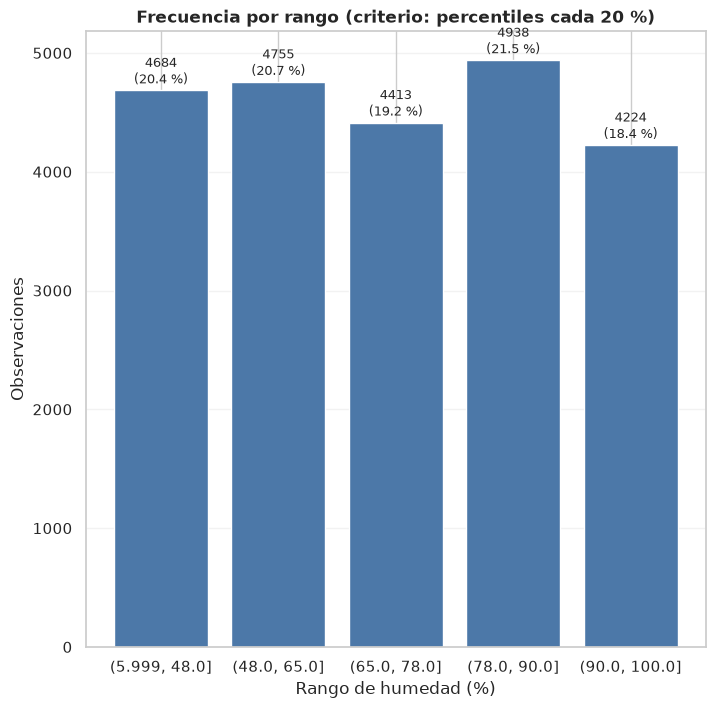

In [23]:
# Percentiles 20, 40, 60 y 80 de la humedad
percentiles_humedad = humedad.quantile([0.2, 0.4, 0.6, 0.8])
print("Percentiles de la humedad (P20, P40, P60, P80):")
print(percentiles_humedad.round(1).to_string())

# Discretización por percentiles: 5 rangos con ~20 % de los casos cada uno
humedad_rangos_c = pd.qcut(humedad, q=5, duplicates="drop")

# Se guarda la discretización en el dataset (los 5 faltantes quedan como NaN)
clima["humedad_rangos_c"] = pd.qcut(clima["humedad"], q=5, duplicates="drop")

conteo_rangos_c = humedad_rangos_c.value_counts().sort_index()
tabla_rangos_c = pd.DataFrame({
    "Rango": [str(r) for r in conteo_rangos_c.index],
    "Frecuencia": conteo_rangos_c.values,
    "%": 100 * conteo_rangos_c.values / n_humedad,
})
display(tabla_rangos_c.round(2))

# Gráfico de frecuencias de los 5 rangos
fig, ax = plt.subplots(figsize=(8, 8))
barras = ax.bar([str(r) for r in conteo_rangos_c.index], conteo_rangos_c.values,
                color=COLOR_ORIGINAL, edgecolor="white")
for barra, val in zip(barras, conteo_rangos_c.values):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height() + 60,
            f"{val}\n({100 * val / n_humedad:.1f} %)", ha="center", fontsize=9)
ax.set_xlabel("Rango de humedad (%)")
ax.set_ylabel("Observaciones")
ax.set_title("Frecuencia por rango (criterio: percentiles cada 20 %)",
             fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.25)
plt.show()


Los percentiles 20, 40, 60 y 80 de la humedad son **48, 65, 78 y 90**: exactamente los límites que se habían elegido a mano en 3.a leyendo la tabla de frecuencias. Por eso las frecuencias por rango también coinciden (4684, 4755, 4413, 4938 y 4224 observaciones).

Cada rango queda con **≈ 18 % a 21 %** de los casos, cerca del 20 % ideal pero no exactamente: la humedad toma valores enteros muy repetidos (por ejemplo, muchas mediciones en 90 o 95) y un corte no puede dividir las observaciones que comparten el mismo valor. Aun así, el criterio de percentiles logra lo que se proponía: que ningún rango quede casi vacío ni acumule un tercio de los datos, como sí pasaba con los intervalos de clase de 3.b.

La variable `humedad_rangos_c` vuelve a ser, como en 3.a y 3.b, **categórica ordinal**: 5 categorías ordenadas de menor a mayor humedad. La conclusión importante de 3.c es de método: cuando en 3.a se definieron los rangos según la frecuencia acumulada, se estaba aplicando (a mano) el mismo criterio que los percentiles aplican con una función; el resultado es idéntico.


### 3.d Comparación de los tres criterios

Este punto reúne los resultados de 3.a, 3.b y 3.c para analizarlos en conjunto. Como cada técnica define sus propios límites, los rangos de un método no son los rangos de otro: lo que se puede comparar es (1) **en qué puntos corta** cada técnica y (2) **cómo quedan repartidas las frecuencias** (el balanceo). Para eso se arma una tabla única con la frecuencia y el porcentaje de cada rango (del 1, humedad más baja, al 5, humedad más alta) según cada método, y un gráfico de frecuencia de los tres criterios lado a lado sobre la misma escala. La línea punteada roja marca el 20 %: el reparto que lograría un criterio perfectamente balanceado (5 rangos con el mismo número de casos).


,Frec. 3.a (frecuencias),% 3.a,Frec. 3.b (intervalos),% 3.b,Frec. 3.c (percentiles),% 3.c
Rango 1 (menor a mayor humedad),4684,20.35,560,2.43,4684,20.35
Rango 2 (menor a mayor humedad),4755,20.66,2859,12.42,4755,20.66
Rango 3 (menor a mayor humedad),4413,19.18,5081,22.08,4413,19.18
Rango 4 (menor a mayor humedad),4938,21.46,6430,27.94,4938,21.46
Rango 5 (menor a mayor humedad),4224,18.35,8084,35.13,4224,18.35


Cortes 3.a (frecuencias): [6, 48, 65, 78, 90, 100]
Cortes 3.c (percentiles): [48, 65, 78, 90]
Cortes 3.b (intervalos):  [6.0, 24.8, 43.6, 62.4, 81.2, 100.0]
Mismo rango ordinal en 3.a y 3.c: 100.0 % de las observaciones
Mismo rango ordinal en 3.a y 3.b: 25.5 % de las observaciones


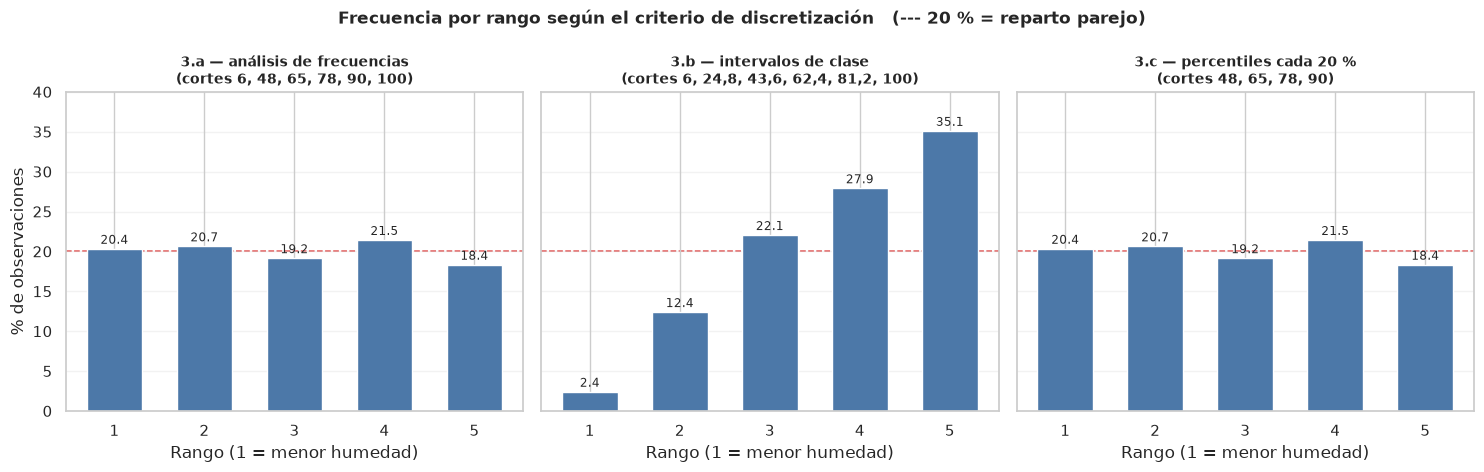

In [24]:
# --- Tabla comparativa: frecuencia y porcentaje por rango en cada método ---
tabla_3d = pd.DataFrame({
    "Frec. 3.a (frecuencias)": conteo_rangos.values,
    "% 3.a": 100 * conteo_rangos.values / n_humedad,
    "Frec. 3.b (intervalos)": conteo_rangos_b.values,
    "% 3.b": 100 * conteo_rangos_b.values / n_humedad,
    "Frec. 3.c (percentiles)": conteo_rangos_c.values,
    "% 3.c": 100 * conteo_rangos_c.values / n_humedad,
}, index=[f"Rango {i} (menor a mayor humedad)" for i in range(1, 6)])
display(tabla_3d.round(2))

# --- Cortes que usa cada método ---
print("Cortes 3.a (frecuencias):", limites)
print("Cortes 3.c (percentiles):", percentiles_humedad.round(0).astype(int).tolist())
print("Cortes 3.b (intervalos): ", [round(float(l), 1) for l in limites_b])

# --- Consistencia entre métodos: ¿la misma observación cae en el mismo rango? ---
# Se comparan los códigos ordinales (0 a 4) de cada categoría ordenada.
coincidencia_ac = float((humedad_rangos.cat.codes == humedad_rangos_c.cat.codes).mean())
coincidencia_ab = float((humedad_rangos.cat.codes == humedad_rangos_b.cat.codes).mean())
print(f"Mismo rango ordinal en 3.a y 3.c: {coincidencia_ac * 100:.1f} % de las observaciones")
print(f"Mismo rango ordinal en 3.a y 3.b: {coincidencia_ab * 100:.1f} % de las observaciones")

# --- Gráfico comparativo de frecuencias (misma escala de % en los tres paneles) ---
series = [
    ("3.a — análisis de frecuencias\n(cortes 6, 48, 65, 78, 90, 100)", conteo_rangos.values),
    ("3.b — intervalos de clase\n(cortes 6, 24,8, 43,6, 62,4, 81,2, 100)", conteo_rangos_b.values),
    ("3.c — percentiles cada 20 %\n(cortes 48, 65, 78, 90)", conteo_rangos_c.values),
]
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
posiciones = np.arange(1, 6)
for ax, (titulo, valores) in zip(ejes, series):
    pct = 100 * valores / n_humedad
    barras = ax.bar(posiciones, pct, width=0.62, color=COLOR_ORIGINAL, edgecolor="white")
    for barra, p in zip(barras, pct):
        ax.text(barra.get_x() + barra.get_width() / 2, p + 0.6,
                f"{p:.1f}", ha="center", fontsize=8.5)
    ax.axhline(20, color="#E45756", linestyle="--", linewidth=1.1, zorder=0)
    ax.set_xticks(posiciones)
    ax.set_xlabel("Rango (1 = menor humedad)")
    ax.set_ylim(0, 40)
    ax.set_title(titulo, fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.25)
ejes[0].set_ylabel("% de observaciones")
fig.suptitle("Frecuencia por rango según el criterio de discretización"
             "   (--- 20 % = reparto parejo)", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


**Balanceo.** La tabla y el gráfico muestran dos comportamientos claramente distintos. Con **3.a y 3.c** cada rango concentra entre el **18,35 % y el 21,46 %** de las observaciones: el reparto es parejo y queda cerca del 20 % teórico (la mayor desviación es de unos 3 puntos, porque los cortes caen sobre valores enteros muy repetidos). En cambio, con **3.b** las frecuencias quedan **muy desparejas**: el primer intervalo tiene el 2,43 % y el último el 35,13 %, con una diferencia de casi 33 puntos entre ambos extremos.

La causa es la forma de la distribución de la humedad: es una variable **sesgada**, con muchas más mediciones altas que bajas. Los intervalos de clase dividen el recorrido (6 a 100) en tramos de igual amplitud sin mirar cuántos datos caen en cada tramo, por lo que los rangos bajos quedan casi vacíos y los altos sobrecargados. Los criterios de 3.a y 3.c, en cambio, fijan los cortes donde la frecuencia acumulada pasa por el 20 %, 40 %, 60 % y 80 %, adaptándose a la distribución.

**Consistencia.** 3.a y 3.c son el mismo criterio aplicado de dos maneras: los percentiles son la formalización de “cortar donde la frecuencia acumulada llega a 20/40/60/80 %”. Por eso sus cortes coinciden (48, 65, 78 y 90) y el **100 %** de las observaciones queda asignado al mismo rango: los dos abordajes son plenamente consistentes. 3.b **no es consistente** con ellos: usa otro criterio (igual amplitud sobre el recorrido), corta en otros puntos y clasifica distinto — por ejemplo, una humedad de 50 queda en el rango 2 según 3.a/3.c pero en el rango 3 según 3.b, y una de 90 en el rango 4 según 3.a/3.c pero en el rango 5 según 3.b. Solo el **25,5 %** de las mediciones cae en la misma posición ordinal con ambos criterios.

Las tres discretizaciones son válidas como transformación, pero no son intercambiables: la elección depende del objetivo. Si se quiere **balancear las categorías** (por ejemplo, para alimentar un modelo de clasificación sin que una clase domine, o para comparar grupos con la misma cantidad de casos), conviene un criterio de frecuencia como 3.a/3.c. Si se quieren rangos **interpretables sobre la escala original** (“cada 18,8 puntos de humedad”), sirven los intervalos de clase de 3.b, asumiendo que quedarán categorías desbalanceadas por la forma de la distribución.


### 4. Normalización de temperatura y vel_viento

**Normalizar** es transformar un atributo numérico para llevarlo a una escala común, sin unidades, de modo que sus valores sean comparables con los de otros atributos o utilizables por métodos que asumen escalas homogéneas (distancias, modelos, gráficos conjuntos). En este dataset los dos atributos elegidos no son comparables tal como están: `temperatura` se mide en °C y toma valores negativos (de −26 a 42,6), mientras que `vel_viento` se mide en km/h (de 0 a 100).

La consigna pide aplicar tres técnicas de normalización sobre ambos atributos — **mínimo-máximo** (4.a), **z-score** (4.b) y **escalado decimal** (4.c) — y luego comparar los resultados (4.d y 4.e). En cada caso se guarda el resultado en una columna nueva (`temperatura_*` y `vel_viento_*`), conservando las columnas originales para poder comparar.

**Datos faltantes:** `temperatura` no tiene valores faltantes y `vel_viento` tiene 2. La normalización se calcula con los valores presentes y los faltantes se conservan como `NaN`, igual que se hizo con la humedad en el punto 3.


**Entrada en calor (papel y lápiz).** Dado el dominio $E = \{1, 5, 9, 17, 18, 34, 45, 89, 99\}$, se pide normalizar el valor 65 con dos técnicas:

- **Escalado decimal:** $v' = v / 10^j$, con $j$ el menor entero tal que el valor más grande del dominio quede menor que 1 en valor absoluto. Como $\max(E) = 99$: $99 / 10 = 9{,}9 \geq 1$ y $99 / 10^2 = 0{,}99 < 1$, entonces $j = 2$ y el valor normalizado es $65 / 100 = 0{,}65$.

- **Mínimo-máximo:** $v' = (v - \min) / (\max - \min)$. Con $\min(E) = 1$ y $\max(E) = 99$: $(65 - 1) / (99 - 1) = 64 / 98 \approx 0{,}6531$.

Ambos resultados son cercanos (0,65 vs. 0,6531), pero no por la misma razón: el escalado decimal solo corre la coma según la magnitud del valor más grande del dominio, mientras que el mínimo-máximo usa el **recorrido completo** y garantiza que el mínimo quede en 0 y el máximo en 1.


### 4.a Normalización mínimo-máximo

La técnica de **mínimo-máximo** re-escala los valores con una transformación lineal:

$$v' = \frac{v - \min_A}{\max_A - \min_A}$$

donde $\min_A$ y $\max_A$ son el valor mínimo y máximo observados del atributo. El resultado queda siempre en el intervalo **[0, 1]**: el valor más bajo del dataset se convierte en 0, el más alto en 1 y el resto queda repartido proporcionalmente entre ambos.

Por ser lineal, la técnica **preserva el orden** entre las observaciones y la **forma de la distribución**: solo cambia la escala del eje. Su limitación clásica es que depende de los valores extremos: si el dataset tiene observaciones atípicas, el recorrido se estira hasta ellas y el resto de los datos queda comprimido en una franja angosta del [0, 1]. Se aplica por separado a `temperatura` y a `vel_viento`, cada una con su propio mínimo y máximo.


In [25]:
# --- 4.a Mínimo-máximo: v' = (v - mín) / (máx - mín)  ->  [0, 1] ---
min_temp, max_temp = clima["temperatura"].min(), clima["temperatura"].max()
min_vel, max_vel = clima["vel_viento"].min(), clima["vel_viento"].max()
print(f"Referencias temperatura (°C): mín = {min_temp} | máx = {max_temp}")
print(f"Referencias vel_viento (km/h): mín = {min_vel} | máx = {max_vel}")

clima["temperatura_minmax"] = (clima["temperatura"] - min_temp) / (max_temp - min_temp)
clima["vel_viento_minmax"] = (clima["vel_viento"] - min_vel) / (max_vel - min_vel)

# Verificación con describe(): el mínimo debe dar 0, el máximo 1 y deben
# conservarse los 2 faltantes de vel_viento (count = 23017).
display(clima[["temperatura_minmax", "vel_viento_minmax"]].describe().round(4))

# Muestra: valores originales y sus equivalentes normalizados.
# Se redondean solo las columnas numéricas (fecha es datetime y round() no aplica).
columnas_vista = ["fecha", "estacion_meteorologica", "temperatura", "temperatura_minmax",
                  "vel_viento", "vel_viento_minmax"]
muestra_4a = clima[columnas_vista].head(6).copy()
muestra_4a[muestra_4a.select_dtypes("number").columns] = \
    muestra_4a.select_dtypes("number").round(4)
display(muestra_4a)


Referencias temperatura (°C): mín = -26.0 | máx = 42.6
Referencias vel_viento (km/h): mín = 0.0 | máx = 100.0


,temperatura_minmax,vel_viento_minmax
count,23019.0000,23017.000
mean,0.6139,0.135
std,0.1306,0.100
min,0.0000,0.000
25%,0.5277,0.070
50%,0.6210,0.110
75%,0.7070,0.190
max,1.0000,1.000


,fecha,estacion_meteorologica,temperatura,temperatura_minmax,vel_viento,vel_viento_minmax
0,2025-09-10,AEROPARQUE AERO,15.6,0.6064,9.0,0.09
1,2025-09-10,AEROPARQUE AERO,15.3,0.6020,9.0,0.09
2,2025-09-10,AEROPARQUE AERO,15.1,0.5991,9.0,0.09
3,2025-09-10,AEROPARQUE AERO,14.8,0.5948,9.0,0.09
4,2025-09-10,AEROPARQUE AERO,15.0,0.5977,17.0,0.17
5,2025-09-10,AEROPARQUE AERO,14.2,0.5860,15.0,0.15


Como muestra el `describe()` de las columnas nuevas, ambas normalizaciones quedaron en **[0, 1]**: el mínimo es exactamente 0, el máximo exactamente 1 y la media quedó en 0,61 (temperatura) y 0,14 (viento). Los 2 valores faltantes de `vel_viento` se conservaron como `NaN` (count = 23017). Cada valor normalizado se puede leer como la **posición relativa dentro del recorrido observado**: los 16,6 °C de la mediana quedan en 0,62, y los 11 km/h de la mediana del viento en 0,11.

La comparación entre variables muestra el efecto de los extremos. El mínimo y el máximo que definen el recorrido son observaciones reales pero muy alejadas del grueso de los datos: −26 °C (BASE MARAMBIO, invierno antártico) y 42,6 °C (Santiago del Estero, verano) para la temperatura, y 100 km/h (BASE MARAMBIO) para el viento. En el punto 2 estos valores se marcaron como outliers por la regla del IQR, pero no son errores: son extremos climáticos genuinos de estaciones de contextos muy distintos. Al ser los anclas de la normalización, estiran el recorrido y el grueso de los datos queda comprimido en una franja angosta del [0, 1] — la mitad central de la temperatura ocupa de 0,53 a 0,71 y la del viento de 0,07 a 0,19. Esta sensibilidad a los extremos es la limitación clásica de la técnica y conviene tenerla presente al comparar los tres métodos en 4.d.


### 4.b Normalización z-score

La normalización por **z-score** (o estandarización) expresa cada valor como la cantidad de **desvíos estándar** que se aleja de la media del atributo:

$$z = \frac{v - \text{media}}{\text{desvío estándar}}$$

Ya se usó esta misma medida en el punto 2.c para describir qué tan alejados estaban los outliers: allí se calculó sobre los valores candidatos, y ahora se aplica sobre todo el atributo. El resultado queda **centrado en 0** (la media se convierte en 0) y con **desvío estándar 1**, sin unidad de medida. Un valor positivo está por encima de la media y uno negativo por debajo.

A diferencia del mínimo-máximo, el z-score **no tiene cotas fijas** (no queda limitado a [0, 1]) y no usa el mínimo y el máximo sino la media y el desvío, que resumen el centro y la dispersión típica de la distribución. Igual que en 4.a, se calcula por separado para `temperatura` y `vel_viento`, cada una con su propia media y desvío.


In [26]:
# --- 4.b Z-score: z = (v - media) / desvío estándar ---
# Se usa el desvío estándar muestral (ddof=1, el default de pandas), como en el punto 2.c.
media_temp, desvio_temp = clima["temperatura"].mean(), clima["temperatura"].std()
media_vel, desvio_vel = clima["vel_viento"].mean(), clima["vel_viento"].std()
print(f"temperatura: media = {media_temp:.3f} | desvío = {desvio_temp:.3f}")
print(f"vel_viento:  media = {media_vel:.3f} | desvío = {desvio_vel:.3f}")

clima["temperatura_zscore"] = (clima["temperatura"] - media_temp) / desvio_temp
clima["vel_viento_zscore"] = (clima["vel_viento"] - media_vel) / desvio_vel

# Verificación: media ~ 0 y desvío = 1 en las dos columnas nuevas; se conservan
# los 2 faltantes de vel_viento (count = 23017).
display(clima[["temperatura_zscore", "vel_viento_zscore"]].describe().round(4))

# Muestra: valores originales y sus equivalentes normalizados.
# Se redondean solo las columnas numéricas (fecha es datetime y round() no aplica).
columnas_vista = ["fecha", "estacion_meteorologica", "temperatura", "temperatura_zscore",
                  "vel_viento", "vel_viento_zscore"]
muestra_4b = clima[columnas_vista].head(6).copy()
muestra_4b[muestra_4b.select_dtypes("number").columns] = \
    muestra_4b.select_dtypes("number").round(4)
display(muestra_4b)


temperatura: media = 16.112 | desvío = 8.961
vel_viento:  media = 13.505 | desvío = 10.003


,temperatura_zscore,vel_viento_zscore
count,23019.0000,23017.0000
mean,-0.0000,0.0000
std,1.0000,1.0000
min,-4.6997,-1.3501
25%,-0.6597,-0.6503
50%,0.0545,-0.2504
75%,0.7130,0.5494
max,2.9561,8.6471


,fecha,estacion_meteorologica,temperatura,temperatura_zscore,vel_viento,vel_viento_zscore
0,2025-09-10,AEROPARQUE AERO,15.6,-0.0571,9.0,-0.4504
1,2025-09-10,AEROPARQUE AERO,15.3,-0.0906,9.0,-0.4504
2,2025-09-10,AEROPARQUE AERO,15.1,-0.1129,9.0,-0.4504
3,2025-09-10,AEROPARQUE AERO,14.8,-0.1464,9.0,-0.4504
4,2025-09-10,AEROPARQUE AERO,15.0,-0.1240,17.0,0.3494
5,2025-09-10,AEROPARQUE AERO,14.2,-0.2133,15.0,0.1495


El `describe()` confirma las propiedades esperadas: en las dos columnas nuevas la media es prácticamente 0 (quedan diferencias de redondeo de máquina) y el desvío estándar es 1. Los 2 faltantes de `vel_viento` se conservaron como `NaN` (count = 23017).

Cada valor normalizado se interpreta como la **distancia a la media medida en desvíos estándar**. La mediana de la temperatura (16,6 °C) queda en z = 0,055: prácticamente sobre la media de 16,1 °C. La mediana del viento (11 km/h) queda en z = −0,25: por debajo de la media de 13,5 km/h, porque la distribución del viento es asimétrica con cola a la derecha. Nótese que la mediana no cae en 0: el z-score centra en la **media**, no en el centro de los datos ordenados.

Al mirar los extremos se ve qué tan atípicos son en términos relativos a su propia variabilidad. La temperatura mínima de −26 °C (BASE MARAMBIO, invierno antártico) queda en **z = −4,70**, el valor más extremo de la temperatura; en cambio el máximo de 42,6 °C (Santiago del Estero, verano) queda en **z = 2,96**, a menos de tres desvíos de la media a pesar de ser el máximo. Para el viento ocurre lo contrario: los 100 km/h de Marambio quedan en **z = 8,65**, muy por encima del resto. Esto coincide con lo observado en 2.c: la temperatura mínima era el caso más alejado de su variable (−4,70) y la velocidad máxima era el más alejado de todo el dataset (8,65).

La diferencia central con el mínimo-máximo de 4.a: el z-score **no tiene cotas** y no depende de los valores mínimo y máximo. Por ejemplo, el viento en calma (0 km/h) queda en z = −1,35 (por debajo de la media), mientras que en 4.a ese mismo valor era el ancla y quedaba exactamente en 0. Ambas transformaciones son lineales y preservan el orden, pero reparten los datos en escalas distintas: el mínimo-máximo en [0, 1] y el z-score alrededor del 0 con desvío 1. Esa diferencia se comparará gráficamente en 4.d.


### 4.c Normalización por escalado decimal

La técnica de **escalado decimal** mueve la coma decimal de los valores: divide todo el atributo por una potencia de 10 elegida según la magnitud de sus valores:

$$v' = \frac{v}{10^j}$$

donde $j$ es el menor entero tal que el valor más grande del atributo (en valor absoluto) queda menor que 1. Es la misma regla que se aplicó “de papel y lápiz” en la entrada en calor: como $\max(E) = 99$, hizo falta $10^2 = 100 > 99$ y por eso 65 quedó en 0,65.

A diferencia del mínimo-máximo, el escalado decimal **no usa el mínimo** y **no centra los datos**: solo corre la coma según la magnitud de los valores. Por eso conserva el signo (una temperatura negativa sigue siendo negativa) y el resultado queda acotado entre −1 y 1 por construcción. El exponente $j$ depende de cada atributo y puede ser distinto entre variables, como se ve a continuación.


In [27]:
# --- 4.c Escalado decimal: v' = v / 10^j, con j tal que max|v| / 10^j < 1 ---
def j_escalado(serie):
    """Menor entero j tal que el mayor valor absoluto de la serie queda menor que 1."""
    maximo = serie.abs().max()
    j = 0
    while maximo / (10 ** j) >= 1:
        j += 1
    return j, maximo

j_temp, max_temp = j_escalado(clima["temperatura"])
j_vel, max_vel = j_escalado(clima["vel_viento"])
print(f"temperatura: max |valor| = {max_temp}  ->  j = {j_temp}  (dividir por 10^{j_temp})")
print(f"vel_viento:  max |valor| = {max_vel}  ->  j = {j_vel}  (dividir por 10^{j_vel})")

clima["temperatura_decimal"] = clima["temperatura"] / (10 ** j_temp)
clima["vel_viento_decimal"] = clima["vel_viento"] / (10 ** j_vel)

# Verificación: el mayor valor absoluto debe quedar menor que 1 y se conservan
# los 2 faltantes de vel_viento (count = 23017).
print(f"Máximo |valor| resultante: temperatura = {clima['temperatura_decimal'].abs().max():.4f} | "
      f"vel_viento = {clima['vel_viento_decimal'].abs().max():.4f}")
display(clima[["temperatura_decimal", "vel_viento_decimal"]].describe().round(4))

# Muestra: valores originales y sus equivalentes normalizados.
# Se redondean solo las columnas numéricas (fecha es datetime y round() no aplica).
columnas_vista = ["fecha", "estacion_meteorologica", "temperatura", "temperatura_decimal",
                  "vel_viento", "vel_viento_decimal"]
muestra_4c = clima[columnas_vista].head(6).copy()
muestra_4c[muestra_4c.select_dtypes("number").columns] = \
    muestra_4c.select_dtypes("number").round(4)
display(muestra_4c)


temperatura: max |valor| = 42.6  ->  j = 2  (dividir por 10^2)
vel_viento:  max |valor| = 100.0  ->  j = 3  (dividir por 10^3)
Máximo |valor| resultante: temperatura = 0.4260 | vel_viento = 0.1000


,temperatura_decimal,vel_viento_decimal
count,23019.0000,23017.0000
mean,0.1611,0.0135
std,0.0896,0.0100
min,-0.2600,0.0000
25%,0.1020,0.0070
50%,0.1660,0.0110
75%,0.2250,0.0190
max,0.4260,0.1000


,fecha,estacion_meteorologica,temperatura,temperatura_decimal,vel_viento,vel_viento_decimal
0,2025-09-10,AEROPARQUE AERO,15.6,0.156,9.0,0.009
1,2025-09-10,AEROPARQUE AERO,15.3,0.153,9.0,0.009
2,2025-09-10,AEROPARQUE AERO,15.1,0.151,9.0,0.009
3,2025-09-10,AEROPARQUE AERO,14.8,0.148,9.0,0.009
4,2025-09-10,AEROPARQUE AERO,15.0,0.150,17.0,0.017
5,2025-09-10,AEROPARQUE AERO,14.2,0.142,15.0,0.015


El exponente $j$ quedó distinto para cada variable. La temperatura tiene como valor más extremo 42,6 (en valor absoluto, el máximo de 42,6 °C supera al mínimo de −26 °C), así que alcanza con $j = 2$: $42{,}6 / 100 = 0{,}426 < 1$. La velocidad del viento, en cambio, tiene un máximo de **100 km/h exactos**, y ahí aparece el detalle de la regla estricta “menor que 1”: $100 / 100 = 1$ **no** es menor que 1, por lo que hace falta pasar a $j = 3$ y dividir por 1000. Es el mismo fenómeno de la entrada en calor, donde el máximo 99 alcanzaba con dividir por 100.

Los resultados quedan, por construcción, con valor absoluto menor que 1 (verificado en la salida: 0,426 y 0,1). La temperatura quedó en el rango **de −0,26 a 0,426** — el mínimo sigue siendo negativo, porque esta técnica no centra los datos: −26 °C pasó a −0,26 y 42,6 °C a 0,426 — mientras que la velocidad del viento quedó **de 0 a 0,1**: los 100 km/h del máximo pasaron a 0,1 y la mediana de 11 km/h a 0,011. Los 2 faltantes de `vel_viento` se conservaron (count = 23017).

Al ser una transformación lineal (dividir por una constante), conserva el orden y la forma de la distribución, igual que las dos técnicas anteriores. La diferencia está en la escala resultante: el mínimo-máximo reparte en [0, 1] usando el recorrido completo; el z-score centra en 0 con desvío 1; el escalado decimal simplemente corre la coma hasta que el valor más grande quede menor que 1, sin usar el mínimo ni la dispersión. Que cada técnica ubique los datos en una escala distinta se ve claramente al comparar las columnas lado a lado, que es lo que se hace en 4.d.


### 4.d Comparación de los resultados

Con las tres normalizaciones aplicadas se comparan los resultados de dos maneras complementarias:

1. **Tabla resumen** de los valores originales y de cada versión normalizada, para ver en qué escala quedó cada una (mínimo, máximo, media y desvío).
2. **Gráficos**: histogramas de la variable original y de cada atributo resultante, y diagramas de dispersión del valor original contra cada versión normalizada.

La clave para interpretar los gráficos es que las tres técnicas son **transformaciones lineales** ($v' = a \cdot v + b$, con pendiente $a > 0$): estiran y corren la escala, pero no alteran el orden entre observaciones ni la forma de la distribución. Si esto se cumple, los histogramas deben mostrar la **misma forma** con distinta escala en el eje horizontal, y los puntos de los diagramas de dispersión deben alinearse sobre una **recta**.


temperatura (°C)


,Observaciones,Mínimo,Mediana,Media,Máximo,Desvío
Original,23019.0,-26.0000,16.6000,16.1115,42.6000,8.9605
Mínimo-máximo,23019.0,0.0000,0.6210,0.6139,1.0000,0.1306
Z-score,23019.0,-4.6997,0.0545,-0.0000,2.9561,1.0000
Escalado decimal,23019.0,-0.2600,0.1660,0.1611,0.4260,0.0896


vel_viento (km/h)


,Observaciones,Mínimo,Mediana,Media,Máximo,Desvío
Original,23017.0,0.0000,11.0000,13.5048,100.0000,10.0028
Mínimo-máximo,23017.0,0.0000,0.1100,0.1350,1.0000,0.1000
Z-score,23017.0,-1.3501,-0.2504,0.0000,8.6471,1.0000
Escalado decimal,23017.0,0.0000,0.0110,0.0135,0.1000,0.0100


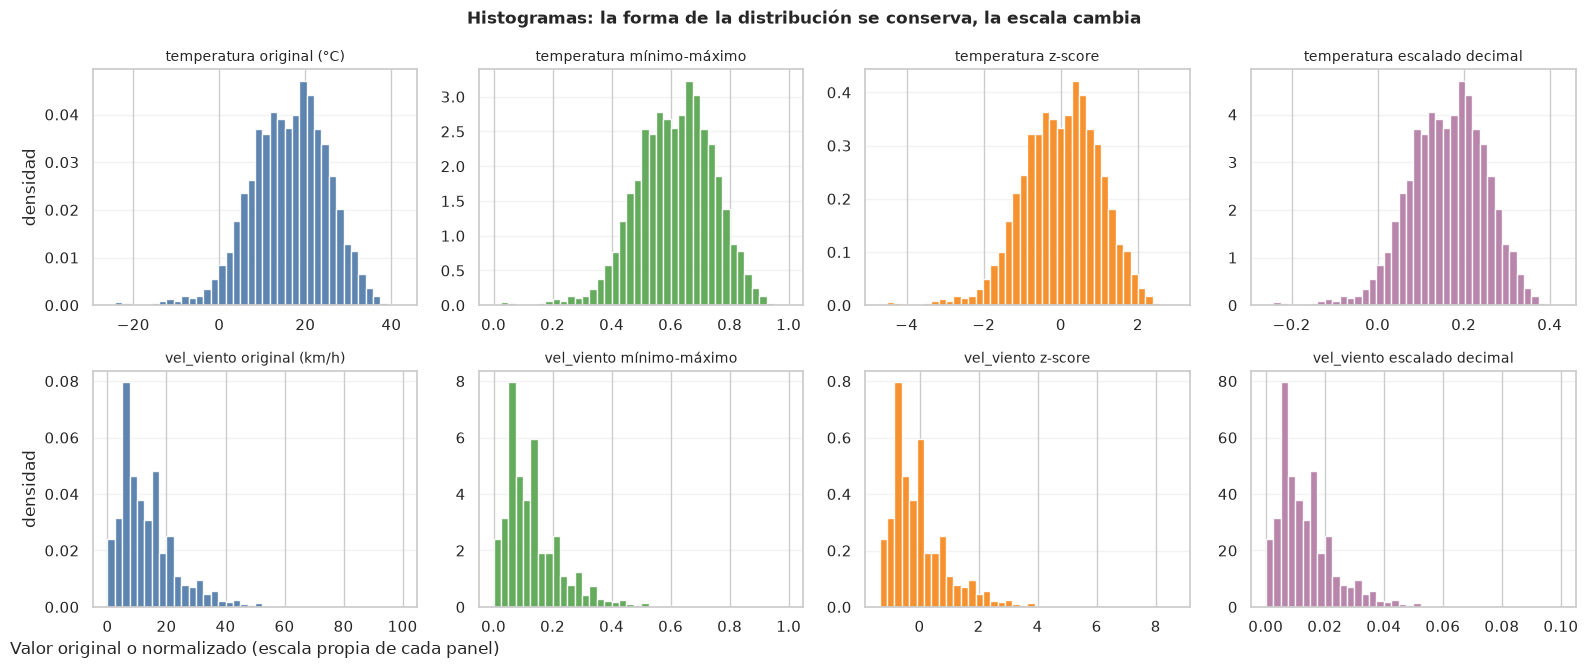

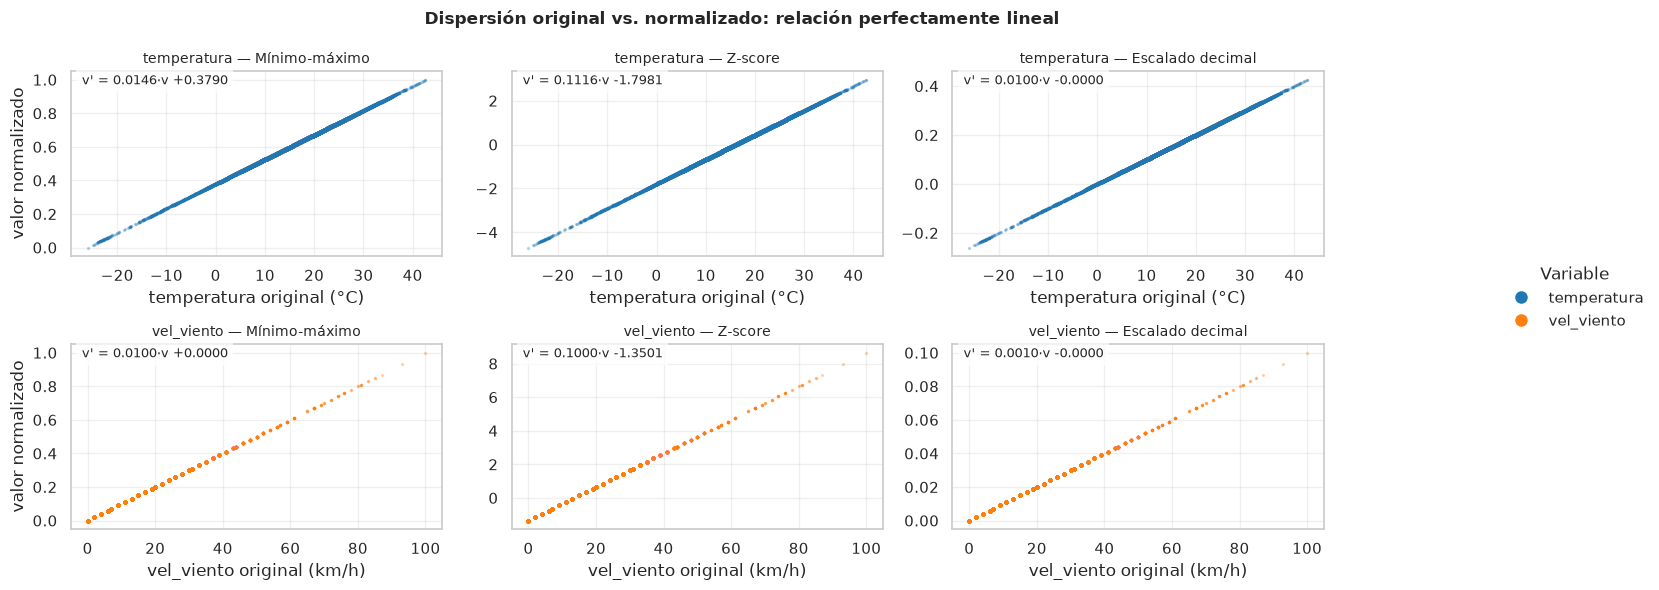

In [28]:
# --- 4.d Comparación: tabla resumen y gráficos ---
variables_orig = {"temperatura": "°C", "vel_viento": "km/h"}
tecnica_sufijo = {
    "Mínimo-máximo": "_minmax",
    "Z-score": "_zscore",
    "Escalado decimal": "_decimal",
}
colores_tecnica = {
    "Original": COLOR_ORIGINAL,
    "Mínimo-máximo": "#54A24B",
    "Z-score": "#F58518",
    "Escalado decimal": "#B279A2",
}

# --- 1. Tabla resumen por variable ---
for variable, unidad in variables_orig.items():
    versiones = {"Original": clima[variable]}
    for tecnica, sufijo in tecnica_sufijo.items():
        versiones[tecnica] = clima[variable + sufijo]

    filas = {}
    for nombre, serie in versiones.items():
        filas[nombre] = {
            "Observaciones": serie.count(),
            "Mínimo": serie.min(),
            "Mediana": serie.median(),
            "Media": serie.mean(),
            "Máximo": serie.max(),
            "Desvío": serie.std(),
        }
    resumen_4d = pd.DataFrame(filas).T
    print(f"{variable} ({unidad})")
    display(resumen_4d.round(4))

# --- 2a. Histogramas: original y cada resultado, variable por variable ---
nombres_tecnica = list(tecnica_sufijo)
fig, ejes = plt.subplots(2, 4, figsize=(16, 6.8))
for fila, (variable, unidad) in enumerate(variables_orig.items()):
    etiquetas = [f"{variable} original ({unidad})"] + \
                [f"{variable} {t.lower()}" for t in nombres_tecnica]
    series = [clima[variable]] + [clima[variable + tecnica_sufijo[t]] for t in nombres_tecnica]
    colores = [colores_tecnica["Original"]] + [colores_tecnica[t] for t in nombres_tecnica]

    for columna, (etiqueta, serie, color) in enumerate(zip(etiquetas, series, colores)):
        serie.dropna().hist(bins=40, density=True, ax=ejes[fila, columna],
                            color=color, edgecolor="white", alpha=0.9)
        ejes[fila, columna].set_title(etiqueta, fontsize=10)
        ejes[fila, columna].grid(axis="y", alpha=0.25)
    ejes[fila, 0].set_ylabel("densidad")
ejes[1, 0].set_xlabel("Valor original o normalizado (escala propia de cada panel)")
fig.suptitle("Histogramas: la forma de la distribución se conserva, la escala cambia",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

# --- 2b. Dispersión: valor original (x) contra cada versión normalizada (y) ---
color_variable = {"temperatura": "#1f77b4", "vel_viento": "#ff7f0e"}
fig, ejes = plt.subplots(2, 3, figsize=(15, 6))
for fila, (variable, unidad) in enumerate(variables_orig.items()):
    original = clima[variable]
    for columna, tecnica in enumerate(nombres_tecnica):
        normalizado = clima[variable + tecnica_sufijo[tecnica]]
        ejes[fila, columna].scatter(original, normalizado, s=2, alpha=0.25,
                                    color=color_variable[variable])
        # Pendiente y ordenada al origen de la recta v' = a*v + b
        a, b = np.polyfit(original.dropna(), normalizado.dropna(), 1)
        ejes[fila, columna].text(0.03, 0.93, f"v' = {a:.4f}·v {b:+.4f}",
                                transform=ejes[fila, columna].transAxes, fontsize=9,
                                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
        ejes[fila, columna].set_title(f"{variable} — {tecnica}", fontsize=10)
        ejes[fila, columna].grid(alpha=0.3)
        ejes[fila, columna].set_xlabel(f"{variable} original ({unidad})")
    ejes[fila, 0].set_ylabel("valor normalizado")
from matplotlib.lines import Line2D
leyenda = [Line2D([0], [0], marker="o", linestyle="None", color=color,
                  markersize=8, label=variable)
           for variable, color in color_variable.items()]
fig.legend(handles=leyenda, loc="center left", bbox_to_anchor=(1.0, 0.5),
           title="Variable", frameon=False)
fig.suptitle("Dispersión original vs. normalizado: relación perfectamente lineal",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()


La tabla resumen muestra en qué escala quedó cada versión. Para la temperatura, el original va de −26 °C a 42,6 °C; el mínimo-máximo lo lleva a **[0, 1]**; el z-score lo deja alrededor de 0 con desvío 1 (de −4,70 a 2,96); y el escalado decimal lo deja en [−0,26; 0,426]. Para el viento el original va de 0 a 100 km/h; el mínimo-máximo a [0, 1]; el z-score de −1,35 a 8,65; y el escalado decimal a [0; 0,1]. Las tres versiones de cada variable quedan **sin unidad de medida**, que era el objetivo: recién ahí los valores de `temperatura` y `vel_viento` se pueden comparar o combinar.

Los gráficos confirman que las tres técnicas son transformaciones **lineales**. En los histogramas, la forma de la distribución es la misma en los cuatro paneles de cada fila (por ejemplo, la cola larga hacia la derecha del viento se mantiene en todas las versiones): solo cambia la escala del eje horizontal. En los diagramas de dispersión, las observaciones se alinean sobre rectas perfectas, una por técnica, con pendiente y ordenada al origen distintas: el mínimo-máximo y el escalado decimal parten de 0 (las rectas pasan por valores cercanos a (0, 0), salvo la temperatura en el mínimo-máximo, cuyo 0 °C no es el mínimo del dataset), mientras que el z-score corre la escala para centrar en la media.

**Qué gana cada escala.** Las tres normalizaciones preservan el orden y las distancias relativas, así que ninguna agrega ni quita información; la diferencia es cómo se lee cada resultado. Con el mínimo-máximo, un valor dice qué tan cerca está del máximo observado dentro del recorrido [mínimo, máximo]; como ese recorrido queda definido por los extremos (en este caso, valores climáticos genuinos pero atípicos de Marambio y Santiago del Estero), la mayoría de los datos se concentra en una franja angosta. Con el z-score, un valor dice a cuántos desvíos está de la media de su propia variable, y por eso es la escala que mejor permite comparar “qué tan extremo es un valor dentro de su variable”: los 100 km/h quedan a 8,65 desvíos y los 42,6 °C a 2,96. Con el escalado decimal, un valor es simplemente el original con la coma corrida según la magnitud máxima, sin usar ni el mínimo ni la dispersión.

En el próximo punto se explota justamente la propiedad de comparabilidad: boxplots de las versiones original y normalizadas agrupados por `temporada`.


### 4.e Comparación con boxplots agrupados por temporada

Para cerrar el punto 4 se repite el análisis anterior, pero con **boxplots** y agrupando las observaciones por `temporada`. Cada boxplot resume una distribución con cinco elementos: la mediana (línea central), la caja entre Q1 y Q3 (el 50 % central de los datos), los bigotes (hasta 1,5·IQR) y los puntos que quedan fuera de ellos (valores atípicos), que ya se usaron en 2.b.

La muestra cubre un año completo (septiembre de 2025 a agosto de 2026) con ≈ 5.750 observaciones por temporada, así que quedan cuatro grupos grandes y balanceados para comparar.

La grilla es la misma de 4.d: las filas son las variables y las columnas las versiones (original y las tres normalizadas); dentro de cada panel hay un boxplot por temporada. Dos preguntas guía:

1. ¿El patrón estacional se conserva en las cuatro versiones? (debería ser así: las tres normalizaciones son lineales y no alteran el orden entre observaciones).
2. ¿Qué aporta mirar las versiones normalizadas en lugar de las originales? La respuesta esperable es la comparabilidad entre variables con unidades distintas (°C vs. km/h).


Temporadas presentes: ['Primavera', 'Verano', 'Otoño', 'Invierno']
Observaciones por temporada:
temporada
Primavera    5760
Verano       5757
Otoño        5748
Invierno     5754

Medianas de temperatura (°C) por temporada


,Original,Mínimo-máximo,Z-score,Escalado decimal
Primavera,18.50,0.6487,0.2666,0.1850
Verano,22.50,0.7070,0.7130,0.2250
Otoño,15.85,0.6101,-0.0292,0.1585
Invierno,10.00,0.5248,-0.6820,0.1000



Medianas de vel_viento (km/h) por temporada


,Original,Mínimo-máximo,Z-score,Escalado decimal
Primavera,15.0,0.15,0.1495,0.015
Verano,11.0,0.11,-0.2504,0.011
Otoño,9.0,0.09,-0.4504,0.009
Invierno,9.0,0.09,-0.4504,0.009


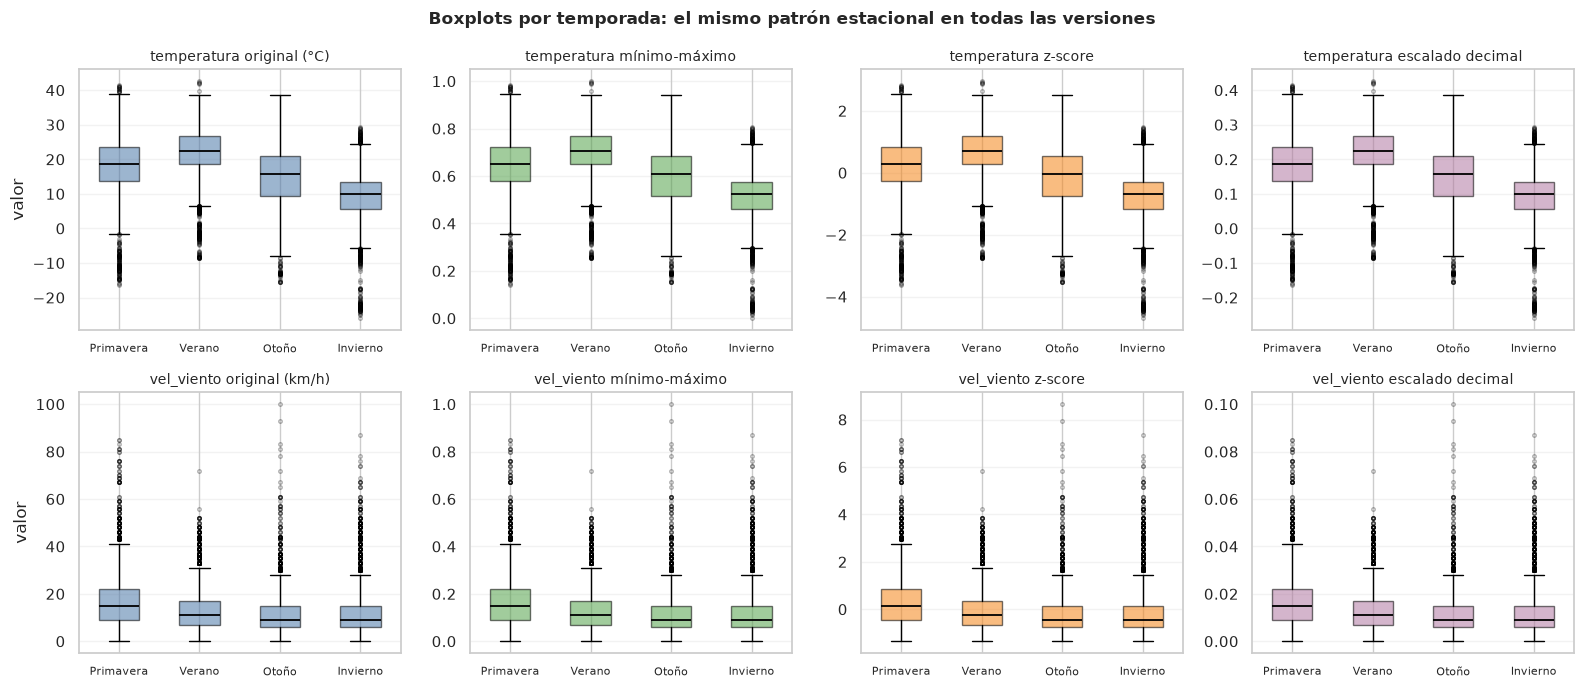

In [29]:
# --- 4.e Boxplots por temporada: original y versiones normalizadas ---
variables_4e = {"temperatura": "°C", "vel_viento": "km/h"}
versiones_4e = {"Original": "", "Mínimo-máximo": "_minmax",
                "Z-score": "_zscore", "Escalado decimal": "_decimal"}
colores_4e = {"Original": COLOR_ORIGINAL, "Mínimo-máximo": "#54A24B",
              "Z-score": "#F58518", "Escalado decimal": "#B279A2"}
# Orden cronológico de la muestra (empieza en septiembre = primavera austral).
orden_temporadas = ["Primavera", "Verano", "Otoño", "Invierno"]
temporadas_presentes = [t for t in orden_temporadas if (clima["temporada"] == t).any()]
nombres_4e = list(versiones_4e)

print("Temporadas presentes:", temporadas_presentes)
print("Observaciones por temporada:")
print(clima["temporada"].value_counts().reindex(temporadas_presentes).to_string())

# Tabla de medianas por temporada, para sustentar la lectura de los boxplots.
for variable, unidad in variables_4e.items():
    tabla = {}
    for nombre, sufijo in versiones_4e.items():
        serie = clima[variable + sufijo]
        tabla[nombre] = [serie[clima["temporada"] == temporada].median()
                         for temporada in temporadas_presentes]
    tabla_4e = pd.DataFrame(tabla, index=temporadas_presentes)
    print(f"\nMedianas de {variable} ({unidad}) por temporada")
    display(tabla_4e.round(4))

# Boxplots: un panel por versión (original + 3 normalizadas) y por variable.
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
for fila, (variable, unidad) in enumerate(variables_4e.items()):
    for columna, nombre in enumerate(nombres_4e):
        sufijo = versiones_4e[nombre]
        serie = clima[variable + sufijo]
        datos_por_temporada = [serie[clima["temporada"] == temporada].dropna()
                               for temporada in temporadas_presentes]
        cajas = ejes[fila, columna].boxplot(
            datos_por_temporada, widths=0.5, patch_artist=True,
            medianprops=dict(color="black", linewidth=1.3),
            flierprops=dict(markersize=2.5, alpha=0.3))
        for caja in cajas["boxes"]:
            caja.set_facecolor(colores_4e[nombre])
            caja.set_alpha(0.55)
        ejes[fila, columna].set_xticks(range(1, len(temporadas_presentes) + 1),
                                       labels=temporadas_presentes, fontsize=8)
        etiqueta = (f"{variable} original ({unidad})" if nombre == "Original"
                    else f"{variable} {nombre.lower()}")
        ejes[fila, columna].set_title(etiqueta, fontsize=10)
        ejes[fila, columna].grid(axis="y", alpha=0.25)
    ejes[fila, 0].set_ylabel("valor")
fig.suptitle("Boxplots por temporada: el mismo patrón estacional en todas las versiones",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


**Qué muestra cada variable.** En `temperatura` el patrón estacional es clarísimo y se lee igual en las cuatro columnas: la caja de verano (Q1 18,6 °C a Q3 26,7 °C) queda casi por completo por encima de la de invierno (5,7 °C a 13,3 °C) —la mediana invernal de 10,0 °C está por debajo del primer cuartil veraniego— y las de primavera (mediana 18,5 °C) y otoño (15,9 °C) quedan en el medio, en ese orden. El otoño es la temporada con la caja más ancha (IQR de 11,7 °C, contra 7,6 °C en invierno), y es invierno el que aporta la cola de valores extremadamente fríos (Marambio). En `vel_viento` el patrón es más suave: la primavera es la temporada más ventosa (mediana 15 km/h; caja 9–22 km/h), le sigue el verano (11 km/h) y otoño e invierno quedan prácticamente iguales (9 km/h, caja 6–15 km/h); en todas las temporadas la caja queda arriba de la cola larga de ráfagas atípicas.

**El patrón se conserva en todas las versiones.** Cada fila de la grilla se repite con la misma forma en sus cuatro columnas: la normalización estira y corre la escala pero no altera el orden de las observaciones, así que mediana, cajas y outliers de cada temporada ocupan las mismas posiciones relativas. Que esto se cumpla en las tres técnicas es una verificación útil: si una versión mostrara otro patrón estacional, sería señal de que la transformación se aplicó mal.

**Ventajas de comparar con variables normalizadas.** En las columnas originales, las filas no se pueden confrontar entre sí: un grado y un km/h no son comparables, y cada panel usa su propia escala. Al normalizar desaparecen la unidad y la magnitud, y la comparación pasa a ser posible:

- Con **z-score** la unidad es el desvío estándar de cada variable, y se puede medir qué tan fuerte es la estacionalidad relativa: la mediana de temperatura salta de −0,68 desvíos en invierno a +0,71 en verano (≈ 1,4 desvíos de amplitud estacional), mientras que la de viento va de −0,45 en otoño/invierno a +0,15 en primavera (≈ 0,6 desvíos). En esa escala es válido afirmar que la temperatura tiene una estacionalidad más del doble de intensa que el viento, algo que no se puede decir comparando °C con km/h.
- Con **mínimo-máximo** ambas variables quedan acotadas a [0, 1] y las cajas se leen como posición dentro del recorrido de cada variable (por ejemplo, la mediana de verano está en 0,71 del recorrido térmico, y la de otoño/invierno del viento en 0,09). El costo es que el recorrido lo fijan los extremos globales (−26 °C y 42,6 °C; 0 y 100 km/h), por lo que las cajas ocupan una franja angosta del panel y las diferencias estacionales se ven más pequeñas de lo que son.
- Con **escalado decimal** se elimina la unidad y se conserva la estructura estacional, pero la escala resultante depende del máximo de cada variable (la temperatura queda en el orden de 0,4 y el viento de 0,1), así que sigue sin alinear los rangos entre variables: sirve para quitar la unidad, no para comparar magnitudes entre atributos.

En resumen, los boxplots por temporada confirman lo visto en 4.d (las tres técnicas son lineales y preservan la información) y muestran la ventaja práctica de normalizar: recién sin unidades los boxplots de `temperatura` y `vel_viento` se pueden comparar entre sí, y el z-score es el que mejor lo hace porque estandariza las dos variables a la misma unidad (desvíos estándar).


## Parte 2: Manejo de datos faltantes y reducción de dimensionalidad

### 5. Datos faltantes

#### 5.a Análisis del tipo de faltante

El dataset `alquileres.csv` reúne 29.438 avisos de alquiler temporario de la Ciudad de Buenos Aires. Antes de reemplazar valores conviene responder dos preguntas: **dónde** están los faltantes y, sobre todo, **por qué** faltan. La técnica de imputación que corresponde depende de esa causa.

En calidad de datos se distinguen tres mecanismos según de qué depende la probabilidad de que un valor falte:

- **MCAR** (*Missing Completely At Random*): la falta no depende de ninguna variable, ni observada ni faltante; es una pérdida puramente aleatoria (por ejemplo, una fila que se pierde al azar).
- **MAR** (*Missing At Random*): la falta no depende del valor faltante en sí, pero sí de otras variables que **sí** observamos (por ejemplo, un atributo que no informan los avisos de cierto tipo de propiedad, y ese tipo lo conocemos).
- **MNAR** (*Missing Not At Random*): la falta depende del propio valor que no se ve, o de algo que no se midió (por ejemplo, si los alquileres más caros fueran justamente los que no publican precio).

La causa no se observa directamente: se **infiere** con evidencia. Dos comparaciones permiten hacerlo:

1. **Entre columnas:** si los faltantes de dos variables aparecen siempre juntos, probablemente comparten una causa común en vez de ser dos problemas independientes.
2. **Contra los valores observados:** si el grupo de filas con un faltante se comporta distinto del resto en otras variables (otras medianas, otras proporciones), entonces la falta depende de lo observado y estamos ante MAR; si los grupos son iguales en todo lo que podemos ver, MCAR queda como explicación razonable; y si el faltante parece depender del valor ausente, es MNAR (que por definición no se puede confirmar sin ese valor).

Para las variables numéricas se compara el grupo con faltante contra el resto con el **test de Mann-Whitney**, y para las categóricas con el **test chi²** de independencia. Un *p* muy chico indica que las diferencias difícilmente se expliquen por azar, es decir, que la falta **no** es completamente aleatoria. Antes de usarlos, el apartado siguiente explica en detalle por qué corresponde cada test y cómo se leen sus resultados.

,Variable,Tipo,Faltantes,Porcentaje
0,dormitorios,float64,5814,19.75
1,banios,float64,3599,12.23
2,puntaje_resenias,float64,3537,12.02
3,camas,float64,2566,8.72
4,precio_ars,float64,1918,6.52
5,minimo_noches,float64,6,0.02
6,tipo_habitacion,str,0,0.00
7,id,int64,0,0.00
8,capacidad,int64,0,0.00
9,barrio,str,0,0.00


Filas totales: 29438
Celdas faltantes: 17440 de 471008
Filas completas: 17693 (60.1 %)
Filas con al menos un faltante: 11745 (39.9 %)


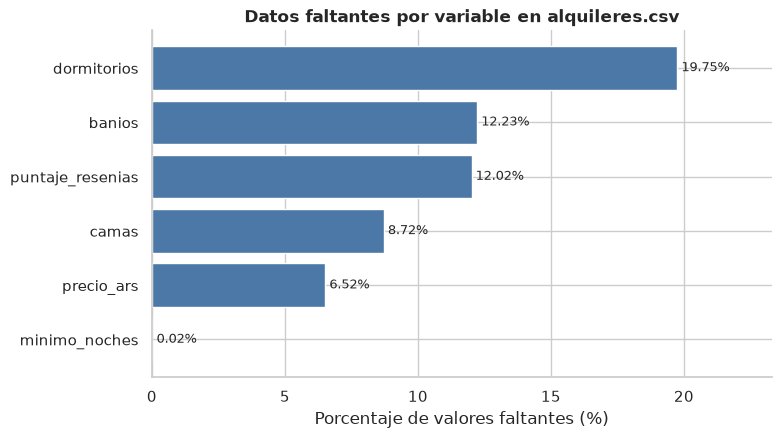

In [30]:
# --- 5.a Cuantificación de los datos faltantes ---
alquileres = pd.read_csv("data/alquileres.csv")
n_alq = len(alquileres)

conteo_faltantes = alquileres.isna().sum()
tabla_faltantes = pd.DataFrame({
    "Variable": alquileres.columns,
    "Tipo": alquileres.dtypes.astype(str).to_numpy(),
    "Faltantes": conteo_faltantes.to_numpy(),
    "Porcentaje": (100 * conteo_faltantes / n_alq).round(2).to_numpy(),
}).sort_values("Faltantes", ascending=False).reset_index(drop=True)
display(tabla_faltantes)

faltantes_por_fila = alquileres.isna().sum(axis=1)
print(f"Filas totales: {n_alq}")
print(f"Celdas faltantes: {int(alquileres.isna().sum().sum())} de {n_alq * alquileres.shape[1]}")
print(f"Filas completas: {(faltantes_por_fila == 0).sum()} ({100 * (faltantes_por_fila == 0).mean():.1f} %)")
print(f"Filas con al menos un faltante: {(faltantes_por_fila > 0).sum()} "
      f"({100 * (faltantes_por_fila > 0).mean():.1f} %)")

# Gráfico de barras: porcentaje de faltantes por columna (solo las que tienen alguno)
pct_faltantes = (100 * conteo_faltantes / n_alq)
pct_faltantes = pct_faltantes[pct_faltantes > 0].sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(pct_faltantes.index, pct_faltantes.values,
                 color=COLOR_ORIGINAL, edgecolor="white")
ax.bar_label(barras, fmt="%.2f%%", padding=3, fontsize=9)
ax.set_xlabel("Porcentaje de valores faltantes (%)")
ax.set_title("Datos faltantes por variable en alquileres.csv", fontweight="bold")
ax.set_xlim(0, pct_faltantes.max() * 1.18)
sns.despine(ax=ax)
plt.show()

De las 16 columnas, **seis** tienen valores faltantes: `dormitorios` (19,75 %), `banios` (12,23 %), `puntaje_resenias` (12,02 %), `camas` (8,72 %), `precio_ars` (6,52 %) y `minimo_noches` (0,02 %). Las otras diez (`id`, `barrio`, `tipo_propiedad`, `tipo_habitacion`, `capacidad`, `cantidad_resenias`, `superanfitrion`, `latitud`, `longitud` y `noches_ocupadas_anio`) están completas.

En total son 17.440 celdas faltantes sobre 471.008 (3,7 %), repartidas en 11.745 filas: el **60,1 %** de los avisos está completo y el **39,9 %** tiene al menos un faltante. Los faltantes no están concentrados en unas pocas filas raras, sino repartidos en una porción considerable del dataset; por eso lo que se haga con ellos puede mover los resultados de los pasos siguientes.

In [31]:
# --- 5.a Patrones de faltantes: co-ocurrencia y concentración por fila ---
columnas_con_faltantes = conteo_faltantes[conteo_faltantes > 0].index.tolist()
matriz_faltantes = alquileres[columnas_con_faltantes].isna()

print("Correlación entre los faltantes de cada par de columnas:")
display(matriz_faltantes.astype(int).corr().round(3))

patrones = matriz_faltantes.apply(lambda fila: "".join("1" if v else "0" for v in fila), axis=1)
print("\nPatrones más frecuentes (1 = faltante), en el orden de las columnas:")
print("  " + ", ".join(columnas_con_faltantes))
for patron, cantidad in patrones.value_counts().head(10).items():
    print(f"  {patron}  {cantidad:6d}  ({100 * cantidad / n_alq:5.2f} %)")
print(f"\nCombinaciones distintas observadas: {patrones.nunique()}")

print("\nCantidad de faltantes por fila:")
for cantidad_faltantes, cantidad in faltantes_por_fila.value_counts().sort_index().items():
    print(f"  {cantidad_faltantes} faltante(s): {cantidad:6d} filas "
          f"({100 * cantidad / n_alq:5.2f} %)")

Correlación entre los faltantes de cada par de columnas:


,banios,dormitorios,camas,precio_ars,minimo_noches,puntaje_resenias
banios,1.000,-0.022,0.644,0.476,0.002,0.022
dormitorios,-0.022,1.000,-0.036,-0.021,-0.001,0.031
camas,0.644,-0.036,1.000,0.576,-0.004,0.025
precio_ars,0.476,-0.021,0.576,1.000,-0.004,0.057
minimo_noches,0.002,-0.001,-0.004,-0.004,1.000,-0.005
puntaje_resenias,0.022,0.031,0.025,0.057,-0.005,1.000



Patrones más frecuentes (1 = faltante), en el orden de las columnas:
  banios, dormitorios, camas, precio_ars, minimo_noches, puntaje_resenias
  000000   17693  (60.10 %)
  010000    4297  (14.60 %)
  000001    2123  ( 7.21 %)
  100000    1053  ( 3.58 %)
  101100     989  ( 3.36 %)
  010001     683  ( 2.32 %)
  101000     509  ( 1.73 %)
  001000     345  ( 1.17 %)
  000100     292  ( 0.99 %)
  110000     272  ( 0.92 %)

Combinaciones distintas observadas: 33

Cantidad de faltantes por fila:
  0 faltante(s):  17693 filas (60.10 %)
  1 faltante(s):   8114 filas (27.56 %)
  2 faltante(s):   1963 filas ( 6.67 %)
  3 faltante(s):   1299 filas ( 4.41 %)
  4 faltante(s):    342 filas ( 1.16 %)
  5 faltante(s):     27 filas ( 0.09 %)


Mirando los patrones aparecen dos comportamientos bien distintos:

1. **`dormitorios` falta solo.** El patrón `010000` (únicamente `dormitorios` faltante) es el segundo más frecuente, con 4.297 filas (14,60 %). No se arrastra junto a otras columnas: es un problema propio de esa variable.
2. **`banios`, `camas` y `precio_ars` faltan juntas.** La correlación entre sus faltantes es alta (0,64 entre `banios` y `camas`, 0,58 entre `camas` y `precio_ars`, 0,48 entre `banios` y `precio_ars`), y el patrón `101100` (faltan exactamente esas tres) reúne 989 filas. Que tres columnas falten a la vez en las mismas filas sugiere un **origen común** (un grupo de avisos con el registro incompleto) y no tres pérdidas independientes.

Además, la mayoría de las filas afectadas tiene un solo faltante (27,56 % de las filas con 1, contra 6,67 % con 2, 4,41 % con 3 y porcentajes menores para 4 y 5), así que los faltantes están bastante dispersos.

Queda por ver de qué depende cada uno de estos dos comportamientos, y ahí está la clave para decidir cómo imputar.

#### Cómo se comparan dos grupos: por qué chi² y por qué Mann-Whitney

Todo el análisis del mecanismo se reduce a una sola pregunta: **¿el grupo de filas con un valor faltante se comporta distinto del resto?** Si se comporta igual en todo lo que podemos observar, la falta puede ser aleatoria (MCAR); si se comporta distinto, entonces depende de algo que sí observamos (MAR). La respuesta se busca **comparando los dos grupos**, y la prueba que corresponde depende del **tipo de variable** con la que se hace la comparación.

**Variables categóricas → test chi².** Cuando lo que se compara son categorías (`barrio`, `superanfitrion`, `tipo_habitacion`, o los propios indicadores de "falta"/"no falta"), se arma una **tabla de contingencia** con los conteos de cada cruce y se aplica el test chi² de independencia.

La idea es comparar lo **observado** (O) con lo que se **esperaría** si las dos variables fueran independientes (E). El valor esperado de cada celda se calcula con los totales de su fila y su columna:

$$E = \frac{\text{total de la fila} \times \text{total de la columna}}{n}$$

Y el estadístico suma, sobre todas las celdas, la diferencia entre lo observado y lo esperado, en relación con lo esperado:

$$\chi^2 = \sum \frac{(O - E)^2}{E}$$

Si las dos variables son independientes, lo observado se parecerá a lo esperado y el chi² será chico; cuanto más grande sea el chi², más lejos está la tabla de la independencia. Los **grados de libertad** son $gl = (filas - 1) \times (columnas - 1)$ y, junto con el chi², determinan el p-valor.

Un ejemplo con nuestros datos: si los faltantes de `banios` y `camas` fueran independientes, esperaríamos unos 314 avisos con los dos faltantes a la vez; observamos 2.066, más de seis veces más. Esa distancia es la que produce un chi² enorme.

**Variables numéricas → test de Mann-Whitney.** Cuando lo que se compara es una variable numérica (`noches_ocupadas_anio`, `cantidad_resenias`, `capacidad`) entre los dos grupos (el que tiene el faltante y el resto), se usa el test de Mann-Whitney.

¿Por qué no un test de medias como el t-test? Porque estas variables son muy **asimétricas**: tienen una cola larga hacia la derecha, como se vio en los histogramas del punto 1, y los dos grupos tienen tamaños muy distintos. Mann-Whitney no trabaja con los valores sino con sus **rangos**: junta todos los valores, los ordena de menor a mayor y cuenta cuántas veces un valor de un grupo supera a uno del otro. Al no usar los valores originales, no supone que los datos sigan una distribución normal y no se deja arrastrar por unos pocos valores extremos.

**Cómo se leen los resultados.** En los dos tests el **p-valor** responde siempre la misma pregunta:

> Si en realidad no hubiera ninguna relación (o ninguna diferencia entre los grupos), ¿qué probabilidad había de observar algo tan extremo como lo que observamos?

Por eso un p muy chico (por convención menor que 0,05, aunque acá todos son muchísimo menores) indica que la diferencia difícilmente se deba al azar, es decir, que las dos variables **no** son independientes.

Pero el p-valor **no dice cuánto** difieren los grupos: para eso hay que mirar las **medianas**, que es la razón por la que se imprimen al lado. Con 29.438 filas, hasta una diferencia insignificante da un p diminuto; lo que decide si la diferencia importa es su tamaño, no el p.

In [32]:
# --- 5.a Dos casos con un mecanismo claro: puntaje_resenias y dormitorios ---
from scipy import stats

# 1) puntaje_resenias: ¿falta siempre que el aviso no tiene reseñas?
print("1) puntaje_resenias vs. cantidad_resenias")
tabla_resenias = pd.crosstab(
    alquileres["puntaje_resenias"].isna(),
    alquileres["cantidad_resenias"] == 0,
    rownames=["Falta puntaje_resenias"],
    colnames=["cantidad_resenias = 0"],
)
display(tabla_resenias)

# 2) dormitorios: ¿depende del tipo de habitación?
print("\n2) Faltantes de dormitorios según tipo_habitacion")
pct_dormitorios = alquileres.groupby("tipo_habitacion")["dormitorios"].apply(
    lambda s: 100 * s.isna().mean()
).round(1).sort_values(ascending=False)
display(pct_dormitorios.to_frame("Faltantes de dormitorios (%)"))

1) puntaje_resenias vs. cantidad_resenias


cantidad_resenias = 0,False,True
Falta puntaje_resenias,,
False,25901,0
True,0,3537



2) Faltantes de dormitorios según tipo_habitacion


,Faltantes de dormitorios (%)
tipo_habitacion,
Private room,74.9
Shared room,28.3
Entire home/apt,14.4
Hotel room,3.1


#### El bloque `banios` + `camas` + `precio_ars`: cómo se llega a concluir MAR

Este es el caso más interesante del dataset, porque involucra tres columnas a la vez. El razonamiento se arma en cinco pasos, más una salvedad final de interpretación.

**Paso 1: los faltantes aparecen juntos.** Si cada columna fallara por su cuenta, la cantidad de filas con dos faltantes simultáneos sería la que predice el azar: unas 314 filas para `banios` y `camas`. Observamos 2.066. Eso descarta que sean tres problemas independientes: los tres faltantes **se comportan como un bloque** y comparten un origen (un grupo de avisos con el registro incompleto).

**Paso 2: el grupo del bloque no es un grupo cualquiera.** Comparado con el resto del dataset, las 1.335 filas donde faltan las tres columnas tienen sistemáticamente menos actividad: mediana de `noches_ocupadas_anio` de 12 contra 42, mediana de reseñas de 10 contra 18, `minimo_noches` de 3 contra 2, y un 41,3 % de avisos con ocupación estimada nula contra un 22,4 % del resto.

**Paso 3: control negativo.** No todo lo observado difiere: `capacidad` tiene mediana 2 en los dos grupos (*p* = 0,46). Vale la pena detenerse acá, porque es lo que evita sobrerinterpretar. Si *todas* las variables difirieran, la explicación sería simplemente "el bloque son avisos de otro tipo"; que la diferencia aparezca solo en las variables de actividad (y no en el tamaño de la propiedad) indica que la falta **se asocia** con cuán activo es el aviso, no con su tipo.

**Paso 4: conclusión.** La probabilidad de que falte un valor **depende de variables que sí observamos**. Eso es exactamente la definición de MAR, y descarta el MCAR.

**Paso 5: qué se puede y qué no se puede afirmar.** Con lo anterior se **rechaza MCAR** con evidencia fuerte. Lo que **no** se puede es *demostrar* MAR: para eso habría que conocer los valores faltantes, que por definición no están. Y como no se ven, tampoco se puede descartar que la falta dependa de ellos (MNAR): por ejemplo, que los departamentos cuyo precio no figura sean sistemáticamente los más caros. La conclusión correcta es entonces: **no es MCAR; la evidencia es consistente con MAR, que es la hipótesis de trabajo mejor respaldada**.

Esa distinción no es un tecnicismo: es la que habilita (o no) los métodos de imputación de los puntos siguientes. Si la falta depende solo de variables observadas, imputar usando esas variables es defendible; si dependiera del valor oculto, cualquier imputación quedaría sesgada en una dirección que no podemos medir.

**Una salvedad final: asociación no es causalidad.** Todo lo anterior establece una **asociación** entre los faltantes y la actividad, no la dirección de esa relación. El test no dice si la falta provoca la baja actividad o al revés. Y en este dominio, la dirección inversa es al menos tan plausible: el aviso se publica primero con toda su información y recién después la gente decide reservar, de modo que un aviso con datos incompletos (sin baños, camas o —sobre todo— sin precio) resulta menos atractivo o directamente no se puede reservar, y acumula menos ocupación y menos reseñas. Bajo esa lectura, la información faltante sería la *causa* y la baja actividad la *consecuencia*.

Hay todavía una tercera historia, igual de compatible: que ambas cosas compartan una causa común, por ejemplo un anfitrión que abandonó el aviso (deja de actualizarlo, con lo que el registro queda incompleto, y al mismo tiempo nadie lo reserva, con lo que la actividad cae). Con una fotografía instantánea como este dataset no se puede distinguir entre las tres: los datos muestran la correlación, no el orden temporal.

Lo importante es que **la clasificación no cambia**. MAR solo afirma que la probabilidad de que falte un dato depende de variables observadas; no se pronuncia sobre quién causa a quién. Cualquiera de las tres lecturas —falta → inactividad, inactividad → falta, o causa común— es compatible con MAR.

In [33]:
# --- 5.a El bloque banios + camas + precio_ars: co-ocurrencia y comparación ---


def formato_p(p):
    """Evita imprimir 0.00e+00 cuando el p-valor queda por debajo de la precisión."""
    return f"= {p:.2e}" if p > 1e-300 else "< 1e-300 (límite de precisión)"


# 1) ¿Faltan juntas más de lo que explicaría el azar? (chi² por pares)
print("1) Co-ocurrencia de los faltantes (chi² de independencia)")
for columna_1, columna_2 in [("banios", "camas"), ("banios", "precio_ars"),
                             ("camas", "precio_ars")]:
    tabla = pd.crosstab(alquileres[columna_1].isna(), alquileres[columna_2].isna())
    chi2, p, gl, esperado = stats.chi2_contingency(tabla)
    print(f"  {columna_1} y {columna_2}: faltan las dos en {tabla.loc[True, True]:5d} filas "
          f"(si fueran independientes se esperarían {esperado[1, 1]:7.1f}) | "
          f"chi² = {chi2:7.0f} | gl = {gl} | p {formato_p(p)}")

# Un caso concreto, para ver de dónde sale el chi²
tabla_banios_camas = pd.crosstab(alquileres["banios"].isna(), alquileres["camas"].isna())
chi2_bc, p_bc, gl_bc, esperado_bc = stats.chi2_contingency(tabla_banios_camas)
print("\n  Caso concreto: banios x camas")
print("  Observado:")
display(tabla_banios_camas)
print("  Lo que se esperaría si los dos faltantes fueran independientes:")
display(pd.DataFrame(esperado_bc, index=tabla_banios_camas.index,
                     columns=tabla_banios_camas.columns).round(1))

# 2) ¿El grupo del bloque se comporta distinto del resto? (Mann-Whitney)
print("\n2) Variables observadas: grupo del bloque vs. resto")
en_bloque = (alquileres["banios"].isna() & alquileres["camas"].isna()
             & alquileres["precio_ars"].isna())
print(f"  Filas en el bloque: {int(en_bloque.sum())}")
for columna in ["noches_ocupadas_anio", "cantidad_resenias", "minimo_noches", "capacidad"]:
    con_faltante = alquileres.loc[en_bloque, columna].dropna()
    sin_faltante = alquileres.loc[~en_bloque, columna].dropna()
    p = stats.mannwhitneyu(con_faltante, sin_faltante).pvalue
    print(f"  {columna:22s} mediana bloque = {con_faltante.median():6.1f} | "
          f"resto = {sin_faltante.median():6.1f} | p {formato_p(p)}")

# 3) Proporción de avisos con ocupación estimada nula, en cada grupo
print("\n3) Porcentaje de avisos con noches_ocupadas_anio = 0")
pct_ocupacion_cero = alquileres.groupby(en_bloque)["noches_ocupadas_anio"].apply(
    lambda s: 100 * (s == 0).mean()).round(1)
pct_ocupacion_cero.index = ["Resto", "Bloque"]
print(pct_ocupacion_cero.to_string())

# 4) La falta de precio también depende de variables observadas categóricas
print("\n4) precio_ars: relación del faltante con variables observadas (chi²)")
for columna in ["barrio", "superanfitrion", "tipo_habitacion"]:
    tabla = pd.crosstab(alquileres[columna], alquileres["precio_ars"].isna())
    chi2, p, gl, _ = stats.chi2_contingency(tabla)
    print(f"  {columna:16s} chi² = {chi2:8.1f} | gl = {gl:3d} | p {formato_p(p)}")

1) Co-ocurrencia de los faltantes (chi² de independencia)
  banios y camas: faltan las dos en  2066 filas (si fueran independientes se esperarían   313.7) | chi² =   12209 | gl = 1 | p < 1e-300 (límite de precisión)
  banios y precio_ars: faltan las dos en  1368 filas (si fueran independientes se esperarían   234.5) | chi² =    6672 | gl = 1 | p < 1e-300 (límite de precisión)
  camas y precio_ars: faltan las dos en  1347 filas (si fueran independientes se esperarían   167.2) | chi² =    9748 | gl = 1 | p < 1e-300 (límite de precisión)

  Caso concreto: banios x camas
  Observado:


camas,False,True
banios,,
False,25339,500
True,1533,2066


  Lo que se esperaría si los dos faltantes fueran independientes:


camas,False,True
banios,,
False,23586.7,2252.3
True,3285.3,313.7



2) Variables observadas: grupo del bloque vs. resto
  Filas en el bloque: 1335
  noches_ocupadas_anio   mediana bloque =   12.0 | resto =   42.0 | p = 2.04e-73
  cantidad_resenias      mediana bloque =   10.0 | resto =   18.0 | p = 9.85e-19
  minimo_noches          mediana bloque =    3.0 | resto =    2.0 | p = 4.02e-55
  capacidad              mediana bloque =    2.0 | resto =    2.0 | p = 4.58e-01

3) Porcentaje de avisos con noches_ocupadas_anio = 0
Resto     22.4
Bloque    41.3

4) precio_ars: relación del faltante con variables observadas (chi²)
  barrio           chi² =    173.9 | gl =  47 | p = 1.86e-16
  superanfitrion   chi² =    112.8 | gl =   1 | p = 2.44e-26
  tipo_habitacion  chi² =     10.1 | gl =   3 | p = 1.77e-02


**Qué dice la evidencia en cada caso.**

- **`puntaje_resenias` (3.537 faltantes, 12,02 %) — faltante estructural.** El cruce con `cantidad_resenias` es determinístico: falta en las 3.537 filas con `cantidad_resenias = 0` y en ninguna otra (la forma más común es el patrón `000001`, 2.123 filas). No es un dato que se perdió, es un valor que **no existe**: si el aviso no tiene reseñas, no hay un puntaje que registrar. Es un caso de faltante *por diseño* (*missing by design*), que conviene no confundir con un dato desconocido.

- **`dormitorios` (5.814 faltantes, 19,75 %) — MAR, asociado al tipo de habitación.** Falta en el 74,9 % de los cuartos privados y solo en el 14,4 % de los departamentos completos (y en el 3,1 % de las habitaciones de hotel). La causa es interpretable: un cuarto privado dentro de una casa no tiene "dormitorios" propios, así que el campo queda vacío. Dentro de los departamentos completos, los que no informan dormitorios tienen capacidad mediana 2 contra 3 de los que sí informan, lo que sugiere monoambientes (una interpretación razonable, no una certeza). En los dos casos la falta depende de variables que **sí** observamos: es MAR.

- **`banios`, `camas` y `precio_ars` (faltan las tres en 1.335 filas) — MAR, asociado a la actividad del aviso.** La co-ocurrencia es muy superior a la del azar (2.066 filas con `banios` y `camas` faltantes, contra 314 esperadas si fueran independientes; chi² ≈ 12.209 con 1 grado de libertad y *p* por debajo del límite de precisión), así que los tres faltantes **no son independientes**. Esa co-ocurrencia se acompaña de una asociación con la actividad: el bloque tiene medianas de `noches_ocupadas_anio` de 12 contra 42, de reseñas de 10 contra 18 y de `minimo_noches` de 3 contra 2, y casi el doble de avisos con ocupación nula (41,3 % contra 22,4 %). El control negativo sobre `capacidad` (mediana 2 en los dos grupos, *p* = 0,46) confirma que la diferencia es específica de las variables de actividad. Además, la falta de `precio_ars` depende de `barrio` (chi² = 173,9; *p* ≈ 1,9·10⁻¹⁶) y de `superanfitrion` (chi² = 112,8; *p* ≈ 2,4·10⁻²⁶; los superanfitriones tienen 4,7 % de precio faltante contra 7,8 %). Todo esto **rechaza MCAR** y sostiene MAR como hipótesis de trabajo. Ojo con la dirección: la asociación con la actividad es correlación, y el dato no establece si la falta provoca la baja actividad o al revés (ver la salvedad final del apartado anterior).

- **`minimo_noches` (6 faltantes, 0,02 %) — compatible con MCAR.** Con tan pocos casos no hay patrón que analizar; se comporta como una pérdida aislada.

**Qué se puede y qué no se puede afirmar.** El análisis permite **rechazar MCAR** con evidencia fuerte en los casos anteriores. Lo que no permite es *demostrar* MAR: como los valores faltantes no se ven, siempre queda abierta la posibilidad de que la falta dependa de ellos (MNAR) —por ejemplo, que los avisos sin precio sean sistemáticamente más caros o más baratos—. La conclusión honesta es: **no es MCAR; la evidencia es consistente con MAR, que es la hipótesis de trabajo mejor respaldada**.

**Consecuencias para los pasos siguientes.** El análisis deja el terreno preparado para 5.b–5.f:

- `puntaje_resenias` es un faltante estructural más que un dato perdido. En 5.b hay que tenerlo en cuenta: reemplazarlo por la media o la mediana trata como "desconocido" algo que en realidad "no existe", así que el resultado debe interpretarse con cuidado.
- `dormitorios` y el bloque `banios`/`camas`/`precio_ars` son MAR, así que la imputación puede **condicionarse** por las variables asociadas a la falta (`tipo_habitacion` para `dormitorios`; las variables de actividad para el bloque). Usar vecinos parecidos es mejor que usar un único valor global.
- `minimo_noches`, con 6 casos, no altera ninguna conclusión: cualquier método razonable da un resultado equivalente.

### 5.b Sustitución por una medida de tendencia central

El primer método que plantea la consigna es reemplazar cada valor faltante por una **medida de tendencia central**, es decir, por un valor que resuma "alrededor de dónde" están los datos observados, y hacerlo **según corresponda**: eligiendo en cada variable la medida que mejor represente a su distribución. Las tres medidas habituales son:

- **Media** ($\bar{x}$): el promedio aritmético. Usa toda la información disponible, pero **es sensible a los valores extremos**: unos pocos casos muy grandes (o muy chicos) la arrastran hacia su lado.
- **Mediana**: el valor que queda en el medio cuando se ordenan las observaciones. Al depender solo del **orden** y no de las distancias, no la afectan los valores extremos.
- **Moda**: el valor más frecuente. Es útil sobre todo en variables discretas, porque siempre devuelve un valor que existe.

**¿Cuál corresponde en cada caso?** La decisión depende de la **forma** de la distribución, que ya se midió en 5.a con el **sesgo** (*skewness*):

- Si la distribución es **simétrica** (sesgo cercano a 0), media y mediana coinciden y da lo mismo usar cualquiera; se prefiere la media porque aprovecha más información.
- Si la distribución es **asimétrica**, la media se corre hacia la cola y deja de representar al caso típico; ahí corresponde la **mediana**, que resiste los valores extremos.

Como criterio práctico se toma $|\text{sesgo}| > 1$ para considerar que la asimetría es fuerte. En las variables de conteo (`dormitorios`, `banios`, `camas`) hay además un motivo propio: la media puede dar valores como 1,36 dormitorios, que **no existen**, mientras que la mediana y la moda siempre devuelven un valor alcanzable.

La imputación se aplica sobre una **copia** del dataset (`alquileres_central`), para conservar la tabla original con faltantes y poder comparar los métodos entre sí en 5.f.


In [34]:
# --- 5.b Sustitución por una medida de tendencia central ---
# La medida se elige según la forma de la distribución: con |sesgo| > 1 la media
# se corre hacia la cola y deja de representar al caso típico, así que corresponde
# la mediana, que depende solo del orden y no la arrastran los valores extremos.
columnas_5b = (alquileres[columnas_con_faltantes].isna().sum()
               .sort_values(ascending=False).index.tolist())

filas_decision = []
for columna in columnas_5b:
    observados = alquileres[columna].dropna()
    media, mediana, sesgo = observados.mean(), observados.median(), observados.skew()
    elegida = "mediana" if abs(sesgo) > 1 else "media"
    filas_decision.append({
        "Faltantes": int(alquileres[columna].isna().sum()),
        "Media": media,
        "Mediana": mediana,
        "Moda": observados.mode().iloc[0],
        "Sesgo": sesgo,
        "Medida elegida": elegida,
        "Valor imputado": mediana if elegida == "mediana" else media,
    })

decision_5b = pd.DataFrame(filas_decision, index=columnas_5b)
print("Media, mediana y moda de cada variable con faltantes (sobre los valores observados):")
display(decision_5b.round(2))

# La imputación se hace sobre una copia: la tabla original con faltantes se
# conserva para poder comparar los distintos métodos entre sí en 5.f.
alquileres_central = alquileres.copy()
for columna in columnas_5b:
    valor = decision_5b.loc[columna, "Valor imputado"]
    alquileres_central[columna] = alquileres_central[columna].fillna(valor)

print("Celdas faltantes en las seis columnas, antes:  ",
      int(alquileres[columnas_5b].isna().sum().sum()))
print("Celdas faltantes en las seis columnas, después:",
      int(alquileres_central[columnas_5b].isna().sum().sum()))
print("Celdas faltantes en todo el dataset, después:  ",
      int(alquileres_central.isna().sum().sum()))


Media, mediana y moda de cada variable con faltantes (sobre los valores observados):


,Faltantes,Media,Mediana,Moda,Sesgo,Medida elegida,Valor imputado
dormitorios,5814,1.36,1.00,1.0,8.03,mediana,1.00
banios,3599,1.24,1.00,1.0,7.88,mediana,1.00
puntaje_resenias,3537,4.78,4.87,5.0,-5.48,mediana,4.87
camas,2566,1.94,1.00,1.0,6.27,mediana,1.00
precio_ars,1918,131371.62,103206.00,101945.0,4.86,mediana,103206.00
minimo_noches,6,5.03,2.00,1.0,16.29,mediana,2.00


Celdas faltantes en las seis columnas, antes:   17440
Celdas faltantes en las seis columnas, después: 0
Celdas faltantes en todo el dataset, después:   0


,Media antes,Media después,Mediana antes,Mediana después,Desvío antes,Desvío después,Δ desvío (%)
dormitorios,1.36,1.29,1.00,1.00,0.90,0.82,-9.06
banios,1.24,1.21,1.00,1.00,0.67,0.64,-5.61
puntaje_resenias,4.78,4.79,4.87,4.87,0.36,0.34,-5.85
camas,1.94,1.85,1.00,1.00,1.54,1.49,-2.93
precio_ars,131371.62,129536.52,103206.00,103206.00,115303.02,111699.92,-3.12
minimo_noches,5.03,5.03,2.00,2.00,18.96,18.96,-0.01


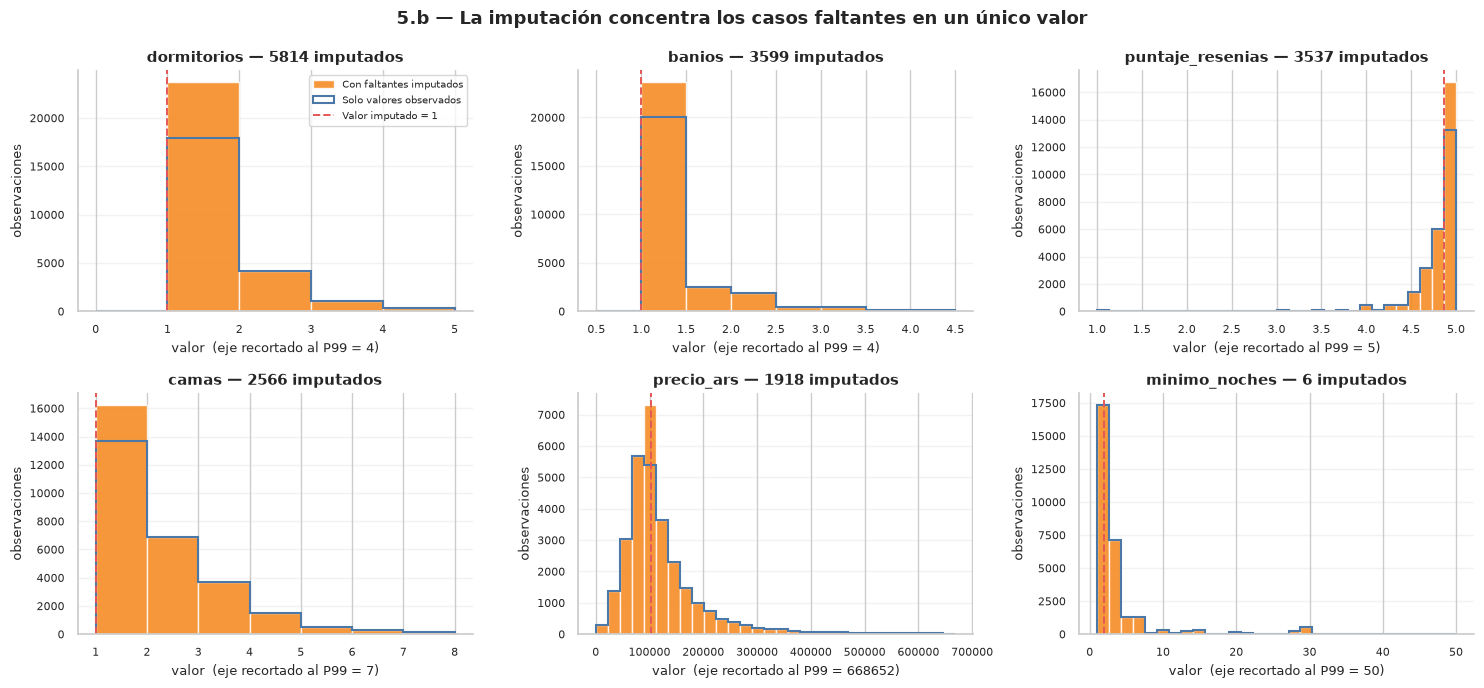

In [35]:
# --- 5.b Efecto de la imputación sobre los estadísticos ---
# Al reemplazar todas las filas afectadas por un mismo valor, la mediana queda en
# su lugar, la media se corre un poco hacia el centro y el desvío disminuye,
# porque los casos imputados ya no aportan dispersión.
comparacion_5b = []
for columna in columnas_5b:
    antes, despues = alquileres[columna], alquileres_central[columna]
    comparacion_5b.append({
        "Media antes": antes.mean(), "Media después": despues.mean(),
        "Mediana antes": antes.median(), "Mediana después": despues.median(),
        "Desvío antes": antes.std(), "Desvío después": despues.std(),
    })

comparacion_5b = pd.DataFrame(comparacion_5b, index=columnas_5b)
comparacion_5b["Δ desvío (%)"] = 100 * (comparacion_5b["Desvío después"]
                                        / comparacion_5b["Desvío antes"] - 1)
display(comparacion_5b.round(2))

# Gráfico: dónde cae la masa que se agregó. En cada panel se superponen la
# distribución de los valores observados y la de la columna ya completada.
fig, ejes = plt.subplots(2, 3, figsize=(15, 7))
for ax, columna in zip(ejes.flat, columnas_5b):
    observados = alquileres[columna].dropna()
    completados = alquileres_central[columna]
    valor_imputado = decision_5b.loc[columna, "Valor imputado"]

    # El eje se recorta al percentil 99: unas pocas observaciones muy grandes
    # aplastarían el resto del gráfico contra el borde izquierdo.
    tope = float(observados.quantile(0.99))
    valores_unicos = np.sort(observados.unique())
    if len(valores_unicos) <= 30:
        # Variable de conteo: un intervalo por cada valor que realmente toma.
        visibles = valores_unicos[valores_unicos <= tope]
        paso = float(np.diff(visibles).min()) if len(visibles) > 1 else 1.0
        bordes = np.append(visibles, visibles[-1] + paso)
    else:
        bordes = np.linspace(observados.min(), tope, 31)

    ax.hist(completados, bins=bordes, color=COLOR_SUAVIZADA, alpha=0.85,
            edgecolor="white", label="Con faltantes imputados")
    ax.hist(observados, bins=bordes, histtype="step", color=COLOR_ORIGINAL,
            linewidth=1.5, label="Solo valores observados")
    ax.axvline(valor_imputado, color="#E45756", linestyle="--", linewidth=1.4,
               label=f"Valor imputado = {valor_imputado:g}")

    ax.set_title(f"{columna} — {int(alquileres[columna].isna().sum())} imputados",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel(f"valor  (eje recortado al P99 = {tope:g})", fontsize=9)
    ax.set_ylabel("observaciones", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

ejes.flat[0].legend(frameon=True, fontsize=7.5)
fig.suptitle("5.b — La imputación concentra los casos faltantes en un único valor",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


**Qué se decidió en cada variable.** La comparación entre media, mediana y moda (tabla anterior) llevó, en las seis variables, a la misma conclusión: corresponde la **mediana**. Los valores imputados quedaron así: 1 dormitorio, 1 baño, 1 cama, $103.206 el precio, 2 noches de estadía mínima y 4,87 el puntaje.

Que "según corresponda" termine dando la misma medida en todas no es casual: los avisos se concentran en los valores bajos (1 dormitorio, 1 baño, 1 cama, precios accesibles) y tienen una cola larga de casos muy grandes. Esa forma es exactamente la que hace que la media deje de ser representativa —en `camas`, la media (1,94) casi duplica a la mediana (1)—, así que la regla del sesgo se aplica en vez de asumirse.

`puntaje_resenias` es la única con sesgo **negativo** (−5,48): los puntajes se acumulan cerca de 5 y la cola se estira hacia los valores bajos, de modo que ahí la media (4,78) queda *por debajo* de la mediana (4,87). La regla se aplica igual, y la mediana sigue siendo la que mejor representa al caso típico.

**El efecto sobre el dataset.** La verificación confirma que después de la imputación **no queda ningún faltante** (0 celdas, contra 17.440 antes). La tabla comparativa muestra tres efectos, todos esperables:

1. La **mediana no se mueve** en ninguna variable: es coherente, porque se imputó justamente sobre ella (el valor agregado cae en el mismo punto que ya ocupaba el centro).
2. La **media se corre hacia la mediana**: `camas` baja de 1,94 a 1,85, `precio_ars` de 131.371,62 a 129.536,52 y `dormitorios` de 1,36 a 1,29. En `puntaje_resenias`, en cambio, sube de 4,78 a 4,79, porque el valor imputado (4,87) está por encima de su media. Los casos imputados, que antes no contaban, ahora empujan el promedio hacia el centro.
3. El **desvío estándar disminuye** en todas. La caída va del 9,06 % en `dormitorios` al 0,01 % en `minimo_noches`, que con 6 casos imputados apenas cambia.

El gráfico muestra la causa de ese tercer efecto: en cada panel la barra naranja forma un **pico sobre el valor imputado** que no existía entre los valores observados, porque todos los casos que faltaban se apilaron en un mismo número. En `dormitorios`, con 5.814 imputados, se agregó cerca de una quinta parte del dataset (19,7 %) en el valor 1; en `minimo_noches`, con 6, el pico es invisible.

**Una advertencia sobre `puntaje_resenias`:** En 5.a se vio que este faltante es **estructural**: falta exactamente en los avisos que no tienen reseñas. Reemplazarlo por 4,87 es, en rigor, **fabricar información**: asigna un puntaje "casi perfecto" a avisos que nunca fueron calificados. El número es correcto *como medida de tendencia central de la columna*, pero no debe leerse como "estos avisos tienen ese puntaje". Ningún método que ignore *por qué* falta el dato puede resolver ese problema; conviene recordarlo al interpretar los resultados de 5.f.

**Limitación del método.** La imputación por tendencia central es la más simple y la más rápida, pero asigna **el mismo valor a todos** los casos faltantes sin mirar el resto de sus atributos. Eso tiene dos consecuencias: reduce artificialmente la varianza y achata la forma de la distribución —como acaba de mostrar el gráfico—, y **no aprovecha la información que sí tenemos** sobre esas filas. En 5.a se vio que el bloque `banios`/`camas`/`precio_ars` se asocia a la actividad del aviso y que `dormitorios` falta según el tipo de habitación, así que dos avisos que comparten el faltante pueden ser muy distintos entre sí. Los métodos siguientes (hot deck en 5.c, KNN y regresión en 5.d–5.e) apuntan precisamente a eso: darle a cada fila un valor imputado **parecido a ella**, en lugar de uno igual para todas.


### 5.c Imputación por hot deck

En 5.b el valor imputado salía de una **fórmula** (la mediana de la columna). El **hot deck** cambia el enfoque: en vez de calcular un valor, lo **toma prestado de otra observación** del mismo dataset que sí tiene el dato. Esa observación se llama **donante**, y el método no escribe ningún modelo explícito: el modelo está **implícito** en la definición de "parecido" que se use para elegir al donante.

La clase distingue dos variantes según el origen del donante:

- **Cold deck**: el donante es **externo** al dataset (una medición anterior, otra tabla, otro relevamiento). En una serie de tiempo, rellenar con el valor del día anterior es cold deck.
- **Hot deck**: el donante sale del **mismo** dataset. Es el caso de este ejercicio.

Dentro del hot deck hay dos implementaciones habituales: por **vecinos más cercanos** (`KNNImputer`, que se usa como referencia en 5.d) y por **donante al azar dentro de un estrato**. Acá se usa la segunda, que es la más simple: se agrupa el dataset en estratos y a cada fila con un faltante se le copia el valor de un donante sorteado entre las filas del mismo estrato que sí lo tienen.

**Cuál es el estrato.** En esta variante el estrato es lo único que define "parecido", así que elegirlo es la decisión importante del método. Se usa `tipo_habitacion` por dos motivos: es la variable que en 5.a apareció **asociada** al faltante de `dormitorios` (falta en el 74,9 % de los cuartos privados contra el 14,4 % de los departamentos completos), y separa avisos de naturaleza muy distinta —un departamento completo no tiene los mismos baños, camas o precio que un cuarto dentro de una casa—, que es la información más básica para buscar un donante razonable.

El sorteo usa una semilla fija (`SEMILLA = 42`) para que el resultado sea **reproducible**: sin eso, dos corridas del mismo notebook darían valores distintos.


In [36]:
# --- 5.c Hot deck: el valor se toma prestado de un donante del mismo estrato ---
# No hay fórmula ni modelo: a cada fila con un faltante se le copia el valor de
# otra fila del dataset (el "donante"), elegida al azar dentro de su estrato.
# El estrato es lo que define "parecido": acá se usa tipo_habitacion, que es la
# variable que en 5.a apareció asociada a los faltantes de dormitorios.
ESTRATO_HOT_DECK = "tipo_habitacion"
SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

alquileres_hotdeck = alquileres.copy()
for columna in columnas_5b:
    serie = alquileres[columna]
    imputada = serie.copy()
    for _, grupo in alquileres.groupby(ESTRATO_HOT_DECK, observed=True):
        receptores = grupo.index[grupo[columna].isna()]
        if len(receptores) == 0:
            continue
        donantes = grupo[columna].dropna()
        if len(donantes) == 0:
            # Estrato sin ningún valor observado: se recurre a toda la columna.
            donantes = serie.dropna()
        imputada.loc[receptores] = rng.choice(donantes.to_numpy(),
                                              size=len(receptores), replace=True)
    alquileres_hotdeck[columna] = imputada

print(f"Estrato usado: {ESTRATO_HOT_DECK}  (semilla = {SEMILLA})")
print("Filas por estrato:")
print(alquileres[ESTRATO_HOT_DECK].value_counts().to_string())

print("\nCeldas faltantes en las seis columnas, antes:  ",
      int(alquileres[columnas_5b].isna().sum().sum()))
print("Celdas faltantes en las seis columnas, después:",
      int(alquileres_hotdeck[columnas_5b].isna().sum().sum()))

# Qué se imputó: en 5.b todas las filas recibían el mismo valor; acá cada una
# recibe uno distinto, tomado de un donante real.
resumen_5c = []
for columna in columnas_5b:
    faltan = alquileres[columna].isna()
    valores = alquileres_hotdeck.loc[faltan, columna]
    resumen_5c.append({
        "Faltantes": int(faltan.sum()),
        "Valores distintos imputados": int(valores.nunique()),
        "Mínimo": valores.min(),
        "Mediana": valores.median(),
        "Máximo": valores.max(),
    })
resumen_5c = pd.DataFrame(resumen_5c, index=columnas_5b)
print("\nValores imputados por hot deck:")
display(resumen_5c.round(2))


Estrato usado: tipo_habitacion  (semilla = 42)
Filas por estrato:
tipo_habitacion
Entire home/apt    26574
Private room        2590
Shared room          145
Hotel room           129

Celdas faltantes en las seis columnas, antes:   17440
Celdas faltantes en las seis columnas, después: 0

Valores imputados por hot deck:


,Faltantes,Valores distintos imputados,Mínimo,Mediana,Máximo
dormitorios,5814,19,0.0,1.00,31.0
banios,3599,14,0.5,1.00,9.5
puntaje_resenias,3537,106,1.0,4.87,5.0
camas,2566,14,1.0,2.00,22.0
precio_ars,1918,1549,2372.0,103002.00,1410250.0
minimo_noches,6,4,2.0,3.00,7.0


,Desvío original,Desvío 5.b (mediana),Desvío 5.c (hot deck),% 5.b,% 5.c
dormitorios,0.90,0.82,1.16,-9.06,28.11
banios,0.67,0.64,0.67,-5.61,-1.25
puntaje_resenias,0.36,0.34,0.36,-5.85,-0.08
camas,1.54,1.49,1.53,-2.93,-0.80
precio_ars,115303.02,111699.92,115578.55,-3.12,0.24
minimo_noches,18.96,18.96,18.96,-0.01,-0.01


dormitorios: donantes disponibles en cada estrato


,Filas,Donantes,Receptores,Media donantes,Desvío donantes,Máximo donante
tipo_habitacion,,,,,,
Entire home/apt,26574,22746,3828,1.33,0.73,18.0
Hotel room,129,125,4,1.54,1.99,14.0
Private room,2590,649,1941,2.42,2.99,31.0
Shared room,145,104,41,1.14,0.94,9.0


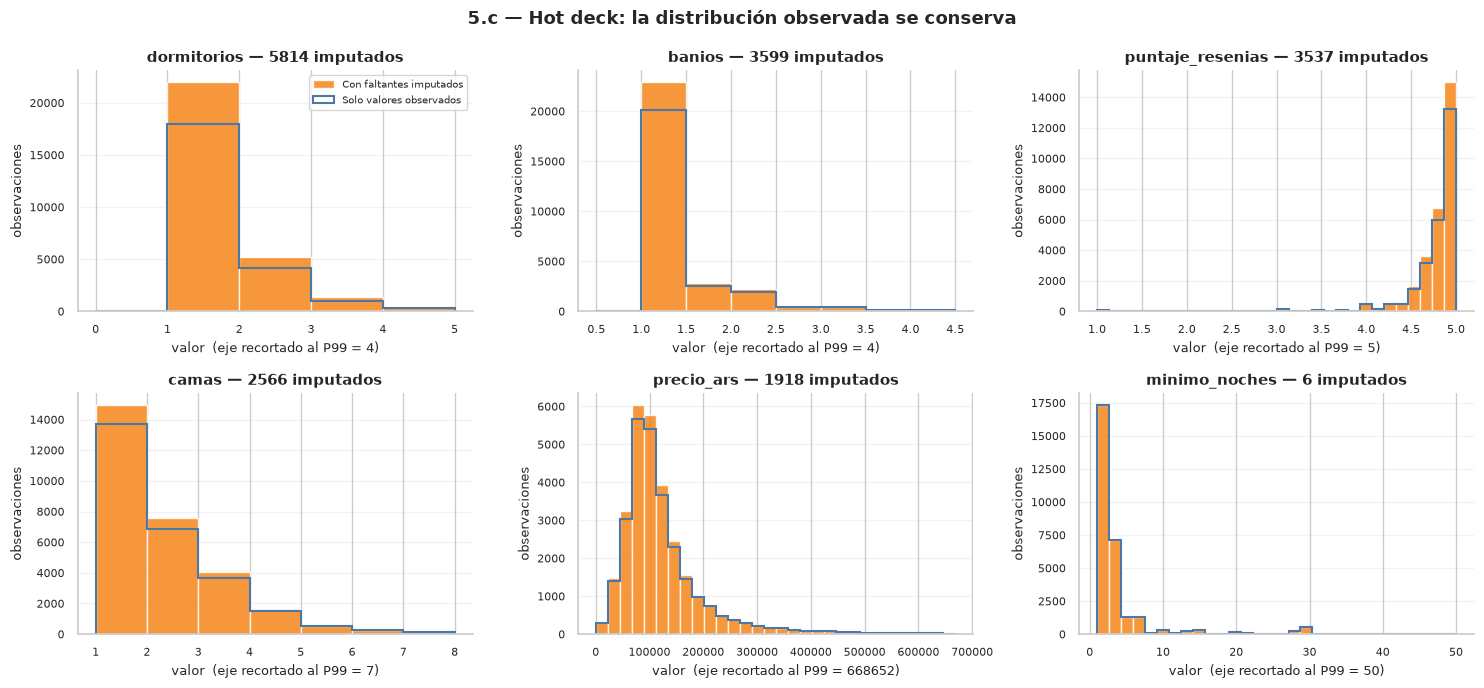

In [37]:
# --- 5.c Efecto sobre los estadísticos, comparado con 5.b ---
# En 5.b todos los faltantes de una columna recibían el mismo valor, así que el
# desvío se reducía. Acá cada uno recibe un valor real distinto: el desvío
# apenas cambia, salvo en dormitorios, que es el caso que se mira enseguida.
comparacion_5c = []
for columna in columnas_5b:
    desvio_original = alquileres[columna].std()
    desvio_5b = alquileres_central[columna].std()
    desvio_5c = alquileres_hotdeck[columna].std()
    comparacion_5c.append({
        "Desvío original": desvio_original,
        "Desvío 5.b (mediana)": desvio_5b,
        "Desvío 5.c (hot deck)": desvio_5c,
        "% 5.b": 100 * (desvio_5b / desvio_original - 1),
        "% 5.c": 100 * (desvio_5c / desvio_original - 1),
    })
comparacion_5c = pd.DataFrame(comparacion_5c, index=columnas_5b)
display(comparacion_5c.round(2))

# El único caso donde el desvío sube: se comparan los donantes disponibles en
# cada estrato contra la cantidad de receptores que hay que cubrir.
detalle_dormitorios = pd.DataFrame({
    "Filas": alquileres.groupby(ESTRATO_HOT_DECK, observed=True).size(),
    "Donantes": alquileres.groupby(ESTRATO_HOT_DECK, observed=True)["dormitorios"].count(),
    "Receptores": alquileres.loc[alquileres["dormitorios"].isna()]
                           .groupby(ESTRATO_HOT_DECK, observed=True).size(),
    "Media donantes": alquileres.groupby(ESTRATO_HOT_DECK, observed=True)["dormitorios"].mean(),
    "Desvío donantes": alquileres.groupby(ESTRATO_HOT_DECK, observed=True)["dormitorios"].std(),
    "Máximo donante": alquileres.groupby(ESTRATO_HOT_DECK, observed=True)["dormitorios"].max(),
})
print("dormitorios: donantes disponibles en cada estrato")
display(detalle_dormitorios.round(2))


def bordes_histograma(observados, tope):
    """Un intervalo por valor en variables de conteo; 31 intervalos si es continua."""
    unicos = np.sort(observados.unique())
    if len(unicos) <= 30:
        visibles = unicos[unicos <= tope]
        paso = float(np.diff(visibles).min()) if len(visibles) > 1 else 1.0
        return np.append(visibles, visibles[-1] + paso)
    return np.linspace(observados.min(), tope, 31)


# Gráfico: a diferencia de 5.b, la barra naranja ya no forma un pico sobre un
# único valor, sino que acompaña la forma de la distribución observada.
fig, ejes = plt.subplots(2, 3, figsize=(15, 7))
for ax, columna in zip(ejes.flat, columnas_5b):
    observados = alquileres[columna].dropna()
    completados = alquileres_hotdeck[columna]
    tope = float(observados.quantile(0.99))
    bordes = bordes_histograma(observados, tope)

    ax.hist(completados, bins=bordes, color=COLOR_SUAVIZADA, alpha=0.85,
            edgecolor="white", label="Con faltantes imputados")
    ax.hist(observados, bins=bordes, histtype="step", color=COLOR_ORIGINAL,
            linewidth=1.5, label="Solo valores observados")

    ax.set_title(f"{columna} — {int(alquileres[columna].isna().sum())} imputados",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel(f"valor  (eje recortado al P99 = {tope:g})", fontsize=9)
    ax.set_ylabel("observaciones", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

ejes.flat[0].legend(frameon=True, fontsize=7.5)
fig.suptitle("5.c — Hot deck: la distribución observada se conserva",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


**Qué se hizo.** A cada una de las 17.440 celdas faltantes se le copió el valor de otra fila del dataset del mismo `tipo_habitacion`, sorteada al azar entre las que sí tenían el dato. Después de la imputación no queda ningún faltante (0 celdas, igual que en 5.b).

La diferencia central con 5.b aparece en la tabla de valores imputados: en 5.b **todas** las filas de una columna recibían el **mismo** valor, así que había un único valor imputado por columna. Acá cada fila recibe uno distinto, tomado de un donante real: 19 valores distintos en `dormitorios`, 106 en `puntaje_resenias` y 1.549 en `precio_ars`. Eso es lo que se ve en el gráfico: la barra naranja ya **no forma un pico** sobre un único valor, sino que acompaña la forma de la distribución observada.

**El efecto sobre la dispersión.** Comparando el desvío estándar de cada versión contra el original:

- `banios` −1,25 %, `camas` −0,80 %, `precio_ars` +0,24 %, `puntaje_resenias` −0,08 %, `minimo_noches` −0,01 %
- `dormitorios` **+28,11 %**

En cinco de las seis variables el desvío queda prácticamente igual, muy lejos del recorte de hasta −9,06 % que producía la imputación por la mediana. Es lo esperable: como los valores imputados son **valores reales** de la columna, no alteran la forma de la distribución, solo la completan.

**La excepción: `dormitorios`.** Es el caso más interesante del punto, porque el desvío **sube**. La tabla de donantes muestra por qué: dentro de `Private room` hay 649 donantes con un desvío de 2,99 (y un máximo de 31), muy por encima del desvío de la columna completa (0,90). Como los 1.941 receptores de ese estrato copian valores de esa cantera, el resultado queda más disperso que el original.

Ahí se ve una propiedad del método que conviene retener: **el hot deck no reproduce la distribución de la columna, reproduce la del estrato del donante**. Si el estrato es internamente heterogéneo, la imputación hereda esa heterogeneidad. Y `tipo_habitacion` lo es: al mirar los casos extremos aparecen avisos como un *Private room* en un hotel, con `capacidad = 2`, que informa `dormitorios = 31`; es decir, filas donde el campo parece registrar los dormitorios **de toda la propiedad** y no de la unidad. El estrato agrupa esos casos con cuartos que informan 1, y el donante sorteado puede ser cualquiera de los dos.

**Una advertencia sobre `puntaje_resenias`.** Vale la misma salvedad que en 5.b: el faltante es **estructural** (aparece en los avisos sin reseñas), así que copiar el puntaje de otro aviso sigue siendo **fabricar** un dato que no existe. El hot deck lo hace más creíble que la mediana —porque el valor es real y varía—, pero no lo vuelve correcto.

**Limitación del método.** El estrato usado (`tipo_habitacion`, 4 grupos) es **grueso**: no distingue barrio, capacidad ni precio, así que dos avisos del mismo estrato pueden ser muy distintos —basta ver `precio_ars`, donde el donante más caro imputado llegó a $1.410.250—. En 5.d se define un **criterio de similitud** más fino y se compara el resultado contra `KNNImputer`.


### 5.d Una función `hot_deck` con criterio de similitud propio

5.c usó la variante más simple del hot deck: donante **al azar** dentro de un estrato, con un estrato grueso (`tipo_habitacion`, 4 grupos). Este punto pide dar un paso más: **implementar la función** y **definir explícitamente el criterio de similitud** para este dataset, para después comparar el resultado con `KNNImputer`.

**El criterio de similitud.** Todo el método depende de qué significa "parecido", así que conviene escribirlo antes de programarlo. Para `alquileres.csv` se definen dos condiciones:

1. **Bloque.** El donante tiene que estar en el **mismo barrio** y ser del **mismo tipo de habitación**. Son las dos variables categóricas que en 5.a aparecieron asociadas a los faltantes y las que definen el contexto del aviso: un departamento en Palermo no es comparable con un cuarto en Villa Lugano.
2. **Distancia.** Entre los candidatos del bloque se elige el **más cercano** en las variables numéricas que están **completas**: `capacidad`, `cantidad_resenias`, `noches_ocupadas_anio`, `latitud` y `longitud`. Se usan solo las completas para que la distancia siempre se pueda calcular, y se **estandarizan** para que ninguna pese más que otra solo por su escala.

Si un bloque se queda sin donantes, el criterio se relaja en cascada: primero se suelta el barrio, después el tipo de habitación y, como último recurso, la columna entera. La función informa en qué nivel se resolvió cada fila, para que esa relajación no quede escondida.

Con `k = 1` se copia **un solo donante**, que es el hot deck clásico; con `k > 1` se promedian los `k` más cercanos, que es lo que hace `KNNImputer`. Se deja `k = 1` por defecto y se usa `k = 5` más adelante para ver qué aporta el promedio.

**Una diferencia importante con `KNNImputer`.** El módulo de scikit-learn trabaja sobre una **matriz numérica**, así que no puede recibir `barrio` ni `tipo_habitacion` tal como están: el bloque, que es la parte más específica de nuestro criterio, no tiene equivalente directo. Para que la comparación sea razonable se le pasan las once variables numéricas estandarizadas —incluidas `latitud` y `longitud`, para que al menos tenga alguna noción de ubicación—.


In [38]:
# --- 5.d Función hot_deck con un criterio de similitud explícito ---
# El criterio definido para alquileres.csv tiene dos partes:
#   1. BLOQUE: el donante tiene que estar en el mismo barrio y ser del mismo tipo
#      de habitación. Son las dos variables categóricas que en 5.a aparecieron
#      asociadas a los faltantes y las que en 5.c se usaron como estrato.
#   2. DISTANCIA: entre los candidatos del bloque se elige el más parecido en las
#      variables numéricas que están completas, estandarizadas para que ninguna
#      pese más que otra solo por su escala.
# Si un bloque se queda sin donantes el criterio se relaja: primero se suelta el
# barrio, después el tipo de habitación y, como último recurso, se usa la columna
# entera. La función devuelve en qué nivel se resolvió cada fila.
from scipy.spatial import cKDTree

VARIABLES_DISTANCIA = ("capacidad", "cantidad_resenias", "noches_ocupadas_anio",
                       "latitud", "longitud")


def hot_deck(datos, columna, bloque=("barrio", "tipo_habitacion"),
             numericas=VARIABLES_DISTANCIA, k=1):
    """Imputa los faltantes de `columna` copiando el valor de un donante.

    Devuelve (valores, nivel): la columna completa y una serie que indica con qué
    nivel del bloque se resolvió cada fila imputada.
    Con k = 1 (por defecto) se copia el donante más cercano, que es el hot deck
    clásico; con k > 1 se promedian los k donantes más cercanos.
    """
    valores = datos[columna].to_numpy()
    z = ((datos[list(numericas)] - datos[list(numericas)].mean())
         / datos[list(numericas)].std()).to_numpy()

    resultado = valores.copy()
    nivel = pd.Series(index=datos.index, dtype=object)

    faltantes = np.flatnonzero(pd.isna(valores))
    tiene_dato = np.flatnonzero(~pd.isna(valores))

    for claves in (bloque, bloque[1:], None):
        if len(faltantes) == 0:
            break
        if claves is None:
            grupos_receptores, grupos_donantes = {None: faltantes}, {None: tiene_dato}
            etiqueta = "columna entera"
        else:
            sub = datos.iloc[faltantes]
            grupos_receptores = {clave: faltantes[pos] for clave, pos in
                                 sub.groupby(list(claves), observed=True).indices.items()}
            sub = datos.iloc[tiene_dato]
            grupos_donantes = {clave: tiene_dato[pos] for clave, pos in
                               sub.groupby(list(claves), observed=True).indices.items()}
            etiqueta = " + ".join(claves)

        sin_resolver = []
        for clave, receptores in grupos_receptores.items():
            donantes = grupos_donantes.get(clave)
            if donantes is None or len(donantes) == 0:
                sin_resolver.extend(receptores)
                continue
            # El árbol ordena los donantes del bloque por cercanía a cada receptor.
            kk = min(k, len(donantes))
            _, posicion = cKDTree(z[donantes]).query(z[receptores], k=kk)
            if kk == 1:
                resultado[receptores] = valores[donantes[np.atleast_1d(posicion)]]
            else:
                resultado[receptores] = valores[
                    donantes[np.atleast_2d(posicion)]].mean(axis=1)
            nivel.iloc[receptores] = etiqueta

        faltantes = np.asarray(sin_resolver, dtype=int)

    return pd.Series(resultado, index=datos.index, name=columna), nivel


alquileres_hotdeck_vecino = alquileres.copy()
nivel_hotdeck = {}
for columna in columnas_5b:
    valores, nivel = hot_deck(alquileres, columna)
    alquileres_hotdeck_vecino[columna] = valores
    nivel_hotdeck[columna] = nivel

print("Nivel del bloque en el que se resolvió cada fila imputada:")
tabla_niveles = pd.DataFrame({columna: nivel_hotdeck[columna].value_counts()
                              for columna in columnas_5b}).fillna(0).astype(int)
display(tabla_niveles)

print("Celdas faltantes en las seis columnas, después:",
      int(alquileres_hotdeck_vecino[columnas_5b].isna().sum().sum()))


Nivel del bloque en el que se resolvió cada fila imputada:


,dormitorios,banios,puntaje_resenias,camas,precio_ars,minimo_noches
barrio + tipo_habitacion,5778,3598,3526,2565,1916,6
tipo_habitacion,36,1,11,1,2,0


Celdas faltantes en las seis columnas, después: 0


In [39]:
# --- 5.d Comparación con KNNImputer ---
# KNNImputer trabaja sobre una matriz numérica, así que no puede recibir barrio ni
# tipo_habitacion tal como están: el bloque del criterio anterior no tiene
# equivalente directo. Se le pasan las once variables numéricas estandarizadas
# (la guía de clase mostró que sin estandarizar precio_ars se lleva toda la
# distancia por su escala) y promedia los 5 vecinos más cercanos.
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler

NUMERICAS_KNN = ["capacidad", "dormitorios", "banios", "camas", "precio_ars",
                 "minimo_noches", "cantidad_resenias", "puntaje_resenias",
                 "latitud", "longitud", "noches_ocupadas_anio"]

escala = StandardScaler().fit(alquileres[NUMERICAS_KNN])
alquileres_knn = alquileres.copy()
alquileres_knn[NUMERICAS_KNN] = escala.inverse_transform(
    KNNImputer(n_neighbors=5, weights="distance")
    .fit_transform(escala.transform(alquileres[NUMERICAS_KNN])))

print("Celdas faltantes en todo el dataset, después:",
      int(alquileres_knn.isna().sum().sum()))

comparacion_5d = []
for columna in columnas_5b:
    original = alquileres[columna].std()
    comparacion_5d.append({
        "Desvío original": original,
        "Desvío 5.d (hot deck)": alquileres_hotdeck_vecino[columna].std(),
        "Desvío KNNImputer": alquileres_knn[columna].std(),
        "% 5.d": 100 * (alquileres_hotdeck_vecino[columna].std() / original - 1),
        "% KNN": 100 * (alquileres_knn[columna].std() / original - 1),
    })
comparacion_5d = pd.DataFrame(comparacion_5d, index=columnas_5b)
print("\nEfecto de cada método sobre el desvío estándar:")
display(comparacion_5d.round(2))


Celdas faltantes en todo el dataset, después: 0

Efecto de cada método sobre el desvío estándar:


,Desvío original,Desvío 5.d (hot deck),Desvío KNNImputer,% 5.d,% KNN
dormitorios,0.90,1.28,0.85,41.65,-6.40
banios,0.67,0.67,0.66,-0.11,-2.92
puntaje_resenias,0.36,0.44,0.36,21.36,-1.15
camas,1.54,1.53,1.51,-0.55,-1.62
precio_ars,115303.02,114964.67,113004.71,-0.29,-1.99
minimo_noches,18.96,18.96,18.96,-0.01,-0.01


Celdas faltantes en el dataset enmascarado: 33357 (los faltantes originales más los retenidos a propósito)



Error absoluto medio sobre los valores retenidos, en % del desvío de cada
columna (más chico = mejor):


,Mediana,hot_deck k=1,hot_deck k=5,KNNImputer
dormitorios,35.8,28.5,28.4,25.8
banios,33.1,35.3,34.6,32.8
puntaje_resenias,48.4,65.2,55.3,55.5
camas,59.2,38.8,33.9,33.5
precio_ars,50.6,54.1,44.2,43.7
minimo_noches,15.7,24.5,22.2,26.9


  dormitorios        mejor método: KNNImputer
  banios             mejor método: KNNImputer
  puntaje_resenias   mejor método: Mediana
  camas              mejor método: KNNImputer
  precio_ars         mejor método: KNNImputer
  minimo_noches      mejor método: Mediana


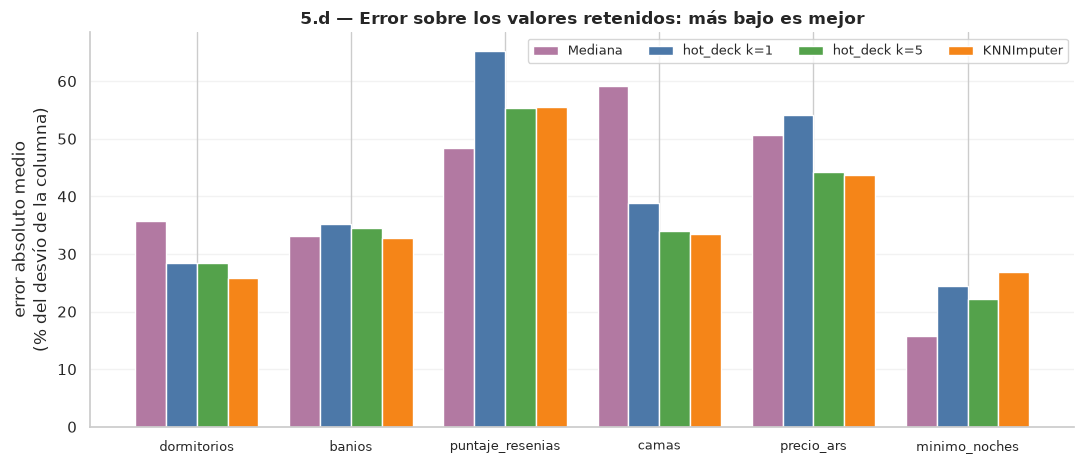

In [40]:
# --- 5.d ¿Cuál imputa mejor? Validación con valores retenidos ---
# Mirando el dataset no hay forma de saber si una imputación acertó, porque los
# valores que faltan no se ven. La salida es simular el problema: se oculta el
# 10 % de los valores que SÍ están observados, se imputan con cada método y se
# compara contra el valor verdadero, que en este caso conocemos.
SEMILLA_VALIDACION = 2026
rng_validacion = np.random.default_rng(SEMILLA_VALIDACION)

enmascarado = alquileres.copy()
verdaderos = {}
for columna in columnas_5b:
    observados = alquileres.index[alquileres[columna].notna()]
    ocultar = rng_validacion.choice(observados.to_numpy(),
                                    size=int(0.10 * len(observados)), replace=False)
    verdaderos[columna] = alquileres.loc[ocultar, columna]
    enmascarado.loc[ocultar, columna] = np.nan

print("Celdas faltantes en el dataset enmascarado:",
      int(enmascarado[columnas_5b].isna().sum().sum()),
      "(los faltantes originales más los retenidos a propósito)")

# 1) Donante más cercano (k = 1)  2) promedio de los 5 más cercanos (k = 5)
hotdeck_k1 = enmascarado.copy()
hotdeck_k5 = enmascarado.copy()
for columna in columnas_5b:
    hotdeck_k1[columna] = hot_deck(enmascarado, columna, k=1)[0]
    hotdeck_k5[columna] = hot_deck(enmascarado, columna, k=5)[0]

# 3) KNNImputer, reajustado sobre el dataset enmascarado
escala_validacion = StandardScaler().fit(enmascarado[NUMERICAS_KNN])
knn_validacion = enmascarado.copy()
knn_validacion[NUMERICAS_KNN] = escala_validacion.inverse_transform(
    KNNImputer(n_neighbors=5, weights="distance")
    .fit_transform(escala_validacion.transform(enmascarado[NUMERICAS_KNN])))

# 4) La mediana, como línea de base: si un método no la supera, la complejidad
#    agregada no se está traduciendo en mejores valores.
filas_validacion = []
for columna in columnas_5b:
    real = verdaderos[columna]
    desvio = enmascarado[columna].std()
    filas_validacion.append({
        "Mediana": 100 * (enmascarado[columna].median() - real).abs().mean() / desvio,
        "hot_deck k=1": 100 * (hotdeck_k1.loc[real.index, columna] - real).abs().mean() / desvio,
        "hot_deck k=5": 100 * (hotdeck_k5.loc[real.index, columna] - real).abs().mean() / desvio,
        "KNNImputer": 100 * (knn_validacion.loc[real.index, columna] - real).abs().mean() / desvio,
    })

validacion_5d = pd.DataFrame(filas_validacion, index=columnas_5b)
print("\nError absoluto medio sobre los valores retenidos, en % del desvío de cada")
print("columna (más chico = mejor):")
display(validacion_5d.round(1))

for columna in columnas_5b:
    print(f"  {columna:18s} mejor método: {validacion_5d.loc[columna].idxmin()}")

# El mismo resultado, en un gráfico de barras agrupadas.
colores_metodos = {"Mediana": "#B279A2", "hot_deck k=1": COLOR_ORIGINAL,
                   "hot_deck k=5": "#54A24B", "KNNImputer": COLOR_SUAVIZADA}
posiciones = np.arange(len(columnas_5b))
fig, ax = plt.subplots(figsize=(11, 4.8))
for i, (metodo, color) in enumerate(colores_metodos.items()):
    ax.bar(posiciones + (i - 1.5) * 0.2, validacion_5d[metodo], width=0.2,
           color=color, edgecolor="white", label=metodo)

ax.set_xticks(posiciones, columnas_5b, fontsize=9)
ax.set_ylabel("error absoluto medio\n(% del desvío de la columna)")
ax.set_title("5.d — Error sobre los valores retenidos: más bajo es mejor",
             fontsize=12, fontweight="bold")
ax.legend(frameon=True, ncols=4, fontsize=9)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


In [41]:
# --- 5.d Por qué el hot deck queda mal parado en puntaje_resenias ---
# Todos los avisos a los que les falta el puntaje tienen cantidad_resenias = 0.
# Como cantidad_resenias está entre las variables de la distancia, el donante más
# cercano termina siendo el aviso con MENOS reseñas... y el puntaje de un aviso
# con pocas reseñas es mucho más variable que el de uno con muchas.
imputado_5d = alquileres_hotdeck_vecino.loc[alquileres["puntaje_resenias"].isna(),
                                            "puntaje_resenias"]
print("puntaje_resenias")
print(f"  desvío de los valores observados: {alquileres['puntaje_resenias'].std():.3f}")
print(f"  desvío de los valores imputados : {imputado_5d.std():.3f}")
print("\nDesvío del puntaje según la cantidad de reseñas (valores observados):")
for desde, hasta in [(1, 2), (3, 4), (5, 9), (10, 19), (20, None)]:
    seleccion = (alquileres["puntaje_resenias"].notna()
                 & alquileres["cantidad_resenias"].ge(desde))
    if hasta is not None:
        seleccion &= alquileres["cantidad_resenias"].le(hasta)
    grupo = alquileres.loc[seleccion, "puntaje_resenias"]
    etiqueta = f"{desde} a {hasta}" if hasta is not None else f"{desde} o más"
    print(f"  {etiqueta:>9s} reseñas: n = {len(grupo):6d}   "
          f"media = {grupo.mean():.3f}   desvío = {grupo.std():.3f}")


puntaje_resenias
  desvío de los valores observados: 0.364
  desvío de los valores imputados : 0.794

Desvío del puntaje según la cantidad de reseñas (valores observados):
      1 a 2 reseñas: n =   2766   media = 4.610   desvío = 0.867
      3 a 4 reseñas: n =   1936   media = 4.703   desvío = 0.484
      5 a 9 reseñas: n =   3190   media = 4.755   desvío = 0.315
    10 a 19 reseñas: n =   3996   media = 4.787   desvío = 0.217
   20 o más reseñas: n =  14013   media = 4.826   desvío = 0.140


**Qué se implementó.** La función `hot_deck` recorre los faltantes, los agrupa por bloque (`barrio` + `tipo_habitacion`) y a cada uno le copia el valor del donante más cercano en las cinco variables numéricas completas. La tabla de niveles muestra que la relajación casi no hizo falta: **17.389 de las 17.440 celdas** (el 99,71 %) se resolvieron dentro del bloque, 51 filas cayeron al nivel `tipo_habitacion` y ninguna necesitó la columna entera. Es una buena señal del criterio: los bloques casi siempre tienen donantes disponibles. Después de la imputación no queda ningún faltante.

**El efecto sobre la dispersión.** El hot deck deja el desvío prácticamente intacto en cuatro de las seis variables (`banios` −0,11 %, `camas` −0,55 %, `precio_ars` −0,29 %, `minimo_noches` −0,01 %) pero lo **sube mucho** en las otras dos: `dormitorios` **+41,65 %** y `puntaje_resenias` **+21,36 %**. `KNNImputer`, en cambio, siempre lo reduce un poco (entre −0,01 % y −6,40 %). Ese contraste es el primer indicio de que los dos métodos no están haciendo lo mismo.

**Qué método imputa mejor.** El desvío no dice si la imputación *acertó*; para eso está la validación con valores retenidos, que oculta el 10 % de los datos observados, imputa y compara contra la verdad. El error resultante (en % del desvío de cada columna, más chico es mejor):

- `dormitorios`: KNNImputer 25,8 · hot_deck k=5 28,4 · hot_deck k=1 28,5 · **mediana 35,8**
- `banios`: KNNImputer 32,8 · **mediana 33,1** · hot_deck k=5 34,6 · hot_deck k=1 35,3
- `puntaje_resenias`: **mediana 48,4** · hot_deck k=5 55,3 · KNNImputer 55,5 · hot_deck k=1 65,2
- `camas`: KNNImputer 33,5 · hot_deck k=5 33,9 · hot_deck k=1 38,8 · **mediana 59,2**
- `precio_ars`: KNNImputer 43,7 · hot_deck k=5 44,2 · **mediana 50,6** · hot_deck k=1 54,1
- `minimo_noches`: **mediana 15,7** · hot_deck k=5 22,2 · hot_deck k=1 24,5 · KNNImputer 26,9

Tres lecturas de esa tabla:

1. **`KNNImputer` gana en cuatro de las seis.** La razón no está en el criterio de similitud, que es razonable, sino en dos diferencias concretas: usa **once variables** en la distancia en vez de cinco y **promedia cinco vecinos** en vez de copiar uno. Que `hot_deck k=5` se acerque tanto a KNN en `camas` (33,9 contra 33,5), `precio_ars` (44,2 contra 43,7) y `dormitorios` (28,4 contra 25,8) confirma que buena parte de la ventaja viene del **promedio**, no de las variables.
2. **La mediana gana en las dos columnas donde los métodos "inteligentes" no sirven.** En `puntaje_resenias` y `minimo_noches` el valor casi no varía (medianas 4,87 y 2), así que un valor fijo acierta más seguido que un donante elegido. Es un recordatorio de que **la complejidad solo paga cuando la variable realmente depende de los predictores**.
3. **Aun así, el hot deck mejora bastante sobre la mediana** en `camas` (38,8 contra 59,2) y en `dormitorios` (28,5 contra 35,8), que son justamente las variables donde la cantidad de camas o cuartos depende del tamaño del aviso.

**Por qué el hot deck falla en `puntaje_resenias`.** Vale mirarlo de cerca, porque es un efecto del criterio y no del azar. Todos los avisos a los que les falta el puntaje tienen `cantidad_resenias = 0` (es un faltante estructural). Como `cantidad_resenias` **está entre las variables de la distancia**, el donante más cercano resulta ser siempre el aviso con **menos reseñas** —y el puntaje de un aviso con pocas reseñas es mucho más variable que el de uno con muchas: desvío 0,867 con 1 o 2 reseñas contra 0,140 con 20 o más—. El criterio, sin proponérselo, elige a los donantes más ruidosos: por eso los valores imputados tienen desvío 0,794 cuando los observados tienen 0,364, y por eso promediar cinco vecinos mejora el resultado.

La lección es general: **el criterio de similitud interactúa con el mecanismo de faltante**. Si una variable ayuda a definir *quién* tiene el dato faltante, usarla también en la distancia puede empujar la elección hacia los donantes menos confiables.

**El caso de `dormitorios`** tiene la misma raíz que en 5.c: es un campo con inconsistencias de carga (avisos de una habitación que informan los dormitorios de toda la propiedad), así que cualquier método que copie valores reales de otros avisos hereda esa dispersión. Un criterio más fino no lo arregla, porque el problema está en el dato y no en la búsqueda del donante.


### 5.e Imputación por regresión

Los tres métodos anteriores comparten algo: el valor imputado es un valor que **existe** en el dataset. La mediana es un valor observado, y el hot deck copia el valor de otro aviso. La imputación por regresión rompe con eso: en vez de copiar, **calcula**.

La idea es ajustar un modelo que prediga la variable faltante a partir de las demás, y usar esa predicción como valor imputado. Con una **regresión lineal**, el modelo busca la combinación de las predictoras que mejor se aproxima a la variable objetivo, y después esa misma fórmula se evalúa en las filas donde el dato falta. La calidad del ajuste se mide con el **R²**, que indica qué proporción de la variación de la variable alcanza a explicar el modelo (1 sería un ajuste perfecto y 0, ninguno).

**Qué variables pueden ser predictoras.** Acá aparece una restricción práctica que condiciona todo el método: para imputar una fila, sus predictoras tienen que estar **presentes en esa fila**. Si se usaran las otras cinco columnas con faltantes, casi no quedarían filas utilizables:

- `camas`: 345 de 2.566 faltantes
- `precio_ars`: 292 de 1.918
- `banios`: 1.053 de 3.599

Por eso se usan solo las variables **completas**: `capacidad`, `cantidad_resenias`, `noches_ocupadas_anio`, `latitud` y `longitud`, más `tipo_habitacion` y `superanfitrion` convertidas en **variables indicadoras** (una columna de 0 y 1 por categoría). Esa conversión es la forma de darle una variable categórica a un modelo numérico: no se puede multiplicar un barrio por un coeficiente, pero sí una columna que vale 1 cuando el aviso es de ese barrio.

**Dos decisiones que conviene dejar registradas.** La primera: ¿vale la pena agregar los 47 barrios como indicadoras? Se prueba comparando el R² y se decide con ese resultado, en vez de darlo por sentado. La segunda: una regresión lineal no sabe de límites y puede predecir un precio negativo, así que se aplica un **piso** en el mínimo observado de cada columna, informando a cuántos valores hubo que corregir.

El resultado se guarda en una copia (`alquileres_regresion`), como en los métodos anteriores, para poder comparar todos entre sí en 5.f.


In [42]:
# --- 5.e Imputación por regresión ---
# A diferencia de 5.b y 5.c, acá el valor imputado NO es un valor que exista en el
# dataset: se calcula con un modelo. Se ajusta una regresión lineal por columna y
# se evalúa esa misma fórmula en las filas donde el dato falta.
#
# Las predictoras son las variables que están COMPLETAS, porque para imputar una
# fila sus predictoras tienen que estar presentes en esa fila: si se usaran las
# otras cinco columnas con faltantes casi no quedarían filas utilizables.
# Las categóricas entran como variables indicadoras (una columna de 0/1 por
# categoría), que es la forma de darle categorías a un modelo numérico.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

SEMILLA_REGRESION = 2026
PREDICTORAS_NUMERICAS = ["capacidad", "cantidad_resenias", "noches_ocupadas_anio",
                         "latitud", "longitud"]


def matriz_diseno(datos, con_barrio=False):
    """Tabla de predictoras: las numéricas completas y las categóricas como
    variables indicadoras (una columna de 0/1 por categoría)."""
    partes = [
        datos[PREDICTORAS_NUMERICAS],
        pd.get_dummies(datos["tipo_habitacion"], prefix="tipo_habitacion",
                       drop_first=True, dtype=float),
        pd.get_dummies(datos["superanfitrion"], prefix="superanfitrion",
                       drop_first=True, dtype=float),
    ]
    if con_barrio:
        partes.append(pd.get_dummies(datos["barrio"], prefix="barrio",
                                     drop_first=True, dtype=float))
    return pd.concat(partes, axis=1)


# ¿Vale la pena agregar los 47 barrios? Se mide el R² sobre un 25 % de los avisos
# que el modelo no vio durante el ajuste, para no reportar un número inflado.
comparacion_barrio = []
for columna in columnas_5b:
    fila = {"columna": columna}
    for etiqueta, con_barrio in (("Sin barrio", False), ("Con barrio", True)):
        diseno = matriz_diseno(alquileres, con_barrio)
        objetivo = alquileres[columna]
        observado = objetivo.notna()
        entra, prueba, y_entra, y_prueba = train_test_split(
            diseno[observado], objetivo[observado], test_size=0.25,
            random_state=SEMILLA_REGRESION)
        modelo = LinearRegression().fit(entra, y_entra)
        fila[etiqueta] = r2_score(y_prueba, modelo.predict(prueba))
    comparacion_barrio.append(fila)

comparacion_barrio = pd.DataFrame(comparacion_barrio).set_index("columna")
print("R² sobre el 25 % de avisos que el modelo no vio al ajustarse:")
display(comparacion_barrio.round(3))

# Con eso se adopta el modelo SIN barrio: agregarlo casi no cambia el R² y
# multiplica la cantidad de columnas del modelo.
alquileres_regresion = alquileres.copy()
resumen_5e = []
for columna in columnas_5b:
    diseno = matriz_diseno(alquileres)
    objetivo = alquileres[columna]
    observado = objetivo.notna()

    entra, prueba, y_entra, y_prueba = train_test_split(
        diseno[observado], objetivo[observado], test_size=0.25,
        random_state=SEMILLA_REGRESION)
    r2_prueba = r2_score(y_prueba, LinearRegression().fit(entra, y_entra).predict(prueba))

    # El modelo definitivo se reajusta con TODOS los avisos que tienen el dato,
    # que es la información disponible para imputar.
    modelo = LinearRegression().fit(diseno[observado], objetivo[observado])
    predicho = pd.Series(modelo.predict(diseno[~observado]),
                         index=objetivo[~observado].index)

    # Un modelo lineal no sabe de límites: en precio_ars predice precios negativos.
    # Se aplica un piso en el mínimo observado de la columna para no introducir
    # valores imposibles, y se informa a cuántos valores hubo que corregir.
    minimo_observado = objetivo[observado].min()
    bajo_el_piso = int((predicho < minimo_observado).sum())
    predicho = predicho.clip(lower=minimo_observado)

    alquileres_regresion.loc[~observado, columna] = predicho
    resumen_5e.append({
        "Faltantes imputados": int((~observado).sum()),
        "R² (ajuste)": r2_prueba,
        "Desvío observado": objetivo[observado].std(),
        "Desvío predicho": predicho.std(),
        "Corregidos por el piso": bajo_el_piso,
    })

resumen_5e = pd.DataFrame(resumen_5e, index=columnas_5b)
print("Ajuste de cada regresión y dispersión de los valores que predice:")
display(resumen_5e.round(3))

print("Celdas faltantes en las seis columnas, antes:  ",
      int(alquileres[columnas_5b].isna().sum().sum()))
print("Celdas faltantes en las seis columnas, después:",
      int(alquileres_regresion[columnas_5b].isna().sum().sum()))


R² sobre el 25 % de avisos que el modelo no vio al ajustarse:


,Sin barrio,Con barrio
columna,,
dormitorios,0.352,0.353
banios,0.248,0.255
puntaje_resenias,0.077,0.074
camas,0.633,0.632
precio_ars,0.292,0.308
minimo_noches,0.009,0.007


Ajuste de cada regresión y dispersión de los valores que predice:


,Faltantes imputados,R² (ajuste),Desvío observado,Desvío predicho,Corregidos por el piso
dormitorios,5814,0.352,0.905,0.619,0
banios,3599,0.248,0.675,0.339,0
puntaje_resenias,3537,0.077,0.364,0.097,0
camas,2566,0.633,1.539,1.093,111
precio_ars,1918,0.292,115303.022,51347.895,9
minimo_noches,6,0.009,18.963,1.010,0


Celdas faltantes en las seis columnas, antes:   17440
Celdas faltantes en las seis columnas, después: 0


Efecto de la imputación por regresión sobre cada variable:


,Desvío observado,Desvío final,% del desvío,Mínimo observado,Mínimo final,Máximo observado,Máximo final
dormitorios,0.90,0.86,-5.32,0.0,0.0,31.0,31.0
banios,0.67,0.64,-4.68,0.5,0.5,22.0,22.0
puntaje_resenias,0.36,0.34,-5.32,1.0,1.0,5.0,5.0
camas,1.54,1.51,-2.18,1.0,1.0,50.0,50.0
precio_ars,115303.02,112253.43,-2.64,1216.0,1216.0,1499960.0,1499960.0
minimo_noches,18.96,18.96,-0.01,1.0,1.0,730.0,730.0



Valores imputados, a modo de ejemplo (la regresión no devuelve enteros):
  dormitorios    0.921, 1.956, 1.243, 2.284, 2.308
  banios         1.000, 1.575, 0.949, 0.946, 1.047
  camas          1.169, 3.556, 1.164, 1.217, 1.143


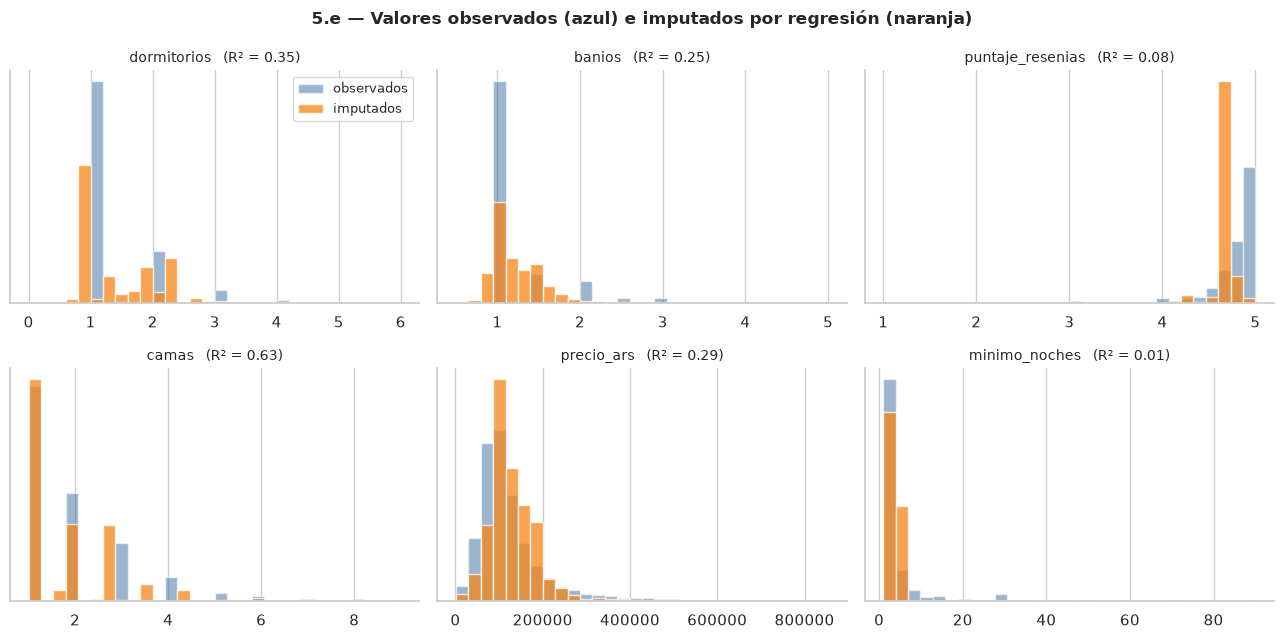

In [43]:
# --- 5.e Qué le pasa a la distribución de cada variable ---
efecto_5e = []
for columna in columnas_5b:
    observados = alquileres[columna].dropna()
    imputada = alquileres_regresion[columna]
    efecto_5e.append({
        "Desvío observado": observados.std(),
        "Desvío final": imputada.std(),
        "% del desvío": 100 * (imputada.std() / observados.std() - 1),
        "Mínimo observado": observados.min(),
        "Mínimo final": imputada.min(),
        "Máximo observado": observados.max(),
        "Máximo final": imputada.max(),
    })

efecto_5e = pd.DataFrame(efecto_5e, index=columnas_5b)
print("Efecto de la imputación por regresión sobre cada variable:")
display(efecto_5e.round(2))

# La regresión predice valores intermedios: el modelo no devuelve enteros.
print("\nValores imputados, a modo de ejemplo (la regresión no devuelve enteros):")
for columna in ("dormitorios", "banios", "camas"):
    ejemplos = alquileres_regresion.loc[alquileres[columna].isna(), columna].head(5)
    print(f"  {columna:14s} " + ", ".join(f"{v:.3f}" for v in ejemplos))

# La firma del método se ve en los histogramas: los valores observados (azul)
# ocupan un rango amplio, mientras que los predichos (naranja) se amontonan en una
# franja angosta. Es el efecto de compresión de la varianza.
fig, ejes = plt.subplots(2, 3, figsize=(13, 6.5))
for eje, columna in zip(ejes.ravel(), columnas_5b):
    observados = alquileres[columna].dropna()
    predichos = alquileres_regresion.loc[alquileres[columna].isna(), columna]
    # Se recorta el eje al percentil 99,5: si no, unas pocas observaciones muy
    # grandes aplastan el resto del gráfico contra el borde izquierdo.
    limite = np.percentile(observados, 99.5)
    eje.hist(observados, bins=30, range=(observados.min(), limite), density=True,
             color=COLOR_ORIGINAL, alpha=0.55, label="observados")
    eje.hist(predichos, bins=30, range=(observados.min(), limite), density=True,
             color=COLOR_SUAVIZADA, alpha=0.75, label="imputados")
    eje.set_title(f"{columna}   (R² = {resumen_5e.loc[columna, 'R² (ajuste)']:.2f})",
                  fontsize=10)
    eje.set_yticks([])
    eje.grid(axis="y", alpha=0.2)
    sns.despine(ax=eje)
ejes[0, 0].legend(frameon=True, fontsize=9)
fig.suptitle("5.e — Valores observados (azul) e imputados por regresión (naranja)",
             fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


**Qué se implementó.** Una regresión lineal por columna, ajustada sobre los avisos que tienen el dato y evaluada sobre los que no lo tienen. Las predictoras fueron las cinco variables completas más `tipo_habitacion` y `superanfitrion` como indicadoras, y el resultado quedó en `alquileres_regresion`, sin faltantes.

**Las predictoras se eligieron con evidencia, no por comodidad.** Usar las otras columnas con faltantes habría dejado a varios modelos casi sin filas para imputar (`camas`: 345 de 2.566; `precio_ars`: 292 de 1.918). Y agregar los 47 barrios como indicadoras no se justificó: el R² del holdout casi no cambia (`precio_ars` 0,292 → 0,308; `banios` 0,248 → 0,255; `dormitorios` 0,352 → 0,353) y en tres columnas incluso **empeora** un poco (`puntaje_resenias` 0,077 → 0,074; `camas` 0,633 → 0,632; `minimo_noches` 0,009 → 0,007). Ese empeoramiento es la señal de manual del **sobreajuste**: al agregar 47 columnas el modelo se ajusta mejor a los avisos que vio, pero generaliza peor a los que no vio. Se adoptó el modelo simple.

**Cuánto explica cada modelo.** El R² del holdout, de mayor a menor:

- `camas`: 0,633
- `dormitorios`: 0,352
- `precio_ars`: 0,292
- `banios`: 0,248
- `puntaje_resenias`: 0,077
- `minimo_noches`: 0,009

Se distinguen dos grupos. En `camas` y `dormitorios` el modelo captura buena parte de la variación, y tiene sentido: son medidas de tamaño, y `capacidad` es un buen indicador del tamaño de un aviso. En `puntaje_resenias` y `minimo_noches` el R² es prácticamente nulo, así que la regresión **no tiene con qué** predecirlas y lo que devuelve es poco más que un promedio disfrazado de fórmula. Es la misma conclusión a la que habíamos llegado por otros caminos en 5.c y en 5.d.

**La compresión de la varianza.** Es la firma de este método. Se ve mejor comparando el desvío de los valores **predichos** con el de los **observados** de la misma columna:

- `dormitorios`: 0,905 → 0,619 (−32 %)
- `banios`: 0,675 → 0,339 (−50 %)
- `puntaje_resenias`: 0,364 → 0,097 (−73 %)
- `camas`: 1,539 → 1,093 (−29 %)
- `precio_ars`: 115.303 → 51.348 (−55 %)
- `minimo_noches`: 18,963 → 1,010 (−95 %)

La razón es que una regresión predice siempre *el valor esperado dadas las predictoras*: no reproduce los casos extremos que la realidad sí tiene. Por eso los valores imputados se amontonan en una franja angosta alrededor del centro, que es lo que muestran los histogramas.

Conviene no confundir dos cosas, sin embargo. Ese desvío es el de **los valores imputados**, que son una minoría de cada columna (entre 6 y 5.814 de 29.438 filas). El efecto sobre la **columna completa** es mucho más suave: entre −0,01 % y −5,32 %. La compresión es fuerte en lo que se imputa y modesta en el conjunto.

**Dos consecuencias visibles del método.** La primera es que la regresión **no devuelve enteros**: `dormitorios` recibe valores como 0,921 o 1,956 y `banios` como 1,575. Es propio de un método que promedia en lugar de elegir, y no se corrige, pero conviene tenerlo presente porque son valores que ningún aviso real tiene. La segunda es que el modelo **puede predecir valores imposibles, y los predijo**: 111 valores de `camas` por debajo de 1 y 9 precios negativos en `precio_ars` (hasta −$30.543). Se aplicó el piso en el mínimo observado y quedaron corregidos.

**Cómo se ubica frente a los otros métodos.** El hot deck de 5.d tomaba prestado el valor de un aviso real; la regresión **fabrica** un valor que no existe en ninguna fila. Eso tiene una contra y una ventaja: pierde el realismo del donante real, pero gana cuando la variable efectivamente depende de las predictoras, porque aprovecha la relación de **todas** las filas a la vez en lugar de un solo vecino. La comparación numérica entre los cinco métodos queda para 5.f.


### 5.f Comparación de los métodos

Llegado este punto hay **cinco versiones** del mismo dataset, cada una con los faltantes reemplazados por un método distinto:

- **Mediana (5.b)**: un valor fijo por columna.
- **Hot deck por estrato (5.c)**: donante sorteado al azar dentro del mismo `tipo_habitacion`.
- **Hot deck por vecino (5.d)**: donante más cercano dentro de `barrio` + `tipo_habitacion`.
- **KNNImputer (5.d)**: promedio de los 5 vecinos más cercanos, sobre 11 variables estandarizadas.
- **Regresión (5.e)**: valor calculado por una regresión lineal.

Compararlas exige hacerse **dos preguntas distintas**, y conviene no mezclarlas:

1. **¿Qué tan fiel queda la distribución de la variable?** Si después se van a analizar varianzas, correlaciones o la forma de la distribución, importa cuánto la altera la imputación. Se mide con el desvío estándar de cada versión respecto del original: valores muy por debajo indican que la imputación **comprime** la variable, y valores muy por encima, que la **infla**.
2. **¿Qué tan cerca queda cada valor imputado del que debería haber?** Si el análisis usa los valores individuales, lo que importa es el acierto. Eso no se puede medir mirando el dataset —los valores que faltan no se ven—, así que se mide ocultando a propósito un 10 % de los datos **observados** y comparando contra el valor verdadero.

Las dos preguntas pueden dar respuestas distintas, y por eso se responden por separado. El dataset original (`alquileres`) es la referencia en ambas comparaciones.


In [44]:
# --- 5.f Las cinco versiones del dataset, una al lado de la otra ---
# Cada método ya produjo su propia copia del dataset. Acá se las junta para
# compararlas: entre ellas solo cambian las filas que cada método imputó.
VERSIONES_5F = {
    "Mediana (5.b)": alquileres_central,
    "Hot deck por estrato (5.c)": alquileres_hotdeck,
    "Hot deck por vecino (5.d)": alquileres_hotdeck_vecino,
    "KNNImputer (5.d)": alquileres_knn,
    "Regresión (5.e)": alquileres_regresion,
}

COLORES_5F = {
    "Mediana (5.b)": "#B279A2",
    "Hot deck por estrato (5.c)": "#4C78A8",
    "Hot deck por vecino (5.d)": "#54A24B",
    "KNNImputer (5.d)": "#F58518",
    "Regresión (5.e)": "#E45756",
}

# Primer eje de comparación: cómo queda la dispersión de cada variable.
# Negativo = la variable resulta menos dispersa que la original.
comparacion_5f = pd.DataFrame(
    {metodo: [100 * (datos[columna].std() / alquileres[columna].std() - 1)
              for columna in columnas_5b]
     for metodo, datos in VERSIONES_5F.items()},
    index=columnas_5b)
comparacion_5f.loc["Promedio |%|"] = comparacion_5f.abs().mean()

print("Cambio porcentual del desvío estándar respecto del dataset original:")
display(comparacion_5f.round(2))

# Los métodos también se distinguen por la variedad de valores que introducen.
print("Cantidad de valores distintos que imputa cada método (suma de las 6 columnas):")
for metodo, datos in VERSIONES_5F.items():
    distintos = sum(datos.loc[alquileres[columna].isna(), columna].nunique()
                    for columna in columnas_5b)
    print(f"  {metodo:28s} {distintos:6d}")


Cambio porcentual del desvío estándar respecto del dataset original:


,Mediana (5.b),Hot deck por estrato (5.c),Hot deck por vecino (5.d),KNNImputer (5.d),Regresión (5.e)
dormitorios,-9.06,28.11,41.65,-6.40,-5.32
banios,-5.61,-1.25,-0.11,-2.92,-4.68
puntaje_resenias,-5.85,-0.08,21.36,-1.15,-5.32
camas,-2.93,-0.80,-0.55,-1.62,-2.18
precio_ars,-3.12,0.24,-0.29,-1.99,-2.64
minimo_noches,-0.01,-0.01,-0.01,-0.01,-0.01
Promedio |%|,4.43,5.08,10.66,2.35,3.36


Cantidad de valores distintos que imputa cada método (suma de las 6 columnas):
  Mediana (5.b)                     6
  Hot deck por estrato (5.c)     1706
  Hot deck por vecino (5.d)      1610
  KNNImputer (5.d)              10258
  Regresión (5.e)               16946


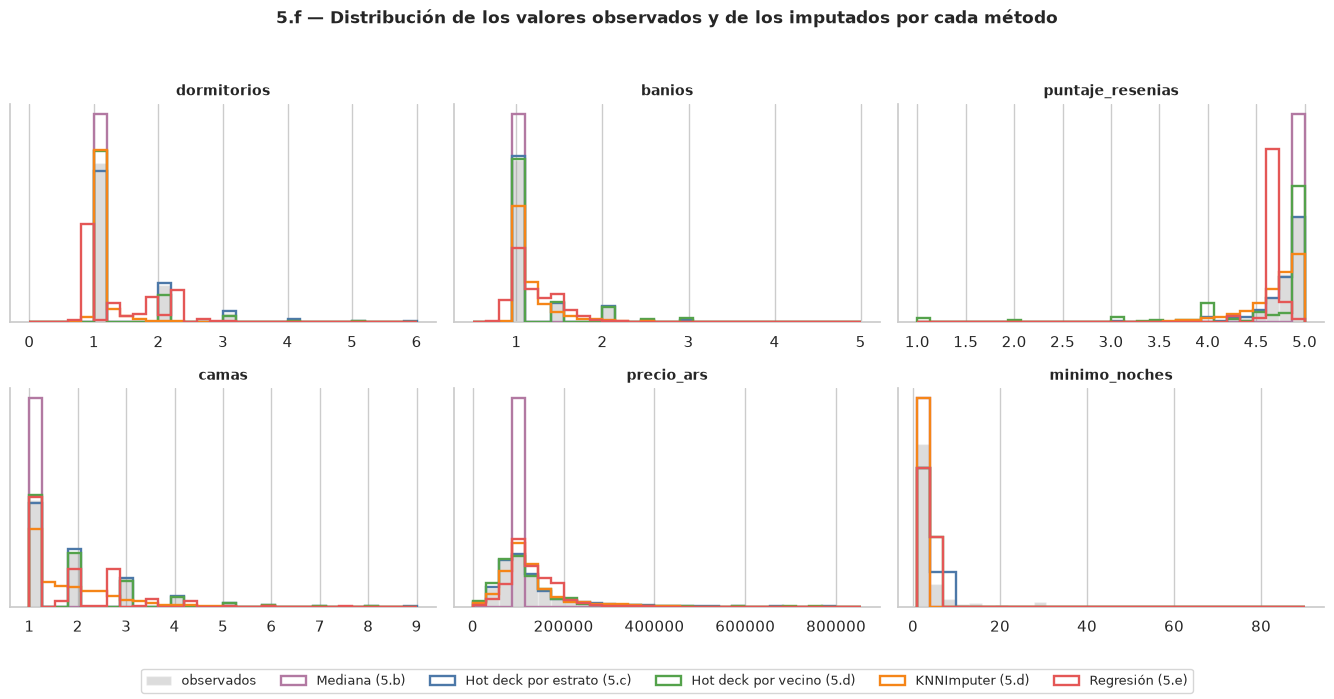

In [45]:
# --- 5.f Gráfico: cómo se distribuyen los valores que imputa cada método ---
# Cada panel mira una columna. La franja gris es la distribución de los valores
# observados; las líneas de color, la de los valores que imputó cada método.
fig, ejes = plt.subplots(2, 3, figsize=(13.5, 7))
for eje, columna in zip(ejes.ravel(), columnas_5b):
    observados = alquileres[columna].dropna()
    faltantes = alquileres[columna].isna()
    # Se recorta al percentil 99,5: si no, unas pocas observaciones muy grandes
    # aplastan el resto del gráfico contra el borde izquierdo.
    bordes = np.linspace(observados.min(), np.percentile(observados, 99.5), 31)

    eje.hist(observados, bins=bordes, density=True, color="#8C8C8C",
             alpha=0.30, label="observados", zorder=1)
    for metodo, datos in VERSIONES_5F.items():
        eje.hist(datos.loc[faltantes, columna], bins=bordes, density=True,
                 histtype="step", lw=1.7, color=COLORES_5F[metodo],
                 label=metodo, zorder=3)

    eje.set_title(columna, fontsize=10, fontweight="bold")
    eje.set_yticks([])
    eje.grid(axis="y", alpha=0.2)
    sns.despine(ax=eje)

manejadores, etiquetas = ejes[0, 0].get_legend_handles_labels()
fig.legend(manejadores, etiquetas, loc="lower center", ncols=6, fontsize=9,
           frameon=True)
fig.suptitle("5.f — Distribución de los valores observados y de los imputados por cada método",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
plt.show()


Celdas faltantes en el dataset enmascarado: 33357 (los originales más los retenidos a propósito)



Error absoluto medio sobre los valores retenidos, en % del desvío de cada
columna (más chico = mejor):


,dormitorios,banios,puntaje_resenias,camas,precio_ars,minimo_noches,Promedio
Mediana (5.b),35.8,33.1,48.4,59.2,50.6,15.7,40.4
Hot deck por estrato (5.c),60.3,57.8,76.0,80.3,73.5,30.9,63.1
Hot deck por vecino (5.d),28.5,35.3,65.2,38.8,54.1,24.5,41.1
KNNImputer (5.d),25.8,32.8,55.5,33.5,43.7,26.9,36.4
Regresión (5.e),37.3,42.3,49.6,32.5,44.5,23.1,38.2


Mejor método en cada columna:
  dormitorios        KNNImputer (5.d)
  banios             KNNImputer (5.d)
  puntaje_resenias   Mediana (5.b)
  camas              Regresión (5.e)
  precio_ars         KNNImputer (5.d)
  minimo_noches      Mediana (5.b)

Mejor método en promedio: KNNImputer (5.d)


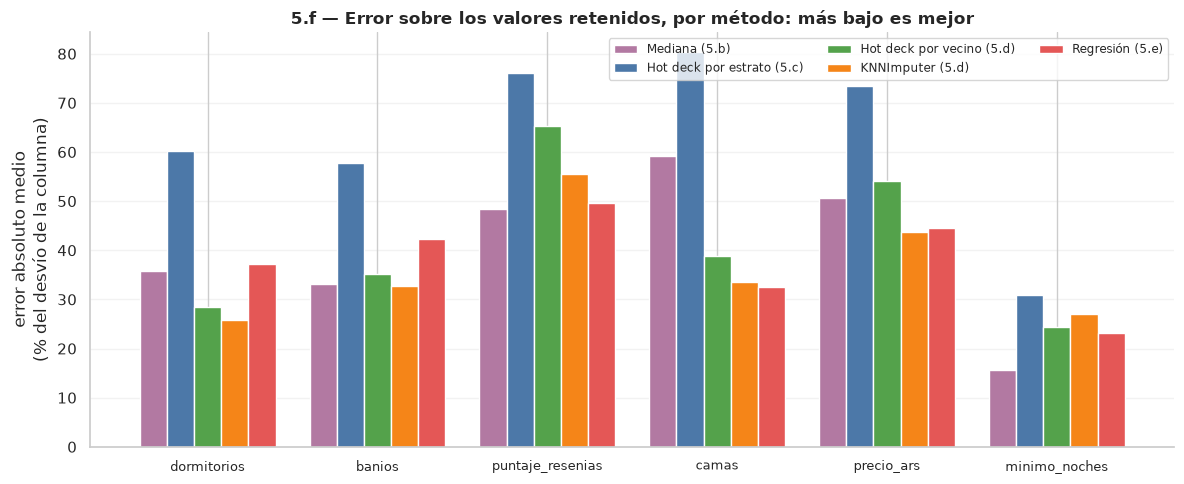

In [46]:
# --- 5.f Validación con valores retenidos: los cinco métodos en igualdad ---
# Mirando el dataset no hay forma de saber si una imputación acertó, porque los
# valores que faltan no se ven. Se oculta el 10 % de los que SÍ están observados,
# se imputa con cada método y se mide el error contra el valor verdadero.
#
# Para eso cada método se reescribe como función: es el mismo procedimiento de
# 5.b a 5.e, pero aplicado al dataset que recibe cada función en vez de al
# original. Así se pueden correr todos sobre los mismos datos enmascarados.
def version_mediana(datos):
    """5.b — cada faltante se reemplaza por la mediana de su columna."""
    salida = datos.copy()
    for columna in columnas_5b:
        salida[columna] = salida[columna].fillna(datos[columna].median())
    return salida


def version_hotdeck_estrato(datos, semilla=SEMILLA):
    """5.c — donante sorteado al azar dentro del mismo tipo_habitacion."""
    generador = np.random.default_rng(semilla)
    salida = datos.copy()
    for columna in columnas_5b:
        imputada = datos[columna].copy()
        for _, grupo in datos.groupby(ESTRATO_HOT_DECK, observed=True):
            receptores = grupo.index[grupo[columna].isna()]
            if len(receptores) == 0:
                continue
            donantes = grupo[columna].dropna()
            if len(donantes) == 0:
                donantes = datos[columna].dropna()
            imputada.loc[receptores] = generador.choice(
                donantes.to_numpy(), size=len(receptores), replace=True)
        salida[columna] = imputada
    return salida


def version_hotdeck_vecino(datos):
    """5.d — donante más cercano dentro del bloque barrio + tipo_habitacion."""
    salida = datos.copy()
    for columna in columnas_5b:
        salida[columna] = hot_deck(datos, columna)[0]
    return salida


def version_knn(datos):
    """5.d — KNNImputer sobre las once variables numéricas estandarizadas."""
    escala_5f = StandardScaler().fit(datos[NUMERICAS_KNN])
    salida = datos.copy()
    salida[NUMERICAS_KNN] = escala_5f.inverse_transform(
        KNNImputer(n_neighbors=5, weights="distance")
        .fit_transform(escala_5f.transform(datos[NUMERICAS_KNN])))
    return salida


def version_regresion(datos):
    """5.e — regresión lineal por columna sobre las variables completas."""
    salida = datos.copy()
    for columna in columnas_5b:
        diseno = matriz_diseno(datos)
        objetivo = datos[columna]
        observado = objetivo.notna()
        modelo = LinearRegression().fit(diseno[observado], objetivo[observado])
        predicho = pd.Series(modelo.predict(diseno[~observado]),
                             index=objetivo[~observado].index)
        salida.loc[~observado, columna] = predicho.clip(
            lower=objetivo[observado].min())
    return salida


FUNCIONES_5F = {
    "Mediana (5.b)": version_mediana,
    "Hot deck por estrato (5.c)": version_hotdeck_estrato,
    "Hot deck por vecino (5.d)": version_hotdeck_vecino,
    "KNNImputer (5.d)": version_knn,
    "Regresión (5.e)": version_regresion,
}

# Enmascarado: se oculta el 10 % de los valores observados de cada columna.
SEMILLA_5F = 2026
generador_5f = np.random.default_rng(SEMILLA_5F)
enmascarado_5f = alquileres.copy()
verdaderos_5f = {}
for columna in columnas_5b:
    observados = alquileres.index[alquileres[columna].notna()]
    ocultar = generador_5f.choice(observados.to_numpy(),
                                  size=int(0.10 * len(observados)), replace=False)
    verdaderos_5f[columna] = alquileres.loc[ocultar, columna]
    enmascarado_5f.loc[ocultar, columna] = np.nan

print("Celdas faltantes en el dataset enmascarado:",
      int(enmascarado_5f[columnas_5b].isna().sum().sum()),
      "(los originales más los retenidos a propósito)")

# El error se expresa en % del desvío de cada columna para que las seis variables,
# que están en unidades muy distintas, se puedan comparar en la misma tabla.
filas_validacion = {}
for metodo, funcion in FUNCIONES_5F.items():
    imputado = funcion(enmascarado_5f)
    errores = []
    for columna in columnas_5b:
        real = verdaderos_5f[columna]
        desvio = enmascarado_5f[columna].std()
        errores.append(100 * (imputado.loc[real.index, columna] - real)
                       .abs().mean() / desvio)
    filas_validacion[metodo] = errores

validacion_5f = pd.DataFrame(filas_validacion, index=columnas_5b).T
validacion_5f["Promedio"] = validacion_5f.mean(axis=1)
print("\nError absoluto medio sobre los valores retenidos, en % del desvío de cada")
print("columna (más chico = mejor):")
display(validacion_5f.round(1))

print("Mejor método en cada columna:")
for columna in columnas_5b:
    mejor = validacion_5f.loc[list(FUNCIONES_5F), columna].idxmin()
    print(f"  {columna:18s} {mejor}")
print(f"\nMejor método en promedio: {validacion_5f.loc[list(FUNCIONES_5F), 'Promedio'].idxmin()}")

# El mismo resultado, en un gráfico de barras agrupadas.
posiciones = np.arange(len(columnas_5b))
ancho = 0.16
fig, ax = plt.subplots(figsize=(12, 5))
for i, metodo in enumerate(FUNCIONES_5F):
    ax.bar(posiciones + (i - 2) * ancho, validacion_5f.loc[metodo, columnas_5b],
           width=ancho, color=COLORES_5F[metodo], edgecolor="white", label=metodo)

ax.set_xticks(posiciones, columnas_5b, fontsize=9)
ax.set_ylabel("error absoluto medio\n(% del desvío de la columna)")
ax.set_title("5.f — Error sobre los valores retenidos, por método: más bajo es mejor",
             fontsize=12, fontweight="bold")
ax.legend(frameon=True, ncols=3, fontsize=8.5)
ax.grid(axis="y", alpha=0.25)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()


**Cómo queda la dispersión.** Cambio porcentual del desvío respecto del original, en valor absoluto promedio sobre las seis columnas:

- **KNNImputer: 2,35 %** ← la menor distorsión
- Regresión: 3,36 %
- Mediana: 4,43 %
- Hot deck por estrato: 5,08 %
- Hot deck por vecino: **10,66 %** ← la mayor

Conviene mirar el valor absoluto y no el signo: tanto comprimir la variable (desvío de menos) como inflarla (desvío de más) son formas de distorsionarla. El caso extremo es el hot deck por vecino en `dormitorios` (+41,65 %) y en `puntaje_resenias` (+21,36 %).

**Cuál imputa mejor.** Error absoluto medio sobre los valores retenidos, en % del desvío de cada columna (más chico = mejor):

- `dormitorios`: KNN 25,8 · HD vecino 28,5 · Mediana 35,8 · Regresión 37,3 · HD estrato 60,3
- `banios`: KNN 32,8 · Mediana 33,1 · HD vecino 35,3 · Regresión 42,3 · HD estrato 57,8
- `puntaje_resenias`: **Mediana 48,4** · Regresión 49,6 · KNN 55,5 · HD vecino 65,2 · HD estrato 76,0
- `camas`: **Regresión 32,5** · KNN 33,5 · HD vecino 38,8 · Mediana 59,2 · HD estrato 80,3
- `precio_ars`: KNN 43,7 · Regresión 44,5 · Mediana 50,6 · HD vecino 54,1 · HD estrato 73,5
- `minimo_noches`: **Mediana 15,7** · Regresión 23,1 · HD vecino 24,5 · KNN 26,9 · HD estrato 30,9
- **En promedio**: KNN 36,4 · Regresión 38,2 · Mediana 40,4 · HD vecino 41,1 · HD estrato 63,1

**Las dos comparaciones ordenan a los métodos casi igual**, y ese es el resultado más sólido del análisis. KNNImputer es el mejor en las dos dimensiones y la regresión es segunda en ambas; el hot deck por estrato es el peor en acierto y el hot deck por vecino el que más distorsiona la dispersión. Que dos criterios independientes coincidan es una señal de que el orden no es un artefacto de la métrica elegida.

**La diferencia entre 5.c y 5.d es solo el criterio de similitud, y vale 22 puntos.** El hot deck por estrato (63,1 de error promedio) y el hot deck por vecino (41,1) son el mismo método: copiar el valor de otro aviso. Lo único que cambia es **cómo se elige al donante** —al azar dentro de `tipo_habitacion`, contra el más parecido dentro de `barrio` + `tipo_habitacion`—. Es la demostración más clara de lo que dice la teoría: en el hot deck el modelo está **implícito en la definición de "parecido"**, y esa definición es la que decide la calidad del resultado.

**La mediana gana donde los métodos "inteligentes" no tienen con qué.** En `puntaje_resenias` (48,4) y `minimo_noches` (15,7) gana el valor fijo. Son exactamente las dos variables donde la regresión tuvo R² casi nulo (0,077 y 0,009) y donde el hot deck por vecino elegía donantes ruidosos. Las tres secciones llegan a lo mismo por caminos distintos: **cuando la variable no depende de las demás, ningún método que las use puede aportar nada, y el más simple resulta el mejor**.

**La regresión gana donde hay una relación real.** En `camas` (32,5) le saca ventaja a todos, y es justamente la variable con mejor R² (0,633). Cuando la relación existe, la regresión la aprovecha mejor que copiar valores, porque usa toda la información a la vez en lugar de un solo vecino.

**Los valores que devuelve cada método son de naturaleza distinta.** La cantidad de valores distintos introducidos en las seis columnas lo resume: la mediana usa **6** (uno por columna), los dos hot deck alrededor de **1.700** (valores reales copiados de otros avisos) y KNN y regresión **10.258** y **16.946** (valores calculados). Los dos primeros solo pueden repetir lo que ya existe en el dataset; los dos últimos producen valores que ningún aviso tiene.

**Cuál conviene usar en este dataset.** Con la evidencia de las dos comparaciones, `KNNImputer` es la mejor opción global y la regresión queda muy cerca. Pero la respuesta útil no es un ranking sino una regla:

- Si el análisis posterior depende de la **distribución** (varianzas, correlaciones, componentes principales), conviene el método que menos la distorsione: en esta tabla, KNN y regresión.
- Si el análisis depende de **valores individuales**, también conviene KNN, salvo en las variables impredecibles, donde la mediana es igual de buena y mucho más simple.
- Si lo que se busca es **no inventar valores** —por ejemplo, respetar que `dormitorios` solo puede tomar enteros plausibles—, el hot deck tiene esa ventaja, pero hay que aceptar que su acierto depende por completo del criterio de similitud que se elija.

**Tres advertencias para no perder de vista.** La primera: todos estos métodos suponen que el faltante es **MAR**, es decir, que se puede explicar con las demás variables. En 5.a vimos que `puntaje_resenias` falta de forma **estructural** (solo cuando `cantidad_resenias` es 0), y es la variable donde los métodos elaborados hacen peor papel. No es casualidad: es el supuesto fallando. La segunda: `dormitorios` arrastra inconsistencias de carga —avisos de una habitación que informan los dormitorios de toda la propiedad, con valores de hasta 31—, y eso hace que cualquier método que copie valores reales herede esa dispersión. La tercera, y la más importante: estas comparaciones **no** demuestran que el método ganador acierte los valores que realmente faltan, porque esos no se conocen. Lo que se midió es cómo se comporta cada método en valores que sí se conocían y se ocultaron a propósito. Es la mejor aproximación disponible, pero sigue siendo una aproximación.


## 6. Análisis de Componentes Principales

Los tramos anteriores usaron `calidad_aire.csv` (Parte 1) y `alquileres.csv` (punto 5). Este último usa un tercer dataset: **`vehiculos.csv`**, la ficha oficial de consumo y emisiones de los modelos 2024 a 2026 comercializados en Estados Unidos. Tiene 11 variables numéricas —`anio`, `cilindros`, `cilindrada`, los tres `mpg_*`, `co2_g_milla`, `barriles_anio`, `costo_combustible_anio`, `puntaje_gei` y `ahorro_5anios`— y 6 categóricas (`marca`, `modelo`, `clase`, `traccion`, `combustible`, `transmision`).

Un detalle del dataset: **dos filas vienen repetidas de punta a punta** (el mismo vehículo cargado dos veces) y se dejan como están, porque son 2 de 2.809 y no alteran ningún resultado. Algo distinto ocurre al mirar solo las 11 variables numéricas: ahí **muchas filas comparten su perfil sin ser el mismo registro** —distintos vehículos con la misma ficha técnica, como el Coupé y el Convertible de un mismo modelo—, así que tampoco corresponde deduplicar: se perderían vehículos reales y el resultado no cambiaría.

El **análisis de componentes principales (PCA)** busca ejes nuevos —las *componentes*— que son combinaciones lineales de las variables originales, ordenados por cuánta varianza explican y **sin correlacionarse entre sí**. La idea es que, si varias variables originales miden en parte lo mismo, unas pocas componentes alcancen para resumir el dataset casi sin perder información.

Antes de aplicarlo, la consigna pide mirar la **matriz de covarianzas**, que es la que dice si esas redundancias existen.

### 6.a La matriz de covarianzas

**Qué es.** Una tabla cuadrada con una fila y una columna por variable, que resume dos cosas a la vez:

- **En la diagonal**: la **varianza** de cada variable, es decir, cuánto varía por su cuenta.
- **Fuera de la diagonal**: la **covarianza** de cada par, que mide si tienden a moverse juntas.

De la covarianza de un par lo que se interpreta es el **signo**, porque su magnitud depende de las unidades: **positiva** si las dos variables crecen juntas, **negativa** si una crece cuando la otra baja, y **cercana a cero** si no hay una relación lineal entre ellas. Como la covarianza de una variable consigo misma es su varianza, la matriz es **simétrica** y alcanza con leer una mitad.

**Por qué importa para PCA.** Si muchas variables se mueven juntas, están midiendo en parte lo mismo: eso es **redundancia**, y es la materia prima del método. Si las 11 variables fueran independientes entre sí no habría nada que comprimir. Esta matriz es la que dice si el ejercicio tiene sentido sobre este dataset.

**Un problema que hay que tener presente desde el principio.** Como la covarianza conserva las unidades de las variables, sus números **no son comparables entre pares distintos**. Una variable medida en miles siempre va a mostrar covarianzas más grandes que otra medida en unidades, aunque su relación sea más débil. Por eso, después de leer esta matriz, el análisis se hace sobre la **matriz de correlaciones**.


In [47]:
# --- 6.a El dataset de vehículos ---
vehiculos = pd.read_csv("data/vehiculos.csv")
print(f"Filas: {len(vehiculos)}   Columnas: {vehiculos.shape[1]}")

# Dos filas están repetidas de punta a punta (idénticas en las 17 columnas): el mismo
# vehículo cargado dos veces. Se dejan como están.
repetidas = int(vehiculos.duplicated().sum())
print(f"Filas repetidas de punta a punta: {repetidas} "
      f"({2 * repetidas} filas involucradas en {repetidas} pares)")

resumen_vehiculos = pd.DataFrame({
    "Tipo": vehiculos.dtypes.astype(str),
    "Faltantes": vehiculos.isna().sum(),
    "Valores distintos": vehiculos.nunique(),
})
print("\nComposición del dataset:")
display(resumen_vehiculos)

# El análisis de componentes principales trabaja sobre variables numéricas, y solo
# sobre las filas que las tienen completas.
VARIABLES_NUMERICAS = ["anio", "cilindros", "cilindrada", "mpg_ciudad", "mpg_ruta",
                       "mpg_combinado", "co2_g_milla", "barriles_anio",
                       "costo_combustible_anio", "puntaje_gei", "ahorro_5anios"]

datos_vehiculos = vehiculos[VARIABLES_NUMERICAS].dropna()
print(f"\nFilas con las 11 variables numéricas completas: {len(datos_vehiculos)} "
      f"de {len(vehiculos)}")

# Al dejar de lado `marca` y `modelo` quedan vehículos distintos con los mismos 11
# valores (por ejemplo, el Coupé y el Convertible de un mismo modelo). No se
# deduplican: son vehículos reales y el análisis no cambia por ellos.
perfiles_repetidos = int(datos_vehiculos.duplicated().sum())
print(f"Perfiles numéricos repetidos: {perfiles_repetidos} "
      f"({len(datos_vehiculos) - perfiles_repetidos} perfiles distintos "
      f"para {len(datos_vehiculos)} filas)")

# Las escalas: van a ser el punto central de este ejercicio.
tabla_escalas = pd.DataFrame({
    "Mínimo": datos_vehiculos.min(),
    "Máximo": datos_vehiculos.max(),
    "Desvío": datos_vehiculos.std(),
    "Varianza": datos_vehiculos.var(),
}).sort_values("Varianza", ascending=False)
print("\nEscala de cada variable:")
display(tabla_escalas.round(2))


Filas: 2809   Columnas: 17
Filas repetidas de punta a punta: 2 (4 filas involucradas en 2 pares)

Composición del dataset:


,Tipo,Faltantes,Valores distintos
marca,str,0,42
modelo,str,0,1009
anio,int64,0,3
clase,str,0,20
traccion,str,0,5
combustible,str,0,9
transmision,str,0,25
cilindros,float64,12,8
cilindrada,float64,12,33
mpg_ciudad,int64,0,53



Filas con las 11 variables numéricas completas: 2797 de 2809
Perfiles numéricos repetidos: 457 (2340 perfiles distintos para 2797 filas)

Escala de cada variable:


,Mínimo,Máximo,Desvío,Varianza
ahorro_5anios,-31250.00,7250.00,4869.09,23708023.71
costo_combustible_anio,1100.00,8450.00,962.62,926631.80
co2_g_milla,50.00,979.00,113.00,12769.82
mpg_ciudad,8.00,57.00,7.51,56.44
mpg_combinado,9.00,57.00,7.05,49.66
mpg_ruta,11.00,58.00,6.74,45.42
barriles_anio,1.72,33.06,3.81,14.53
cilindros,3.00,16.00,1.75,3.08
puntaje_gei,1.00,10.00,1.49,2.21
cilindrada,1.20,8.00,1.19,1.43


Matriz de covarianzas (11 x 11):


,anio,cilindros,cilindrada,mpg_ciudad,mpg_ruta,mpg_combinado,co2_g_milla,barriles_anio,costo_combustible_anio,puntaje_gei,ahorro_5anios
anio,0.659817,-0.036927,-0.026324,0.297731,0.115237,0.225264,-4.045595,-0.138479,-2.705123e+01,0.000075,1.752347e+02
cilindros,-0.036927,3.075376,1.921784,-7.888830,-7.488683,-7.830192,137.801410,4.664294,1.320509e+03,-1.646603,-6.456611e+03
cilindrada,-0.026324,1.921784,1.426171,-5.365166,-5.249993,-5.372304,97.285832,3.276834,8.560915e+02,-1.167653,-4.258658e+03
mpg_ciudad,0.297731,-7.888830,-5.365166,56.442743,45.659567,52.195277,-703.539601,-23.571978,-6.061819e+03,9.177459,3.032969e+04
mpg_ruta,0.115237,-7.488683,-5.249993,45.659567,45.417777,45.479640,-642.066436,-21.465250,-5.528361e+03,8.098717,2.712136e+04
mpg_combinado,0.225264,-7.830192,-5.372304,52.195277,45.479640,49.664135,-681.771050,-22.871043,-5.896020e+03,8.795738,2.930031e+04
co2_g_milla,-4.045595,137.801410,97.285832,-703.539601,-642.066436,-681.771050,12769.818064,428.944834,9.302716e+04,-162.381861,-5.100085e+05
barriles_anio,-0.138479,4.664294,3.276834,-23.571978,-21.465250,-22.871043,428.944834,14.531669,3.140492e+03,-5.492619,-1.725426e+04
costo_combustible_anio,-27.051228,1320.509437,856.091541,-6061.819480,-5528.361006,-5896.019762,93027.161459,3140.491520,9.266318e+05,-1152.613417,-4.555261e+06
puntaje_gei,0.000075,-1.646603,-1.167653,9.177459,8.098717,8.795738,-162.381861,-5.492619,-1.152613e+03,2.210231,6.439106e+03


La diagonal (varianza de cada variable), de mayor a menor:
ahorro_5anios             2.370802e+07
costo_combustible_anio    9.266318e+05
co2_g_milla               1.276982e+04
mpg_ciudad                5.644300e+01
mpg_combinado             4.966400e+01
mpg_ruta                  4.541800e+01
barriles_anio             1.453200e+01
cilindros                 3.075000e+00
puntaje_gei               2.210000e+00
cilindrada                1.426000e+00
anio                      6.600000e-01

La varianza más grande (23,708,024) es 35,931,230 veces la más chica (0.660).


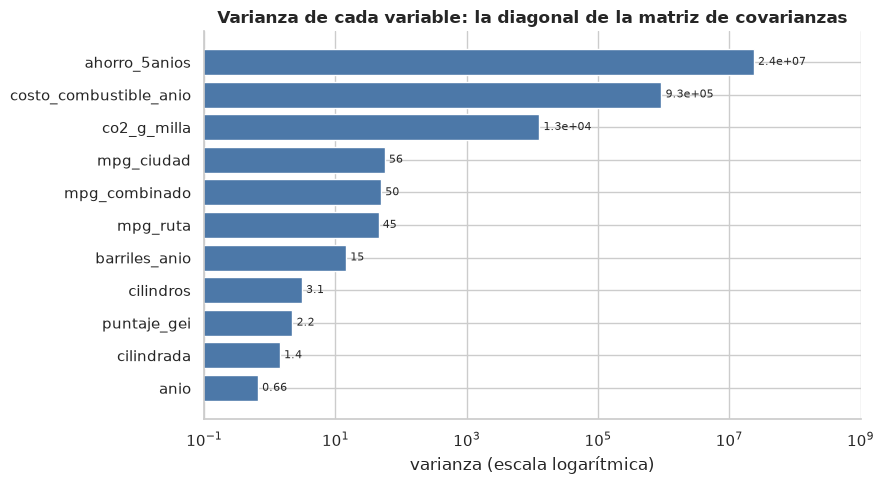

In [48]:
# --- 6.a La matriz de covarianzas ---
# Es una tabla cuadrada: en la diagonal está la varianza de cada variable (cuánto
# varía por su cuenta) y fuera de la diagonal la covarianza de cada par (cuánto
# varían juntas). Del par se interpreta el SIGNO: positivo = se mueven en la misma
# dirección, negativo = en direcciones opuestas, cerca de cero = sin relación.
# Como la covarianza de una variable consigo misma es su varianza, la matriz es
# simétrica y alcanza con leer una mitad.
matriz_covarianzas = datos_vehiculos.cov()
print("Matriz de covarianzas (11 x 11):")
display(matriz_covarianzas)

# La diagonal es la varianza de cada variable, y ya deja ver el problema.
varianzas_6a = pd.Series(np.diag(matriz_covarianzas),
                         index=matriz_covarianzas.index)
print("La diagonal (varianza de cada variable), de mayor a menor:")
print(varianzas_6a.sort_values(ascending=False).round(3).to_string())
print(f"\nLa varianza más grande ({varianzas_6a.max():,.0f}) es "
      f"{varianzas_6a.max() / varianzas_6a.min():,.0f} veces la más chica "
      f"({varianzas_6a.min():,.3f}).")

# Esas varianzas son la diagonal de la matriz, y el gráfico las muestra en escala
# logarítmica: en un eje lineal, las ocho órdenes de magnitud que las separan
# dejarían a todas las variables aplastadas contra el cero, invisibles al lado de
# ahorro_5anios. La escala logarítmica comprime esas distancias.
varianzas_ordenadas = varianzas_6a.sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(varianzas_ordenadas.index, varianzas_ordenadas.values,
                 color=COLOR_ORIGINAL, edgecolor="white")
ax.bar_label(barras, fmt="%.2g", padding=3, fontsize=8)
ax.set_xscale("log")
ax.set_xlim(1e-1, 1e9)
ax.set_xlabel("varianza (escala logarítmica)")
ax.set_title("Varianza de cada variable: la diagonal de la matriz de covarianzas",
             fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


### 6.a Por qué la matriz de covarianzas no alcanza

La tabla anterior muestra el problema a simple vista: sus números van desde centésimas hasta decenas de millones, porque cada uno arrastra las unidades de sus dos variables. `ahorro_5anios` y `costo_combustible_anio` están medidos en dólares, `co2_g_milla` en gramos por milla, `cilindrada` en litros y los `mpg_*` en millas por galón. No hay forma de comparar la relación entre dos variables con la relación entre otras dos mirando esos valores.

La diagonal lo deja todavía más claro: la varianza de `ahorro_5anios` es **23.708.024**, la de `cilindrada` es **1,43** y la de `anio`, **0,66**. La primera es **16,6 millones de veces** más grande que la segunda y **35,9 millones** más que la tercera. Si se leyera la matriz por el tamaño de sus números, la conclusión sería que `ahorro_5anios` es la variable más importante del dataset — y eso no es un hallazgo: es un efecto de que está medida en dólares.

El gráfico de barras usa **escala logarítmica** justamente por eso. En un eje lineal, las ocho órdenes de magnitud que separan a la varianza más grande de la más chica dejarían a todas las variables aplastadas contra el cero, invisibles al lado de `ahorro_5anios`. La escala logarítmica comprime esas distancias para que las once se puedan ver a la vez, y aun así las diferencias siguen siendo enormes: entre `anio` y `ahorro_5anios` hay siete órdenes y media de diferencia.

**La solución: la matriz de correlaciones.** La correlación es la covarianza dividida por los desvíos de las dos variables, así que **no tiene unidades** y queda siempre entre −1 y 1. Con eso los pares sí se pueden comparar entre sí. Calcular la matriz de correlaciones es equivalente a **estandarizar las variables y después calcular la de covarianzas**, así que de acá en adelante el PCA se hace sobre las variables estandarizadas.

Es el mismo recorrido que hace la guía de clase con el dataset de vinos: ahí la primera componente sin estandarizar explicaba el **99,8 %** y parecía un resultado espectacular, pero era un artificio —`proline` tenía una varianza 2 millones de veces mayor que `hue`—. La conclusión de la guía es la regla general: *con variables en unidades distintas, PCA se hace sobre la matriz de correlaciones*.


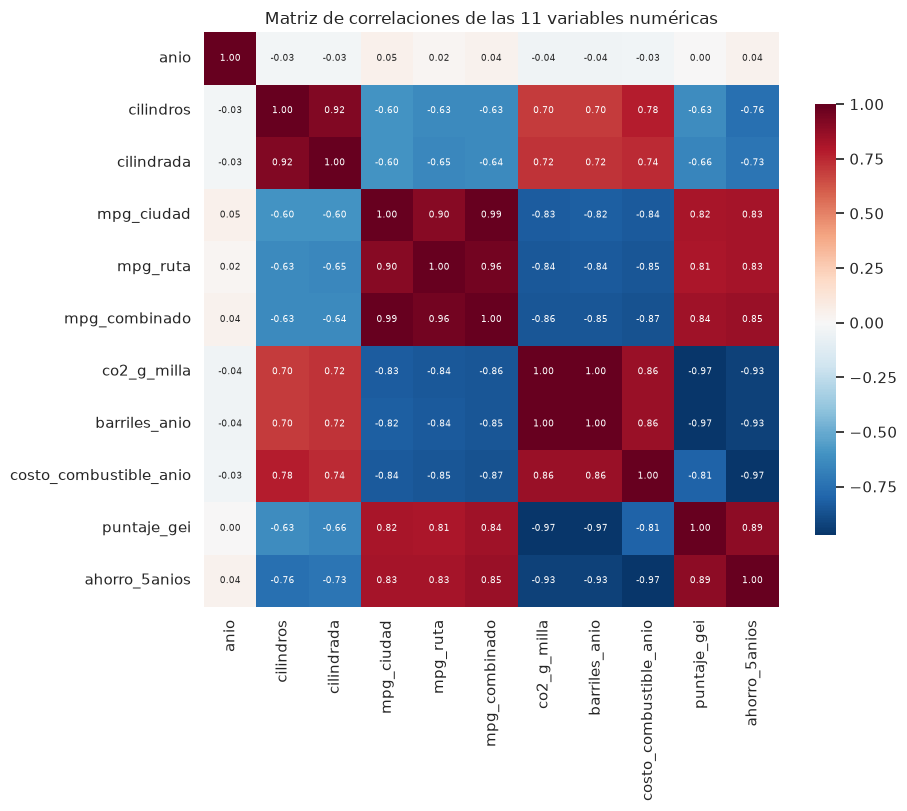

Pares de variables más relacionados (|r| ordenado):
co2_g_milla             barriles_anio    0.996
mpg_ciudad              mpg_combinado    0.986
costo_combustible_anio  ahorro_5anios   -0.972
barriles_anio           puntaje_gei     -0.969
co2_g_milla             puntaje_gei     -0.967
mpg_ruta                mpg_combinado    0.958
barriles_anio           ahorro_5anios   -0.930
co2_g_milla             ahorro_5anios   -0.927

Relación promedio de cada variable con las demás (|r| medio):
ahorro_5anios             0.776
co2_g_milla               0.773
barriles_anio             0.772
costo_combustible_anio    0.761
mpg_combinado             0.752
puntaje_gei               0.739
mpg_ruta                  0.733
mpg_ciudad                0.727
cilindrada                0.641
cilindros                 0.637
anio                      0.033


In [49]:
# --- 6.a La matriz de correlaciones ---
# La covarianza conserva las unidades, así que su magnitud depende de la escala y
# no se puede comparar entre pares distintos. La correlación divide cada covarianza
# por los desvíos de las dos variables, y así queda siempre entre -1 y 1.
matriz_correlaciones = datos_vehiculos.corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
sns.heatmap(matriz_correlaciones, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            square=True, annot_kws={"size": 6.5}, cbar_kws={"shrink": .75}, ax=ax)
ax.set_title("Matriz de correlaciones de las 11 variables numéricas")
plt.tight_layout()
plt.show()

# Los pares más relacionados: ahí está la redundancia que PCA va a comprimir.
triangulo = np.triu(np.ones(matriz_correlaciones.shape), k=1).astype(bool)
pares = matriz_correlaciones.where(triangulo).stack()
pares = pares.reindex(pares.abs().sort_values(ascending=False).index)
print("Pares de variables más relacionados (|r| ordenado):")
print(pares.head(8).round(3).to_string())

# Y las correlaciones de cada variable con el resto, en valor absoluto promedio.
print("\nRelación promedio de cada variable con las demás (|r| medio):")
print(matriz_correlaciones.abs().where(~np.eye(len(VARIABLES_NUMERICAS),
                                               dtype=bool)).mean()
      .sort_values(ascending=False).round(3).to_string())


### 6.a Qué nos dice la matriz sobre los atributos

**Hay mucha redundancia, y eso es lo que habilita el PCA.** Varios grupos de variables se mueven casi exactamente juntas:

- `co2_g_milla` y `barriles_anio`: **0,996**. Emitir más CO₂ y consumir más barriles de petróleo son, en la práctica, el mismo hecho medido de dos maneras.
- `mpg_ciudad` y `mpg_combinado`: **0,986** (y `mpg_ruta` con `mpg_combinado`, 0,958). El rendimiento combinado se calcula a partir de los otros dos, así que son tres formas de medir lo mismo.
- `costo_combustible_anio` y `ahorro_5anios`: **−0,972**. Cuanto más caro sale el combustible al año, menos se "ahorra" respecto del vehículo promedio.
- `puntaje_gei` con `barriles_anio` y con `co2_g_milla`: **−0,969** y **−0,967**. El puntaje de gases de efecto invernadero es alto cuando las emisiones son bajas.

Además de esos pares, hay un **bloque grande** que enfrenta el tamaño del motor contra la eficiencia: `cilindros` y `cilindrada` correlacionan entre sí 0,92, correlacionan negativamente con los tres `mpg` (entre −0,60 y −0,65) y positivamente con `co2_g_milla` (0,70 y 0,72) y con el costo anual de combustible (0,78 y 0,74). Un motor más grande rinde menos y contamina más.

La excepción es **`anio`**: su correlación promedio con el resto es **0,033**, y ninguna supera 0,05 en valor absoluto. En este dataset, el año del modelo no dice nada sobre las demás características —algo que va a tener consecuencias cuando busquemos las componentes—.

**La lectura de conjunto.** De las 11 variables, 10 tienen una relación promedio con las demás de entre 0,64 y 0,78; `anio` queda sola en 0,03. Ésa es exactamente la situación en la que PCA sirve: hay bloques de variables que se mueven juntos y deberían poder resumirse en unas pocas componentes, porque buena parte de lo que aporta cada una ya está contenida en las otras.

**Por qué la matriz de covarianzas no alcanzaba.** Su limitación quedó demostrada con números: la varianza de `ahorro_5anios` es 16,6 millones de veces la de `cilindrada` y 35,9 millones la de `anio`. Cualquier lectura de esa matriz terminaría comparando escalas en lugar de relaciones. Por eso, de acá en adelante, todo el análisis se hace sobre las variables **estandarizadas**, lo que equivale a trabajar con la matriz de correlaciones.


### 6.b Las componentes principales

**PCA** construye ejes nuevos —las *componentes*— como combinaciones lineales de las 11 variables. La primera se orienta hacia la dirección de **máxima varianza** de los datos; la segunda, hacia la siguiente dirección de máxima varianza **perpendicular a la primera**, y así siguiendo. Quedan ordenadas por cuánta varianza explican y son **ortogonales entre sí**: sus varianzas se suman sin solaparse, cada una aporta algo que las anteriores no contienen.

Antes de correrlo hay una decisión que tomar. PCA maximiza varianza, y la varianza depende de las unidades: en 6.a quedó visto que la de `ahorro_5anios` (dólares) es 35,9 millones de veces la de `anio`. Si se lo deja trabajar sobre la matriz de covarianzas, la dirección de máxima varianza ya está elegida de antemano. Conviene comprobarlo.

In [50]:
# --- 6.b Qué pasa si se aplica PCA sobre los datos sin estandarizar ---
# PCA busca la dirección de máxima varianza. Sobre datos sin estandarizar, la
# variable de mayor escala (ahorro_5anios, medida en dólares) es dueña de casi toda
# esa varianza, así que la primera componente termina copiándola.
from sklearn.decomposition import PCA

pca_sin_estandarizar = PCA().fit(datos_vehiculos)
pesos_sin_estandarizar = pd.Series(np.abs(pca_sin_estandarizar.components_[0]),
                                   index=VARIABLES_NUMERICAS)

print("PCA sobre los datos tal como vienen:")
print(f"  varianza que explica la CP1: "
      f"{100 * pca_sin_estandarizar.explained_variance_ratio_[0]:.2f} %")
print(f"  autovalor de la CP1: {pca_sin_estandarizar.explained_variance_[0]:,.0f}")
print("  peso de cada variable dentro de la CP1 (las 3 mayores):")
print(pesos_sin_estandarizar.sort_values(ascending=False).head(3).round(4).to_string())


PCA sobre los datos tal como vienen:
  varianza que explica la CP1: 99.79 %
  autovalor de la CP1: 24,596,160
  peso de cada variable dentro de la CP1 (las 3 mayores):
ahorro_5anios             0.9817
costo_combustible_anio    0.1890
co2_g_milla               0.0211


El **99,79 % no es un hallazgo: es un artificio de escala.** El peso de `ahorro_5anios` dentro de esa componente es **0,982**: la CP1 no resumió el dataset, se limitó a copiar la variable medida en dólares. El autovalor lo confirma: **24.596.160**, prácticamente la varianza de esa variable sola (23.708.024) y casi la suma de toda la matriz (24.647.599). Es el mismo problema que la guía de clase muestra con `proline` en los vinos.

Por eso, cuando las variables están medidas en unidades distintas, PCA **se hace sobre la matriz de correlaciones**. Estandarizar antes —restarle a cada variable su media y dividirla por su desvío— es equivalente: deja a las 11 en la misma escala, cada una con varianza 1, y una varianza total de **11 puntos a repartir**.

In [51]:
# --- 6.b PCA sobre las variables estandarizadas ---
# Con las 11 variables en la misma escala, ninguna puede imponerse por el tamaño de
# su unidad: la varianza se reparte según el contenido real de cada una.
from sklearn.preprocessing import StandardScaler

X_vehiculos = StandardScaler().fit_transform(datos_vehiculos)
print(f"media de cada columna:  {X_vehiculos.mean().round(6)}   (objetivo: 0)")
print(f"desvío de cada columna: {X_vehiculos.std().round(6)}   (objetivo: 1)")

pca = PCA()                      # sin n_components: calcula las 11 componentes
# `puntajes` son las coordenadas de cada vehículo en los ejes nuevos: una fila por
# vehículo y una columna por componente. Se usan en 6.e.
puntajes = pd.DataFrame(pca.fit_transform(X_vehiculos),
                        columns=[f"CP{i + 1}" for i in range(pca.n_components_)],
                        index=datos_vehiculos.index)
CP = list(puntajes.columns)

# La tabla central del punto. El autovalor y el porcentaje son la misma información
# en dos escalas: el autovalor mide la varianza en "puntos" y el porcentaje, la
# parte que esa varianza representa del total.
resumen_pca = pd.DataFrame({
    "autovalor": pca.explained_variance_,
    "% varianza": 100 * pca.explained_variance_ratio_,
    "% acumulado": 100 * pca.explained_variance_ratio_.cumsum(),
}, index=CP)
print("\nVarianza explicada por cada componente:")
display(resumen_pca.round({"autovalor": 4, "% varianza": 2, "% acumulado": 2}))

print("Lo que pregunta la consigna:")
print(f"  la CP1 sola explica el "
      f"{100 * pca.explained_variance_ratio_[0]:.2f} % de la variación total")
print(f"  incorporando la CP2, entre las dos explican el "
      f"{100 * pca.explained_variance_ratio_[:2].sum():.2f} %")
print(f"  el primer autovalor es {pca.explained_variance_[0]:.4f}")

# La varianza total a repartir es 11, una por variable estandarizada. Ésa es la
# relación entre las dos primeras columnas: autovalor ≈ 11 x proporción.
print(f"\nvarianza total a repartir: {pca.explained_variance_.sum():.4f}")

# Control cruzado: la varianza de cada columna de `puntajes` tiene que ser el
# autovalor de esa componente. Es la misma cuenta mirada desde los datos en vez de
# desde el modelo, y sirve para entender qué es un autovalor.
print(f"\nvarianza de los puntajes: {puntajes.var().round(4).to_numpy()}")
print(f"autovalores:              {pca.explained_variance_.round(4)}")


media de cada columna:  -0.0   (objetivo: 0)
desvío de cada columna: 1.0   (objetivo: 1)

Varianza explicada por cada componente:


,autovalor,% varianza,% acumulado
CP1,8.3147,75.56,75.56
CP2,1.0009,9.10,84.66
CP3,0.8270,7.52,92.17
CP4,0.4258,3.87,96.04
CP5,0.2212,2.01,98.05
CP6,0.1040,0.94,99.00
CP7,0.0679,0.62,99.61
CP8,0.0308,0.28,99.89
CP9,0.0059,0.05,99.95
CP10,0.0042,0.04,99.99


Lo que pregunta la consigna:
  la CP1 sola explica el 75.56 % de la variación total
  incorporando la CP2, entre las dos explican el 84.66 %
  el primer autovalor es 8.3147

varianza total a repartir: 11.0039

varianza de los puntajes: [8.3147e+00 1.0009e+00 8.2700e-01 4.2580e-01 2.2120e-01 1.0400e-01
 6.7900e-02 3.0800e-02 5.9000e-03 4.2000e-03 1.5000e-03]
autovalores:              [8.3147e+00 1.0009e+00 8.2700e-01 4.2580e-01 2.2120e-01 1.0400e-01
 6.7900e-02 3.0800e-02 5.9000e-03 4.2000e-03 1.5000e-03]


### 6.b Cuánto explica cada componente

- **La primera componente explica el 75,56 %** de la variación total del dataset.
- **Incorporando la segunda, entre las dos explican el 84,66 %** (la CP2 aporta 9,10 puntos).
- **El primer autovalor es 8,31.**

Las tres cifras son la misma información en dos escalas. Con las 11 variables estandarizadas la varianza total a repartir es 11 —un punto por variable—, así que el autovalor de una componente es 11 veces su proporción: 11 × 0,7556 ≈ 8,31.

**Qué significa el 8,31.** Si las 11 variables fueran independientes entre sí, cada componente valdría 1 y no habría nada que reducir. Que la primera se lleve 8,31 de los 11 puntos quiere decir que la varianza está muy concentrada en una sola dirección: hay mucha redundancia, la misma que ya se veía en la matriz de correlaciones.

**Hasta dónde llega la reducción.** Con 3 componentes se cubre el 92,17 % de la varianza y con 4 el 96,04 %. La caída es rapidísima: las últimas 5 componentes juntas no llegan al 2 %. Cuántas conviene conservar se discute en 6.f. Vale adelantar que la segunda componente merece un comentario aparte, que aparece al leer los *loadings* en 6.d.

Un detalle para quien sume la columna de autovalores: dan **11,0039** y no exactamente 11. Es una diferencia de grados de libertad entre `StandardScaler` (que divide por n) y el cálculo de la covarianza que hace PCA (que divide por n − 1); representa el 0,04 % de la varianza total y no cambia ninguna conclusión.

Como control cruzado, la varianza de cada columna de `puntajes` da exactamente el autovalor de esa componente. De ahí sale la interpretación de la columna: **el autovalor es la varianza de los puntajes de esa componente**, y el porcentaje es esa varianza dividida por el total.

### 6.c Perfil de variación de las componentes

La consigna pide el **perfil de variación**: cómo cae la varianza al pasar de una componente a la siguiente. El gráfico lo pone en un plano de dispersión, con **la varianza en el eje X y la componente en el eje Y**, un punto por componente.

Se lee de arriba hacia abajo: arriba está la CP1, después la CP2, y así hasta la CP11. Cuanto más a la derecha cae un punto, más varianza explica esa componente. Lo que interesa es la **forma** que dibuja el conjunto: si la varianza cae de golpe y después se aplana, son pocas componentes las que hacen el trabajo y el resto aporta muy poco.

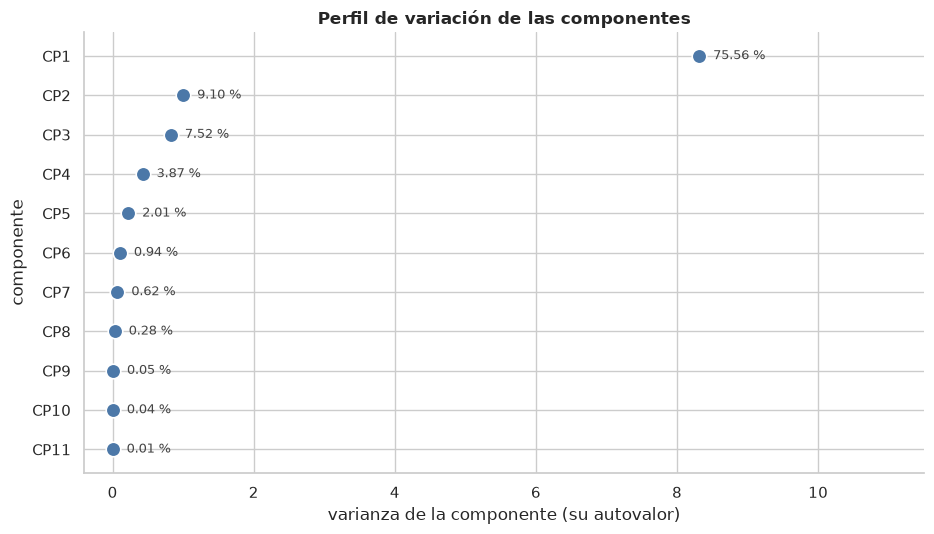

In [52]:
# --- 6.c Perfil de variación de las componentes ---
# Un punto por componente: en X, la varianza que explica (su autovalor); en Y, la
# componente. Como el eje Y sigue el orden de las componentes, el recorrido de los
# puntos dibuja el perfil de variación: cuánto aporta cada una, de mayor a menor.
posiciones = np.arange(len(CP))[::-1]      # CP1 arriba, CP11 abajo

fig, ax = plt.subplots(figsize=(9.5, 5.5))
ax.scatter(resumen_pca["autovalor"], posiciones, s=110, color=COLOR_ORIGINAL,
           edgecolor="white", linewidth=1.2, zorder=3)
for posicion, (_, fila) in zip(posiciones, resumen_pca.iterrows()):
    ax.annotate(f"{fila['% varianza']:.2f} %", (fila["autovalor"], posicion),
                xytext=(10, 0), textcoords="offset points", va="center",
                fontsize=9, color="#444444")

ax.set_yticks(posiciones)
ax.set_yticklabels(CP)
ax.set_xlim(-0.4, 11.5)
ax.set_ylim(-0.6, 10.6)
ax.set_xlabel("varianza de la componente (su autovalor)")
ax.set_ylabel("componente")
ax.set_title("Perfil de variación de las componentes", fontweight="bold")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()


El perfil es el de una **caída abrupta**. La CP1 está sola, muy lejos del resto (autovalor 8,31), y de la CP2 en adelante los valores se derrumban: 9,10 %, 7,52 %, 3,87 %, 2,01 %… hasta volverse despreciables. Las últimas cinco componentes juntas no llegan al 2 % de la varianza total.

**El "codo".** En este tipo de gráfico se busca el punto donde la caída se aplana, porque después de ahí cada componente nueva agrega muy poco. Acá el codo aparece temprano: la CP1 ya se lleva las tres cuartas partes de la varianza, y la CP2 y la CP3 todavía aportan algo (9,10 % y 7,52 %). Cuántas conviene conservar es la pregunta de 6.f.

**Un cuidado con este gráfico.** El eje de la varianza está en **escala lineal**, igual que en 6.a, y por eso los puntos de la CP4 en adelante se ven amontonados contra el cero: no es que expliquen lo mismo, es que al lado de 8,31 cualquier valor menor a 1 se vuelve invisible. Los números anotados al lado de cada punto están justamente para eso; sin ellos, el gráfico alcanza para ver que la caída es fuerte y dónde se aplana, pero no para comparar las componentes chicas entre sí.

### 6.d La matriz de *loading*

Hasta acá se vio **cuánta** varianza explica cada componente, pero no **de qué está hecha**. Eso es lo que responde la matriz de *loading*: una fila por variable original y una columna por componente, y en cada celda el peso de esa variable dentro de esa componente.

Se calcula multiplicando los autovectores que trae `pca.components_` —que son los pesos de la combinación lineal, normalizados a longitud 1— por la raíz del autovalor de cada componente. Esa corrección los lleva a la escala de los datos y es lo que permite interpretarlos.

**Cómo se lee.** La matriz se puede leer en las dos direcciones, y cada una responde una pregunta distinta:

- **Por columna**: de qué está hecha esa componente. Los loadings grandes en valor absoluto son las variables que la definen, y el signo indica en qué sentido.
- **Por fila**: qué tan bien está representada esa variable en las componentes que se miren. Una variable con loadings chicos en todas las componentes es una variable que se pierde al reducir.

Y hay un dato que simplifica la lectura: como las variables están estandarizadas, **los loadings se leen directamente como correlaciones** entre cada variable y cada componente. Van de −1 a 1, y su cuadrado es la proporción de la varianza de esa variable que la componente captura.

In [53]:
# --- 6.d La matriz de loading ---
# `pca.components_` trae los autovectores: los pesos de la combinación lineal, pero
# normalizados a longitud 1. Multiplicarlos por la raíz del autovalor de cada
# componente los lleva a la escala de los datos, y ahí se leen como correlaciones.
loadings = pd.DataFrame(pca.components_.T * np.sqrt(pca.explained_variance_),
                        index=VARIABLES_NUMERICAS, columns=CP)
print("Matriz de loadings (11 variables x 11 componentes):")
display(loadings.round(3))

# Control de la interpretación: con los datos estandarizados, el loading de una
# variable en una componente tiene que ser igual a la correlación entre esa variable y
# los puntajes de esa componente. Se calcula por afuera, sin usar `loadings`, y se
# compara contra el resultado anterior.
correlaciones_control = pd.DataFrame(
    [[np.corrcoef(X_vehiculos[:, j], puntajes[cp])[0, 1] for cp in CP]
     for j in range(len(VARIABLES_NUMERICAS))],
    index=VARIABLES_NUMERICAS, columns=CP)
print(f"diferencia máxima |loadings - correlaciones|: "
      f"{np.abs(loadings - correlaciones_control).to_numpy().max():.6f}")


Matriz de loadings (11 variables x 11 componentes):


,CP1,CP2,CP3,CP4,CP5,CP6,CP7,CP8,CP9,CP10,CP11
anio,0.041,0.999,-0.013,0.010,0.006,0.004,-0.003,0.007,-0.000,0.000,0.000
cilindros,-0.798,0.014,0.562,0.101,0.002,0.080,0.176,0.002,-0.002,-0.001,0.000
cilindrada,-0.802,0.014,0.543,0.055,-0.175,-0.040,-0.165,-0.009,-0.002,0.000,0.000
mpg_ciudad,0.907,0.018,0.279,-0.239,0.060,-0.189,0.040,-0.025,-0.000,0.010,-0.019
mpg_ruta,0.916,-0.014,0.201,-0.235,0.092,0.230,-0.065,0.022,0.010,0.006,-0.010
mpg_combinado,0.935,0.006,0.248,-0.238,0.065,-0.042,0.003,-0.004,0.004,-0.017,0.029
co2_g_milla,-0.958,-0.003,-0.076,-0.254,-0.058,-0.029,0.013,0.082,0.016,-0.041,-0.008
barriles_anio,-0.956,-0.003,-0.070,-0.266,-0.048,-0.021,0.017,0.069,0.004,0.046,0.009
costo_combustible_anio,-0.943,0.002,0.054,0.097,0.306,-0.038,-0.041,-0.022,0.048,0.003,0.001
puntaje_gei,0.926,-0.041,0.150,0.298,0.098,-0.055,-0.020,0.133,-0.006,0.003,-0.000


diferencia máxima |loadings - correlaciones|: 0.000179


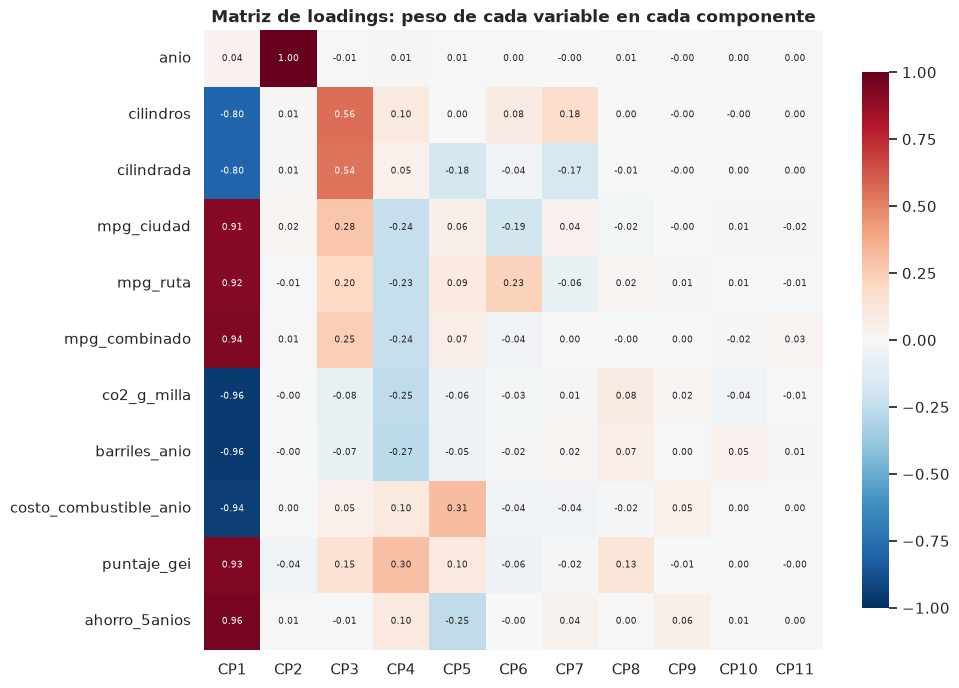

Variables ordenadas por su correlación con la CP1:


,loading en CP1,varianza de la variable capturada por CP1
ahorro_5anios,0.960,0.921
co2_g_milla,-0.958,0.917
barriles_anio,-0.956,0.915
costo_combustible_anio,-0.943,0.888
mpg_combinado,0.935,0.875
puntaje_gei,0.926,0.857
mpg_ruta,0.916,0.838
mpg_ciudad,0.907,0.823
cilindrada,-0.802,0.643
cilindros,-0.798,0.636


In [54]:
# --- 6.d Mapa de calor de los loadings y las variables de la CP1 ---
# El gráfico hace visible lo que la tabla dice número por número: si los loadings
# altos se agrupan en bloques, hay variables que pesan juntas. Como los loadings son
# correlaciones, la escala de color se fija de -1 a 1 para que los colores sean
# comparables de una columna a otra.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(loadings, cmap="RdBu_r", center=0, annot=True, fmt=".2f", vmin=-1, vmax=1,
            annot_kws={"size": 6.5}, square=True, cbar_kws={"shrink": .75}, ax=ax)
ax.set_title("Matriz de loadings: peso de cada variable en cada componente",
             fontweight="bold")
plt.tight_layout()
plt.show()

# Las variables más correlacionadas con la primera componente. El cuadrado del loading
# es la porción de la varianza de esa variable que la CP1 captura.
orden_cp1 = loadings["CP1"].abs().sort_values(ascending=False).index
tabla_cp1 = pd.DataFrame({
    "loading en CP1": loadings.loc[orden_cp1, "CP1"],
    "varianza de la variable capturada por CP1": loadings.loc[orden_cp1, "CP1"] ** 2,
})
print("Variables ordenadas por su correlación con la CP1:")
display(tabla_cp1.round(3))


### 6.d Qué dice la matriz de *loading*

**La CP1 es un eje de eficiencia.** Diez de las once variables la cargan con un peso alto, y el signo las parte en dos grupos que se oponen:

- **Positivas** (loading de 0,91 a 0,96): `ahorro_5anios`, `mpg_combinado`, `puntaje_gei`, `mpg_ruta`, `mpg_ciudad`. Un vehículo que rinde más millas por galón, tiene mejor puntaje ambiental y ahorra más plata a cinco años.
- **Negativas** (de −0,96 a −0,80): `co2_g_milla`, `barriles_anio`, `costo_combustible_anio`, `cilindrada`, `cilindros`. Un motor más grande, que consume más, emite más y cuesta más mantener.

Las dos listas describen el mismo hecho desde los dos lados, así que la CP1 se lee como **un solo eje que va de "eficiente" a "grande y gastador"**.

Que los diez loadings estén tan parejos entre sí (de 0,80 a 0,96, sin ninguno que se despegue) no es casual: son justamente las variables que en 6.a aparecían muy correlacionadas entre ellas. La CP1 las resume a todas porque todas dicen casi lo mismo, y por eso sola alcanza para explicar el 75,56 % de la varianza.

**El caso de `anio`.** Su loading en la CP1 es **0,041**, así que la primera componente captura apenas el **0,17 %** de su varianza: su información queda afuera. Pero no se pierde, porque reaparece en la **CP2 con 0,999**, una componente hecha literalmente de una sola variable. Que tenga su propia componente se explica por lo que ya se veía en 6.a: `anio` no correlaciona con ninguna otra, así que ninguna combinación de las demás puede representarla.

**Las componentes siguientes pierden filo.** La CP3 la cargan sobre todo `cilindros` y `cilindrada` (0,56 y 0,54), con los `mpg_*` en segundo plano (0,20 a 0,28) y el resto casi en cero. De la CP4 en adelante ningún loading supera 0,31 y las historias dejan de ser legibles.

**En una frase, qué provee la matriz.** Dice de qué está hecha cada componente y qué variables quedan bien representadas al quedarse con un subconjunto de ellas. Sin la matriz, saber que la CP1 explica el 75,56 % no dice nada sobre los vehículos; con ella, ese 75,56 % resulta ser, básicamente, la eficiencia.

### 6.e El biplot

Un **biplot** superpone en un mismo plano dos cosas que hasta ahora se miraban por separado:

- **Los puntos**: cada vehículo, ubicado por sus puntajes en la CP1 y la CP2.
- **Las flechas**: cada variable, dibujada desde el centro. La dirección de la flecha apunta hacia donde crece esa variable, y su largo indica cuánto pesa en este plano.

La gracia es que las dos cosas se leen juntas: mirando hacia dónde apunta una flecha se ve qué vehículos están altos en esa variable y cuáles bajos. Sin el biplot habría que ir cruzando a mano el gráfico de puntajes con la tabla de *loading*.

Los puntos están coloreados por el **tipo de combustible**. Es una categoría que no entró al PCA —solo se usaron las 11 variables numéricas—, así que sirve para ver si los grupos que aparecen en el plano se corresponden con algo real del dataset o son un artefacto del cálculo.

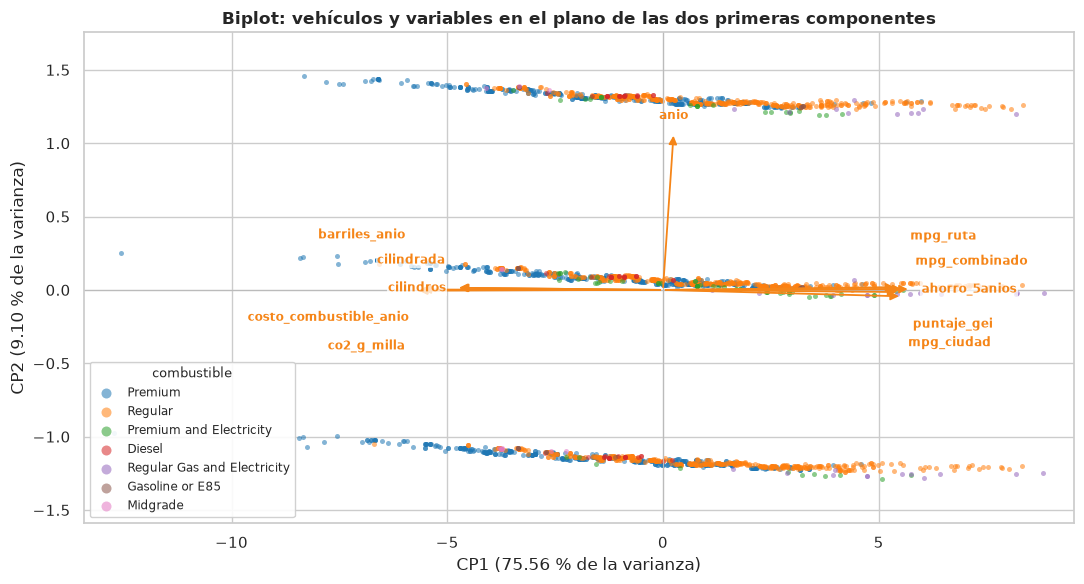

In [55]:
# --- 6.e Biplot: vehículos y variables en el mismo plano ---
# Un biplot superpone dos cosas:
#   - los PUNTOS, que son los vehículos ubicados por sus puntajes en la CP1 y la CP2;
#   - las FLECHAS, que son las variables: cada una apunta hacia donde crece, y el largo
#     indica cuánto pesa en este plano.
# Así se ve al mismo tiempo cómo se agrupan los vehículos y qué variables empujan en
# cada dirección, algo que ni los puntajes solos ni la tabla de loadings muestran.
combustible = vehiculos.loc[datos_vehiculos.index, "combustible"]
colores = dict(zip(combustible.value_counts().index, sns.color_palette("tab10", 7)))

# Los puntajes y los loadings no están en la misma escala (los puntajes llegan a 13 y
# los loadings van de -1 a 1), así que las flechas se agrandan para que se vean. El
# factor se calcula por separado en cada eje porque los rangos son muy distintos: la
# CP1 tiene un desvío de 2,88 y la CP2 de 1,00.
limite_x = (puntajes["CP1"].min() - 0.7, puntajes["CP1"].max() + 0.7)
limite_y = (puntajes["CP2"].min() - 0.3, puntajes["CP2"].max() + 0.3)
escala_x = 0.25 * (limite_x[1] - limite_x[0]) / loadings["CP1"].abs().max()
escala_y = 0.32 * (limite_y[1] - limite_y[0]) / loadings["CP2"].abs().max()

fig, ax = plt.subplots(figsize=(11, 6))
for tipo, color in colores.items():
    elegidos = combustible == tipo
    ax.scatter(puntajes.loc[elegidos, "CP1"], puntajes.loc[elegidos, "CP2"],
               s=13, color=color, alpha=0.55, linewidth=0, label=tipo)

# Las flechas. Como 10 de las 11 variables cargan casi todo en la CP1, sus puntas caen
# en dos grupos pegados al eje horizontal y las etiquetas se superpondrían. Se las
# escalona en vertical dentro de cada grupo, y se les pone fondo blanco para que se
# lean sobre la nube de puntos. La excepción es `anio`, que apunta hacia arriba.
estilo = dict(fontsize=8.5, color=COLOR_SUAVIZADA, fontweight="bold", zorder=5)
abanico = [0, 20, -20, 40, -40]      # desplazamientos verticales, en puntos
turno = {1: 0, -1: 0}                # cuántas etiquetas lleva cada lado
for variable in loadings["CP1"].sort_values(ascending=False).index:
    punta_x = loadings.loc[variable, "CP1"] * escala_x
    punta_y = loadings.loc[variable, "CP2"] * escala_y
    ax.annotate("", xy=(punta_x, punta_y), xytext=(0, 0), zorder=4,
                arrowprops=dict(arrowstyle="-|>", color=COLOR_SUAVIZADA, lw=1.3))

    if abs(punta_y) > abs(punta_x):          # `anio`: la flecha va hacia arriba
        ax.annotate(variable, (punta_x, punta_y), xytext=(0, 8), va="bottom",
                    ha="center", textcoords="offset points", **estilo)
    else:
        lado = 1 if punta_x > 0 else -1
        ax.annotate(variable, (punta_x, punta_y),
                    xytext=(8 * lado, abanico[turno[lado] % len(abanico)]),
                    textcoords="offset points", va="center",
                    ha="left" if lado > 0 else "right", **estilo,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1))
        turno[lado] += 1

# Los ejes en cero ayudan a ubicar los cuatro cuadrantes.
ax.axhline(0, color="#BBBBBB", lw=0.8, zorder=1)
ax.axvline(0, color="#BBBBBB", lw=0.8, zorder=1)
ax.set_xlim(limite_x)
ax.set_ylim(limite_y)
ax.set_xlabel(f"CP1 ({100 * pca.explained_variance_ratio_[0]:.2f} % de la varianza)")
ax.set_ylabel(f"CP2 ({100 * pca.explained_variance_ratio_[1]:.2f} % de la varianza)")
ax.set_title("Biplot: vehículos y variables en el plano de las dos primeras componentes",
             fontweight="bold")
ax.legend(title="combustible", loc="lower left", fontsize=8.5, title_fontsize=9.5,
          framealpha=0.9, markerscale=2)
plt.tight_layout()
plt.show()


### 6.e Qué muestra el biplot

**1. Las flechas se reparten en dos grupos opuestos, pegadas al eje horizontal.** Cinco apuntan hacia la derecha (`ahorro_5anios`, `mpg_combinado`, `puntaje_gei`, `mpg_ruta`, `mpg_ciudad`) y cinco hacia la izquierda (`co2_g_milla`, `barriles_anio`, `costo_combustible_anio`, `cilindrada`, `cilindros`). Dentro de cada grupo apuntan casi en la misma dirección, y ésa es la forma visual de decir lo que ya mostraba la matriz de correlaciones de 6.a: esas variables miden casi lo mismo. El eje horizontal es el eje de eficiencia que se describió en 6.d.

**2. `anio` es la única flecha vertical.** Está sola, perpendicular a todas las demás. Ésa es la comprobación gráfica de lo que se vio en la CP2: una componente hecha únicamente del año del modelo.

**3. Los colores acompañan al eje horizontal.** Los vehículos de combustible *Premium* (el octanaje que usan los motores grandes) caen hacia la izquierda, con CP1 promedio −1,11; los de *Regular* caen hacia la derecha, con +1,08. Los híbridos están entre los más a la derecha de todos: *Regular Gas and Electricity* promedia +5,18 y *Premium and Electricity* +1,24. Como el tipo de combustible no entró en el cálculo, ese ordenamiento es un hallazgo y no un supuesto.

**4. Los extremos del eje confirman qué mide.** Los dos vehículos más alejados del centro son reales y dicen bastante: en el extremo negativo el **Bugatti Chiron Super Sport** (16 cilindros, 9 mpg combinado, 979 g de CO₂ por milla y −31.250 USD de "ahorro" a cinco años) y en el positivo el **Toyota Prius PHEV** (4 cilindros, 52 mpg, 50 g de CO₂ y +7.250 USD).

**Una advertencia sobre las flechas.** Para que se vean hubo que agrandarlas, y con un factor distinto en cada eje, porque los rangos de la CP1 y la CP2 son muy diferentes. Eso no cambia hacia dónde apunta cada una, pero **sí distorsiona los ángulos entre ellas**: en este gráfico los ángulos no se pueden leer como correlaciones. Para eso está la matriz de 6.a.

**En una frase, qué provee el biplot.** Ubica a la vez las observaciones y las variables en el mismo plano. Eso permite pasar de "la CP1 explica el 75,56 %" a "la CP1 separa a los vehículos eficientes de los gastadores, y las etiquetas de combustible acompañan esa separación", sin dejar de ver los vehículos individuales y sus casos extremos.

### 6.f Cuántas componentes conviene conservar

Las componentes no se descartan por descarte: hay criterios para decidir cuántas quedarse, y este dataset es un buen ejemplo de que no siempre coinciden. Los que se usan acá son tres:

1. **El criterio de Kaiser**: conservar las componentes cuyo autovalor supera 1, es decir, las que explican más varianza que una sola variable estandarizada. La idea es que una componente que vale menos que una variable suelta no está resumiendo nada.
2. **La varianza acumulada**: cuánto del total se conserva al quedarse con las primeras *k* componentes.
3. **La representación de cada variable**: leer los loadings por fila (6.d) dice qué variables quedan bien representadas con esas *k* componentes y cuáles se pierden. Es el control que los otros dos criterios no hacen.

Y hay una cuestión propia de este dataset: qué hacer con `anio`, que en 6.d apareció como una componente entera para sí misma.

In [56]:
# --- 6.f Los criterios para decidir cuántas componentes conservar ---
# Kaiser: se quedan las componentes cuyo autovalor supera 1, o sea las que explican
# más varianza que una sola variable estandarizada.
criterios = pd.DataFrame({
    "autovalor": pca.explained_variance_,
    "% varianza": 100 * pca.explained_variance_ratio_,
    "% acumulado": 100 * pca.explained_variance_ratio_.cumsum(),
    "Kaiser (> 1)": pca.explained_variance_ > 1,
}, index=CP)
print("Varianza conservada y criterio de Kaiser:")
display(criterios.round(3))
print(f"Kaiser conserva {int((pca.explained_variance_ > 1).sum())} componentes.")

# El acumulado no dice si cada variable quedó bien representada. Eso sale de leer los
# loadings por fila (6.d): la suma de los loadings al cuadrado sobre las primeras k
# componentes es la proporción de la varianza de esa variable que se conserva.
conservado = pd.DataFrame(
    {f"{k} comp": 100 * (loadings[CP[:k]] ** 2).sum(axis=1) for k in (1, 2, 3, 4)})
print("\nCuánto conserva cada variable según cuántas componentes se retengan (%):")
display(conservado.round(1))
print("La variable peor representada en cada caso:")
for columna in conservado.columns:
    print(f"  {columna:8s}: {conservado[columna].idxmin()} "
          f"con {conservado[columna].min():.1f} %")


Varianza conservada y criterio de Kaiser:


,autovalor,% varianza,% acumulado,Kaiser (> 1)
CP1,8.315,75.561,75.561,True
CP2,1.001,9.096,84.657,True
CP3,0.827,7.516,92.172,False
CP4,0.426,3.870,96.042,False
CP5,0.221,2.011,98.053,False
CP6,0.104,0.945,98.997,False
CP7,0.068,0.617,99.615,False
CP8,0.031,0.279,99.894,False
CP9,0.006,0.054,99.948,False
CP10,0.004,0.039,99.987,False


Kaiser conserva 2 componentes.

Cuánto conserva cada variable según cuántas componentes se retengan (%):


,1 comp,2 comp,3 comp,4 comp
anio,0.2,100.0,100.0,100.0
cilindros,63.6,63.7,95.3,96.3
cilindrada,64.3,64.3,93.8,94.1
mpg_ciudad,82.3,82.3,90.1,95.8
mpg_ruta,83.8,83.8,87.9,93.4
mpg_combinado,87.5,87.5,93.6,99.3
co2_g_milla,91.7,91.7,92.3,98.7
barriles_anio,91.5,91.5,92.0,99.0
costo_combustible_anio,88.8,88.8,89.1,90.1
puntaje_gei,85.7,85.8,88.1,97.0


La variable peor representada en cada caso:
  1 comp  : anio con 0.2 %
  2 comp  : cilindros con 63.7 %
  3 comp  : mpg_ruta con 87.9 %
  4 comp  : costo_combustible_anio con 90.1 %


In [57]:
# --- 6.f El caso de `anio` ---
# En 6.d se vio que la CP2 es `anio` con un loading de 0,999. Si se repite el PCA sin
# `anio`, el espectro de autovalores queda igual salvo por un autovalor de 1: ésa es la
# prueba de que la CP2 no resume el dataset, solo pone a `anio` en un eje propio.
sin_anio = [c for c in VARIABLES_NUMERICAS if c != "anio"]
pca_sin_anio = PCA().fit(StandardScaler().fit_transform(datos_vehiculos[sin_anio]))

print("Autovalores, con y sin `anio`:")
print(f"  con anio: {np.round(pca.explained_variance_, 4)}")
print(f"  sin anio: {np.round(pca_sin_anio.explained_variance_, 4)}")
corrimiento = np.abs(pca.explained_variance_[2:]
                     - pca_sin_anio.explained_variance_[1:]).max()
print(f"Corridos un lugar, las dos listas coinciden (diferencia máxima "
      f"{corrimiento:.4f}).")

anio_estandarizado = StandardScaler().fit_transform(datos_vehiculos[["anio"]])[:, 0]
print(f"\ncorrelación entre la CP2 y `anio`: "
      f"{np.corrcoef(puntajes['CP2'], anio_estandarizado)[0, 1]:.4f}")
print(f"correlación entre la CP1 y `anio`: "
      f"{np.corrcoef(puntajes['CP1'], anio_estandarizado)[0, 1]:.4f}")

print(f"\nvarianza total a repartir: con anio {pca.explained_variance_.sum():.4f}, "
      f"sin anio {pca_sin_anio.explained_variance_.sum():.4f}")
print(f"el autovalor más grande:  con anio {pca.explained_variance_[0]:.4f}, "
      f"sin anio {pca_sin_anio.explained_variance_[0]:.4f}")


Autovalores, con y sin `anio`:
  con anio: [8.3147e+00 1.0009e+00 8.2700e-01 4.2580e-01 2.2120e-01 1.0400e-01
 6.7900e-02 3.0800e-02 5.9000e-03 4.2000e-03 1.5000e-03]
  sin anio: [8.3132e+00 8.2710e-01 4.2600e-01 2.2140e-01 1.0410e-01 6.8000e-02
 3.2200e-02 5.9000e-03 4.3000e-03 1.5000e-03]
Corridos un lugar, las dos listas coinciden (diferencia máxima 0.0015).

correlación entre la CP2 y `anio`: 0.9989
correlación entre la CP1 y `anio`: 0.0414

varianza total a repartir: con anio 11.0039, sin anio 10.0036
el autovalor más grande:  con anio 8.3147, sin anio 8.3132


### 6.f Cuántas componentes elegiría

**Elegiría 3 componentes.** No es lo que sale de aplicar el criterio de Kaiser, que daría 2, así que conviene ver por qué.

**Qué dice cada criterio:**

- **Kaiser (autovalor > 1):** conserva **2**. El autovalor de la CP2 es 1,0009, apenas por encima del umbral, y el de la CP3 es 0,827.
- **Varianza acumulada:** la CP1 explica el 75,56 %, las dos primeras el 84,66 % y **las tres el 92,17 %**. La CP4 agregaría solo 3,87 puntos más.
- **Representación de cada variable:** acá aparece el problema de quedarse en dos. Con dos componentes, `cilindros` y `cilindrada` conservan apenas el **63,7 % y el 64,3 %** de su varianza. Con tres, la peor variable representada es `mpg_ruta` con el **87,9 %**, y el resto queda por encima.

**Por qué el criterio de Kaiser se queda corto acá.** El autovalor 1,0009 de la CP2 no es casual: **1 es exactamente lo que produce una variable que no correlaciona con ninguna otra**. La CP2 no es una dimensión nueva que resuma el dataset, es `anio` puesta sola en un eje. La comprobación está en la celda anterior: repitiendo el PCA sin `anio`, los otros diez autovalores son los mismos corridos un lugar (diferencia máxima 0,0015) y lo único que desaparece es ese ~1. Incluir `anio` tampoco cambia la estructura principal —el autovalor más grande sigue siendo 8,31 con o sin él—, solo suma una unidad al total a repartir, y por eso el porcentaje de la CP1 baja de 83,10 % a 75,56 %.

**Por qué 3 y no 4.** La CP4 aporta 3,87 puntos y mueve poco a las variables: a `mpg_ciudad` la lleva de 90,1 % a 95,8 %, y al resto apenas. Su eje tampoco tiene una lectura clara, porque ninguno de sus loadings pasa de 0,30.

**La respuesta, entonces.** Quedarse con 3 componentes conserva el 92,17 % de la varianza, deja a las once variables bien representadas y sus tres ejes se pueden interpretar: **eficiencia** (CP1), **año del modelo** (CP2) y **tamaño de motor** (CP3). Kaiser solo habría conservado dos, dejando afuera el eje de tamaño, con `cilindros` y `cilindrada` perdiendo más de un tercio de su información.

**Una distinción que vale la pena.** Si el objetivo fuera únicamente resumir la **redundancia** entre variables —que es lo que motivó el análisis—, alcanzaría con **una** componente: explica el 75,56 % y es la única que combina varias variables a la vez, mientras que la CP2 es una sola variable y la CP3 resume únicamente a dos. La respuesta de tres componentes es para **explicar el comportamiento del dataset** completo, que es lo que pide la consigna.